# Basics

In [2]:
!python --version

Python 3.11.9


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import points_in_box

In [8]:
%matplotlib inline
from nuscenes.nuscenes import NuScenes

nusc = NuScenes(version='v1.0-mini', dataroot=r'data/sets/nuscenes', verbose=True)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.474 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.


In [51]:
DATAROOT = r"data/sets/nuscenes"
VERSION = "v1.0-mini"
SCENE_INDEX = 0
RADAR_CHAN = "RADAR_FRONT"
REF_CHAN = "LIDAR_TOP"
REF_SENSOR = "LIDAR_TOP"
SENSORS_TO_EVAL = ["CAM_FRONT", "RADAR_FRONT"]
THRESHOLD_MS = 50
MIN_RADAR_HITS = 1

scene_token = nusc.scene[0]["token"]

In [ ]:
def get_frame_timestamps(scene_token):
    scene = nusc.get('scene', scene_token)
    sample_token = scene['first_sample_token']

    timestamps = []
    while sample_token:
        sample = nusc.get('sample', sample_token)
        timestamps.append(sample['timestamp'])
        sample_token = sample['next']

    return timestamps

print(get_frame_timestamps('cc8c0bf57f984915a77078b10eb33198'))


[1532402927647951, 1532402928147847, 1532402928698048, 1532402929197353, 1532402929697797, 1532402930152601, 1532402930648325, 1532402931198511, 1532402931697833, 1532402932197715, 1532402932647284, 1532402933146604, 1532402933646462, 1532402934146351, 1532402934696555, 1532402935197541, 1532402935697945, 1532402936198962, 1532402936699359, 1532402937198682, 1532402937698000, 1532402938197897, 1532402938647444, 1532402939147334, 1532402939697511, 1532402940197958, 1532402940797343, 1532402941297218, 1532402941797653, 1532402942197463, 1532402942697870, 1532402943197769, 1532402943697655, 1532402944198088, 1532402944697931, 1532402945197276, 1532402945697148, 1532402946297085, 1532402946797517]


In [104]:
my_scene = nusc.scene[0]
first_sample_token = my_scene['first_sample_token']
my_sample = nusc.get('sample', first_sample_token)
print(my_sample)

{'token': 'ca9a282c9e77460f8360f564131a8af5', 'timestamp': 1532402927647951, 'prev': '', 'next': '39586f9d59004284a7114a68825e8eec', 'scene_token': 'cc8c0bf57f984915a77078b10eb33198', 'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906', 'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d', 'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b', 'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776', 'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1', 'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f', 'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844', 'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b', 'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e', 'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8', 'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7', 'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'}, 'anns': ['ef63a697930c4b20a6b9791f423351da', '6b89da9bf1f84fd6a5fbe1c3b236f809', '924ee6ac1fed440a9d9e3720aac635a0', '91e3608f55174a319246f361690906ba', 'cd051723ed9c40f

In [105]:
sample_data = nusc.get('sample_data', "37091c75b9704e0daa829ba56dfa0906")
sample_data['timestamp']

1532402927664178

In [106]:
def get_sensor_timestamps_per_sample(scene_token):
    scene = nusc.get('scene', scene_token)
    sample_token = scene['first_sample_token']
    
    all_frames = []   # will store list of dicts: {sample_timestamp, sensor: timestamp}

    while sample_token:
        sample = nusc.get('sample', sample_token)

        frame_info = {
            'sample_token': sample_token,
            'sample_timestamp': sample['timestamp'],
            'sensors': {}
        }

        # Loop through all sensors in this sample
        for sensor_name, sd_token in sample['data'].items():
            sd = nusc.get('sample_data', sd_token)
            frame_info['sensors'][sensor_name] = sd['timestamp']

        all_frames.append(frame_info)

        sample_token = sample['next']

    return all_frames


# Example usage:
frames = get_sensor_timestamps_per_sample('cc8c0bf57f984915a77078b10eb33198')

for f in frames[:3]:  # print only first 3 frames
    print("\nSample Timestamp:", f['sample_timestamp'])
    for sensor, ts in f['sensors'].items():
        print(f"  {sensor}: {ts}")


Sample Timestamp: 1532402927647951
  RADAR_FRONT: 1532402927664178
  RADAR_FRONT_LEFT: 1532402927652686
  RADAR_FRONT_RIGHT: 1532402927639817
  RADAR_BACK_LEFT: 1532402927668356
  RADAR_BACK_RIGHT: 1532402927635538
  LIDAR_TOP: 1532402927647951
  CAM_FRONT: 1532402927612460
  CAM_FRONT_RIGHT: 1532402927620339
  CAM_BACK_RIGHT: 1532402927627893
  CAM_BACK: 1532402927637525
  CAM_BACK_LEFT: 1532402927647423
  CAM_FRONT_LEFT: 1532402927604844

Sample Timestamp: 1532402928147847
  RADAR_FRONT: 1532402928114656
  RADAR_FRONT_LEFT: 1532402928167268
  RADAR_FRONT_RIGHT: 1532402928154361
  RADAR_BACK_LEFT: 1532402928178424
  RADAR_BACK_RIGHT: 1532402928146224
  LIDAR_TOP: 1532402928147847
  CAM_FRONT: 1532402928112460
  CAM_FRONT_RIGHT: 1532402928120339
  CAM_BACK_RIGHT: 1532402928127893
  CAM_BACK: 1532402928137525
  CAM_BACK_LEFT: 1532402928147423
  CAM_FRONT_LEFT: 1532402928104844

Sample Timestamp: 1532402928698048
  RADAR_FRONT: 1532402928719956
  RADAR_FRONT_LEFT: 1532402928682384
  RAD

In [107]:
def compute_time_offsets(frames):
    offsets = []

    for f in frames:
        sample_ts = f['sample_timestamp']
        sensor_offsets = {s: f['sensors'][s] - sample_ts for s in f['sensors']}
        offsets.append(sensor_offsets)

    return offsets

In [108]:

# -------------------------------------------------------------
# 1. Extract sensor timestamps per frame
# -------------------------------------------------------------
def get_sensor_timestamps_per_sample(scene_token):
    scene = nusc.get('scene', scene_token)
    sample_token = scene['first_sample_token']

    all_frames = []

    while sample_token:
        sample = nusc.get('sample', sample_token)

        frame_info = {
            'sample_token': sample_token,
            'sample_timestamp': sample['timestamp'],
            'sensors': {}
        }

        # Loop over all sensors (camera, lidar, radar…)
        for sensor_name, sd_token in sample['data'].items():
            sd = nusc.get('sample_data', sd_token)
            frame_info['sensors'][sensor_name] = sd['timestamp']

        all_frames.append(frame_info)
        sample_token = sample['next']

    return all_frames


# -------------------------------------------------------------
# 2. Compute time offsets for each frame
# -------------------------------------------------------------
def compute_time_offsets(frames):
    """
    For each frame:
        offset = sensor_timestamp - sample_timestamp
    """
    offsets = []

    for f in frames:
        sample_ts = f['sample_timestamp']
        sensor_offsets = {s: f['sensors'][s] - sample_ts for s in f['sensors']}

        offsets.append({
            "sample_timestamp": sample_ts,
            "offsets": sensor_offsets
        })

    return offsets


# -------------------------------------------------------------
# 3. Sort frames by timestamp (chronological order)
# -------------------------------------------------------------
def sort_frames_by_timestamp(frames):
    return sorted(frames, key=lambda x: x['sample_timestamp'])

In [109]:
# Choose a scene
scene_token = 'cc8c0bf57f984915a77078b10eb33198'

# Step 1: Extract timestamps
frames = get_sensor_timestamps_per_sample(scene_token)

# Step 2: Compute offsets
offsets = compute_time_offsets(frames)

# Step 3: Sort frames chronologically
sorted_frames = sort_frames_by_timestamp(frames)


# Print first 3 frames
for i, f in enumerate(sorted_frames[:20]):
    print(f"\n===== Frame {i} =====")
    print("Sample Timestamp:", f['sample_timestamp'])
    for sensor, ts in f['sensors'].items():
        print(f"  {sensor}: {ts}")

# Print offset example
print("\nExample Offsets:")
for offset in offsets:
    print(offset)
    print("")


===== Frame 0 =====
Sample Timestamp: 1532402927647951
  RADAR_FRONT: 1532402927664178
  RADAR_FRONT_LEFT: 1532402927652686
  RADAR_FRONT_RIGHT: 1532402927639817
  RADAR_BACK_LEFT: 1532402927668356
  RADAR_BACK_RIGHT: 1532402927635538
  LIDAR_TOP: 1532402927647951
  CAM_FRONT: 1532402927612460
  CAM_FRONT_RIGHT: 1532402927620339
  CAM_BACK_RIGHT: 1532402927627893
  CAM_BACK: 1532402927637525
  CAM_BACK_LEFT: 1532402927647423
  CAM_FRONT_LEFT: 1532402927604844

===== Frame 1 =====
Sample Timestamp: 1532402928147847
  RADAR_FRONT: 1532402928114656
  RADAR_FRONT_LEFT: 1532402928167268
  RADAR_FRONT_RIGHT: 1532402928154361
  RADAR_BACK_LEFT: 1532402928178424
  RADAR_BACK_RIGHT: 1532402928146224
  LIDAR_TOP: 1532402928147847
  CAM_FRONT: 1532402928112460
  CAM_FRONT_RIGHT: 1532402928120339
  CAM_BACK_RIGHT: 1532402928127893
  CAM_BACK: 1532402928137525
  CAM_BACK_LEFT: 1532402928147423
  CAM_FRONT_LEFT: 1532402928104844

===== Frame 2 =====
Sample Timestamp: 1532402928698048
  RADAR_FRONT:

In [110]:
channels = set()

for sd in nusc.sample_data:
    channels.add(sd['channel'])

print(sorted(channels))

['CAM_BACK', 'CAM_BACK_LEFT', 'CAM_BACK_RIGHT', 'CAM_FRONT', 'CAM_FRONT_LEFT', 'CAM_FRONT_RIGHT', 'LIDAR_TOP', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT']


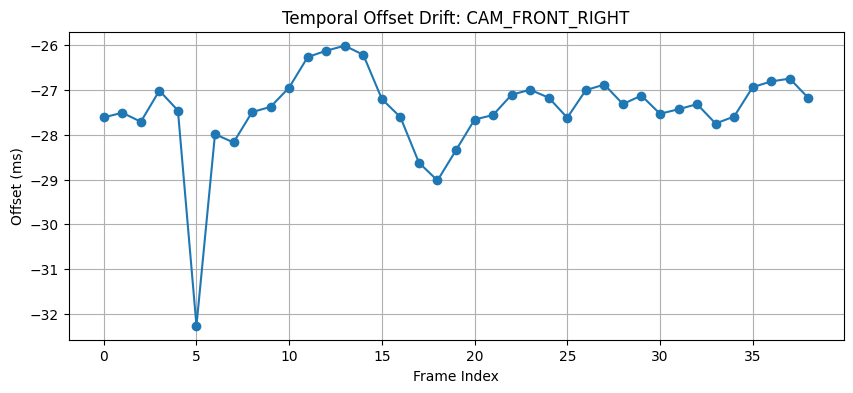

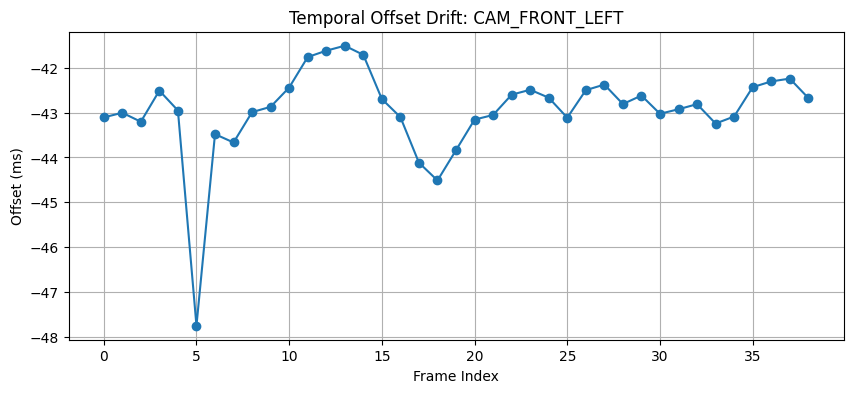

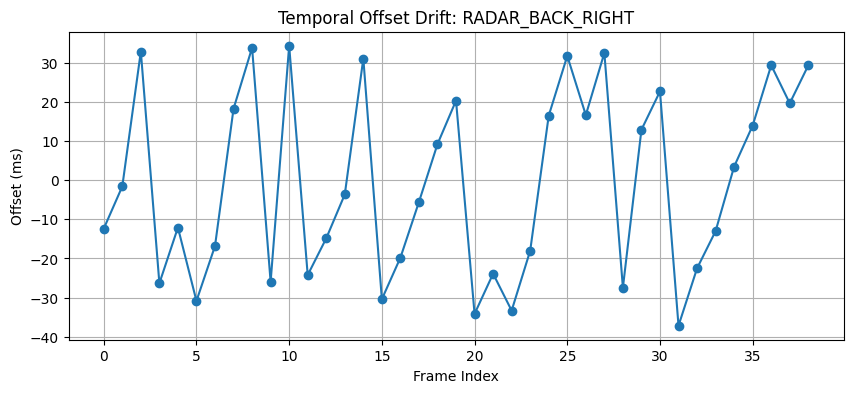

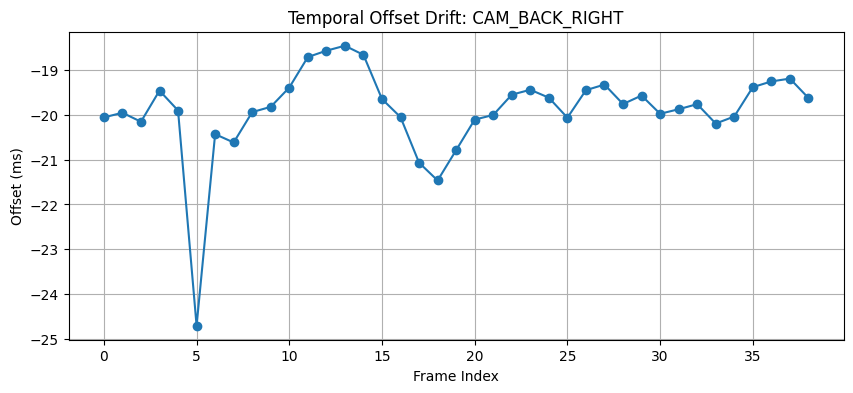

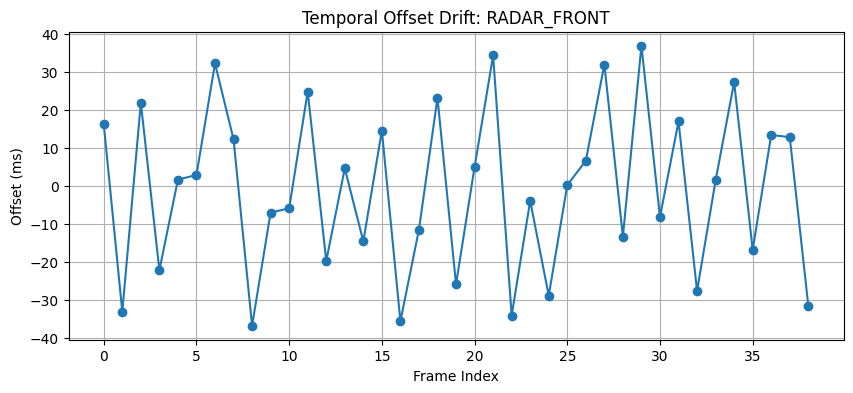

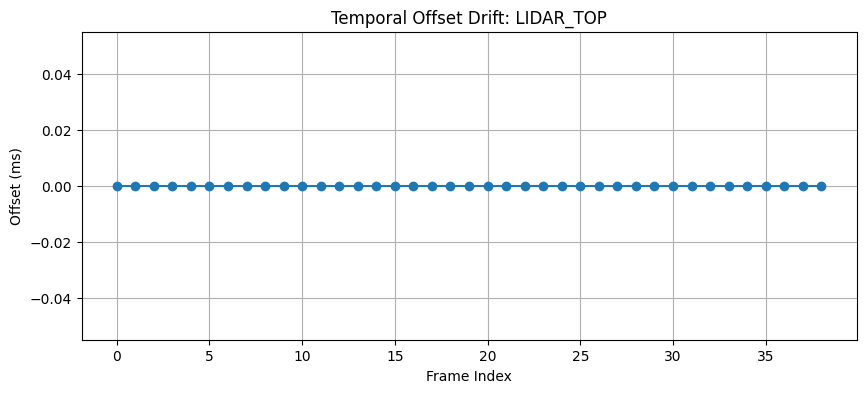

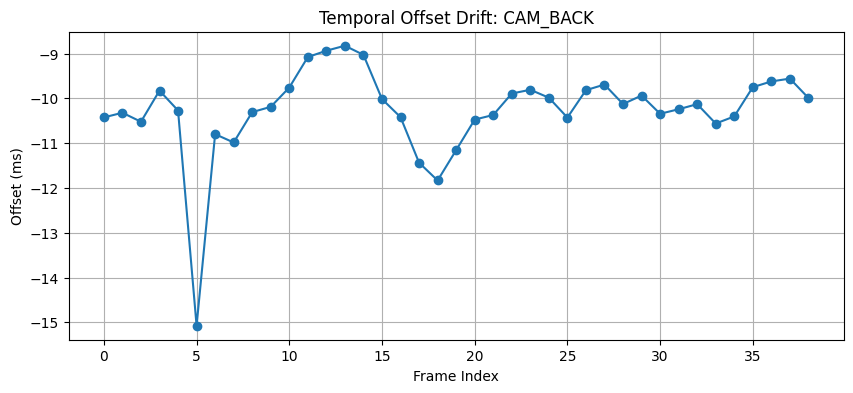

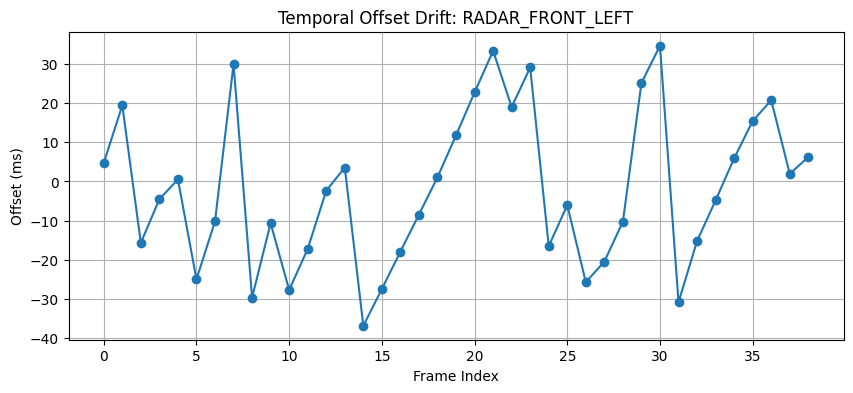

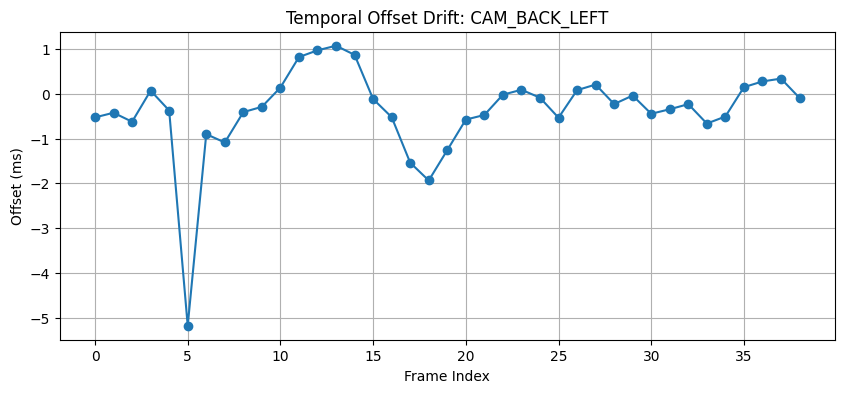

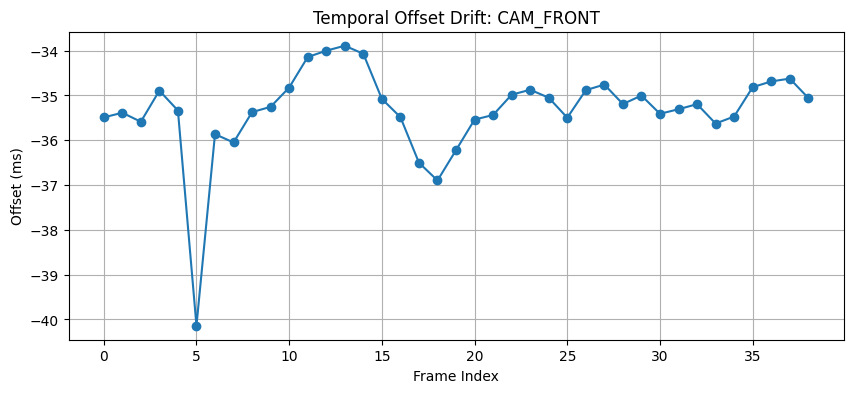

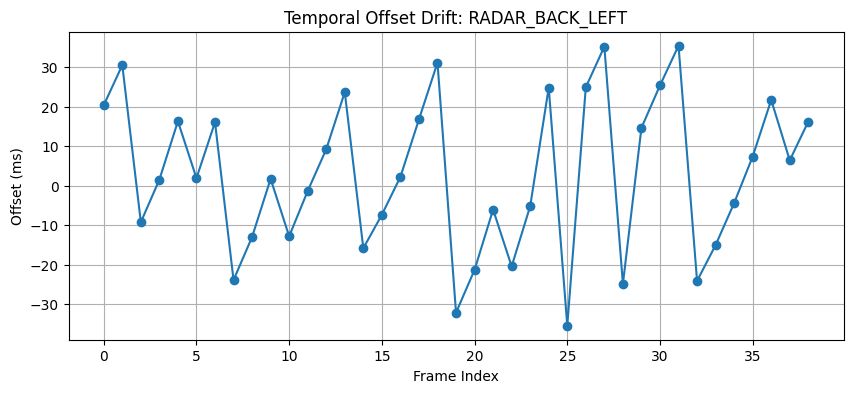

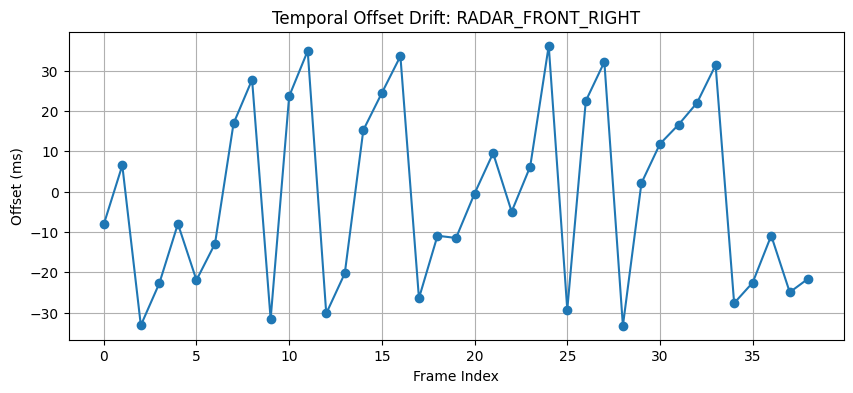

In [111]:
import matplotlib.pyplot as plt

def plot_sensor_offsets(offsets, sensor_name):
    xs = []
    ys = []
    
    for i, entry in enumerate(offsets):
        if sensor_name in entry['offsets']:
            xs.append(i)
            ys.append(entry['offsets'][sensor_name] / 1000.0)  # convert to ms

    plt.figure(figsize=(10,4))
    plt.plot(xs, ys, marker='o')
    plt.title(f"Temporal Offset Drift: {sensor_name}")
    plt.xlabel("Frame Index")
    plt.ylabel("Offset (ms)")
    plt.grid(True)
    plt.show()

# Example:
for channel in channels:
    plot_sensor_offsets(offsets, channel)

# Fusion Methods (5.1)

In [150]:
import numpy as np
from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import points_in_box

# ---------------- CONFIG ----------------
DATAROOT = r"data/sets/nuscenes"   # change if needed
VERSION = "v1.0-mini"
SCENE_INDEX = 0
RADAR_CHAN = "RADAR_FRONT"
REF_CHAN = "LIDAR_TOP"
MIN_RADAR_HITS = 1
MAX_PRINT = 10
# ----------------------------------------


def fuse_frame(nusc, sample, radar_chan="RADAR_FRONT", ref_chan="LIDAR_TOP", min_hits=1):
    """
    Baseline object-level LiDAR-radar fusion for one frame.

    Returns:
        fused_objects: list of dicts, each with:
            - box_index
            - position_xy
            - velocity_xy
            - radar_hits
            - box_name
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    # Radar already transformed into lidar frame
    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :]      # (3, N)
    vx = rpc.points[8, :]              # compensated radar vx
    vy = rpc.points[9, :]              # compensated radar vy
    radar_vel = np.vstack((vx, vy))    # (2, N)

    # GT boxes in lidar frame
    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    fused_objects = []

    for i, box in enumerate(boxes):
        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        # Robust velocity estimate from associated radar points
        v_est = np.median(radar_vel[:, mask], axis=1)

        fused_obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box.center[:2].copy(),
            "velocity_xy": v_est.copy(),
            "radar_hits": hit_count
        }
        fused_objects.append(fused_obj)

    return fused_objects


def run_scene_baseline(nusc, scene_index=0, radar_chan="RADAR_FRONT", ref_chan="LIDAR_TOP",
                       min_hits=1, max_print=10):
    """
    Runs baseline fusion across a full scene.
    """
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    print("Processing scene:", scene["name"])

    all_frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        fused_objects = fuse_frame(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits
        )

        frame_record = {
            "sample_token": token,
            "frame_index": frame_idx,
            "objects": fused_objects
        }
        all_frames.append(frame_record)

        print(f"\nFrame {frame_idx} | token={token[:6]} | fused_objects={len(fused_objects)}")

        for j, obj in enumerate(fused_objects[:max_print]):
            print(
                f"Obj {obj['box_index']} | "
                f"class={obj['box_name']} | "
                f"pos={obj['position_xy']} | "
                f"vel={obj['velocity_xy']} | "
                f"hits={obj['radar_hits']}"
            )

        token = sample["next"]
        frame_idx += 1

    return all_frames


def summarise_results(all_frames):
    total_frames = len(all_frames)
    total_objects = sum(len(f["objects"]) for f in all_frames)

    hits = []
    speeds = []

    for frame in all_frames:
        for obj in frame["objects"]:
            hits.append(obj["radar_hits"])
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    print("\n===== BASELINE SUMMARY =====")
    print("Total frames:", total_frames)
    print("Total fused objects:", total_objects)

    if hits:
        print("Average radar hits per fused object:", np.mean(hits))
        print("Median radar hits per fused object:", np.median(hits))
    else:
        print("No fused objects found.")

    if speeds:
        print("Average fused speed magnitude:", np.mean(speeds))
        print("Median fused speed magnitude:", np.median(speeds))


# ---------------- MAIN ----------------
if __name__ == "__main__":
    nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=True)

    all_frames = run_scene_baseline(
        nusc,
        scene_index=SCENE_INDEX,
        radar_chan=RADAR_CHAN,
        ref_chan=REF_CHAN,
        min_hits=MIN_RADAR_HITS,
        max_print=MAX_PRINT
    )

    summarise_results(all_frames)

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.381 seconds.
Reverse indexing ...
Done reverse indexing in 0.0 seconds.
Processing scene: scene-0061

Frame 0 | token=ca9a28 | fused_objects=9
Obj 9 | class=movable_object.barrier | pos=[ 7.85689816 25.55669921] | vel=[-0.15958051  0.05388169] | hits=2
Obj 16 | class=vehicle.car | pos=[ 5.97927366 35.00872533] | vel=[-0.01604966  0.00264043] | hits=1
Obj 18 | class=vehicle.truck | pos=[-4.4986433  15.25332251] | vel=[-0.16419582 -0.04946925] | hits=7
Obj 21 | class=movable_object.barrier | pos=[ 9.53171813 42.28333322] | vel=[-0.16745839  0.0383587 ] | hits=1
Obj 25 | class=movable_object.barrier | pos=[ 7.09060535 15.51871913] | vel=[-0.16145445  0.08756081] | hits=2
Obj 59 | class=movable_object.pushable_pullable | pos=[-2.80841235 16.74

# Motion-Compensation error (5.2)

In [1]:
def step_sample_data_token(nusc, sd_token: str, steps: int) -> str:
    """
    Move along the sample_data chain.
    steps > 0: go 'prev' that many times (older)
    steps < 0: go 'next' that many times (newer)
    Returns last valid token reached.
    """
    tok = sd_token
    if steps == 0:
        return tok

    direction = "prev" if steps > 0 else "next"
    for _ in range(abs(steps)):
        sd = nusc.get("sample_data", tok)
        nxt = sd[direction]
        if nxt == "" or nxt is None:
            break
        tok = nxt
    return tok


In [2]:
def radar_sweep_to_lidar_frame(nusc, radar_sd_token: str, lidar_sd_token: str, pose_shift_steps: int = 0):
    """
    Load one radar sweep point cloud and transform it into the LiDAR sensor frame at the LiDAR keyframe time.

    pose_shift_steps shifts ONLY the ego_pose used for the radar sweep (simulating timestamp error / latency).
    Calibrated sensor for radar is constant so we do not shift that.
    """
    radar_sd = nusc.get("sample_data", radar_sd_token)
    lidar_sd = nusc.get("sample_data", lidar_sd_token)

    # Load radar point cloud in radar sensor frame
    radar_path = nusc.get_sample_data_path(radar_sd_token)
    rpc = RadarPointCloud.from_file(radar_path)

    # Get radar calibrated sensor (sensor -> ego at radar time)
    radar_cs = nusc.get("calibrated_sensor", radar_sd["calibrated_sensor_token"])
    Tradar_ego = transform_matrix(radar_cs["translation"], Quaternion(radar_cs["rotation"]), inverse=False)

    # Ego pose at radar time (but optionally wrong due to shift)
    radar_pose_token = radar_sd["ego_pose_token"]
    if pose_shift_steps != 0:
        # shift by moving along radar sample_data chain, then taking that ego_pose_token
        shifted_sd_token = step_sample_data_token(nusc, radar_sd_token, pose_shift_steps)
        shifted_sd = nusc.get("sample_data", shifted_sd_token)
        radar_pose_token = shifted_sd["ego_pose_token"]

    radar_pose = nusc.get("ego_pose", radar_pose_token)
    Tego_global_radar = transform_matrix(radar_pose["translation"], Quaternion(radar_pose["rotation"]), inverse=False)

    # Ego pose at lidar time (global -> ego at lidar time)
    lidar_pose = nusc.get("ego_pose", lidar_sd["ego_pose_token"])
    Tego_global_lidar = transform_matrix(lidar_pose["translation"], Quaternion(lidar_pose["rotation"]), inverse=False)
    Tglobal_ego_lidar = np.linalg.inv(Tego_global_lidar)

    # LiDAR calibrated sensor (ego -> lidar sensor at lidar time)
    lidar_cs = nusc.get("calibrated_sensor", lidar_sd["calibrated_sensor_token"])
    Tlidar_ego = transform_matrix(lidar_cs["translation"], Quaternion(lidar_cs["rotation"]), inverse=False)
    Tego_lidar = np.linalg.inv(Tlidar_ego)

    # Full transform
    T_radar_to_lidar = Tego_lidar @ Tglobal_ego_lidar @ Tego_global_radar @ Tradar_ego

    rpc.transform(T_radar_to_lidar)
    return rpc


In [3]:
from pyquaternion import Quaternion
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import transform_matrix
import numpy as np

def radar_sweep_to_lidar_frame_new(
    nusc,
    radar_sd_token: str,
    lidar_sd_token: str,
    pose_time_offset_ms: float = 0.0,   # NEW: time-based corruption
):
    """
    Load one radar sweep and transform it into the LiDAR sensor frame at the LiDAR keyframe time.

    pose_time_offset_ms:
      - 0.0 means clean (use radar sweep's own ego pose)
      - positive means simulate latency (use ego pose from later time)
      - negative means simulate early timestamp (use ego pose from earlier time)
    """
    radar_sd = nusc.get("sample_data", radar_sd_token)
    lidar_sd  = nusc.get("sample_data", lidar_sd_token)

    # Load radar point cloud in radar sensor frame
    radar_path = nusc.get_sample_data_path(radar_sd_token)
    rpc = RadarPointCloud.from_file(radar_path)

    # Radar calibrated sensor: radar_sensor -> ego (at radar time)
    radar_cs = nusc.get("calibrated_sensor", radar_sd["calibrated_sensor_token"])
    T_radar_to_ego = transform_matrix(radar_cs["translation"], Quaternion(radar_cs["rotation"]), inverse=False)

    # Ego pose for radar time, but with time offset applied
    t_radar = float(radar_sd["timestamp"])
    t_bad = t_radar + pose_time_offset_ms * 1000.0  # ms -> us

    # Find radar sample_data token closest to t_bad (same channel chain)
    best_sd_tok = closest_sample_data_token_by_time(nusc, radar_sd_token, t_bad, max_hops=80)
    best_sd = nusc.get("sample_data", best_sd_tok)
    radar_pose = nusc.get("ego_pose", best_sd["ego_pose_token"])

    T_ego_to_global_radar = transform_matrix(radar_pose["translation"], Quaternion(radar_pose["rotation"]), inverse=False)

    # Ego pose at LiDAR time: global -> ego(lidar)
    lidar_pose = nusc.get("ego_pose", lidar_sd["ego_pose_token"])
    T_ego_to_global_lidar = transform_matrix(lidar_pose["translation"], Quaternion(lidar_pose["rotation"]), inverse=False)
    T_global_to_ego_lidar = np.linalg.inv(T_ego_to_global_lidar)

    # LiDAR calibrated sensor: ego(lidar) -> lidar_sensor
    lidar_cs = nusc.get("calibrated_sensor", lidar_sd["calibrated_sensor_token"])
    T_lidar_to_ego = transform_matrix(lidar_cs["translation"], Quaternion(lidar_cs["rotation"]), inverse=False)
    T_ego_to_lidar = np.linalg.inv(T_lidar_to_ego)

    # Full transform: radar_sensor -> ego(radar) -> global -> ego(lidar) -> lidar_sensor
    T_radar_to_lidar = T_ego_to_lidar @ T_global_to_ego_lidar @ T_ego_to_global_radar @ T_radar_to_ego

    rpc.transform(T_radar_to_lidar)
    return rpc


In [4]:
def collect_radar_sweeps_within_window(nusc, radar_key_sd_token: str, t_ref_us: float, window_s: float = 0.5, max_sweeps: int = 30):
    """
    Follow 'prev' from the radar keyframe and collect sweeps within [t_ref - window, t_ref + window].
    Typically you’ll mostly keep previous sweeps (older than t_ref).
    Returns list of sample_data tokens.
    """
    win_us = window_s * 1e6
    toks = []
    tok = radar_key_sd_token

    for _ in range(max_sweeps):
        sd = nusc.get("sample_data", tok)
        t = float(sd["timestamp"])
        if abs(t - t_ref_us) <= win_us:
            toks.append(tok)
        prev_tok = sd["prev"]
        if prev_tok == "" or prev_tok is None:
            break
        tok = prev_tok

    return toks


def radar_spread_metric_xy(points_xyz: np.ndarray) -> float:
    """
    points_xyz: (3, N) points in LiDAR frame.
    Metric: median radial distance in XY.
    """
    if points_xyz.shape[1] == 0:
        return np.nan
    x = points_xyz[0, :]
    y = points_xyz[1, :]
    r = np.sqrt(x*x + y*y)
    return float(np.median(r))

def radar_dispersion_metric_xy(points_xyz):
    if points_xyz.shape[1] == 0:
        return np.nan

    xy = points_xyz[:2, :]
    centroid = np.mean(xy, axis=1, keepdims=True)
    diff = xy - centroid
    r = np.sqrt(np.sum(diff**2, axis=0))

    return float(np.median(r))

def compute_scene_radar_spread_timeseries_old2(
    nusc,
    scene_token: str,
    window_s: float = 0.5,
    max_sweeps: int = 30,
    pose_shift_fn=None,  # function(frame_idx)->int shift steps
    ref_sensor: str = "LIDAR_TOP",
    radar_channel: str = "RADAR_FRONT",
    metric_fn = radar_spread_metric_xy,
    pose_time_offset_ms = 0,
):
    """
    Returns a dataframe per LiDAR frame:
      frame_idx, t_ref_us, n_points, spread_median_r_xy
    pose_shift_fn lets you simulate timing error by using wrong radar ego poses.
    """
    scene = nusc.get("scene", scene_token)
    sample_token = scene["first_sample_token"]

    rows = []
    frame_idx = 0

    while sample_token:
        sample = nusc.get("sample", sample_token)

        lidar_sd_token = sample["data"][ref_sensor]
        lidar_sd = nusc.get("sample_data", lidar_sd_token)
        t_ref_us = float(lidar_sd["timestamp"])

        radar_key_sd_token = sample["data"][radar_channel]
        radar_sweep_tokens = collect_radar_sweeps_within_window(
            nusc, radar_key_sd_token, t_ref_us, window_s=window_s, max_sweeps=max_sweeps
        )

        shift_steps = int(pose_shift_fn(frame_idx)) if pose_shift_fn is not None else 0

        # Merge all transformed sweeps
        all_pts = []
        for k, rad_sd_tok in enumerate(radar_sweep_tokens):
            # Per-sweep timing error model:
            # k=0 is the newest sweep (closest to LiDAR time), larger k = older sweep.
            # Older sweeps get larger shift to simulate accumulating misalignment.
            drift_steps = int(0.5 * k)     # tune: 0.5, 1.0, 2.0 etc.
            shift = shift_steps + drift_steps
            
            if pose_time_offset_ms == 0:
                rpc = radar_sweep_to_lidar_frame(
                    nusc, rad_sd_tok, lidar_sd_token,
                    pose_shift_steps=shift
                )
            else:
                rpc = radar_sweep_to_lidar_frame_new(nusc, rad_sd_tok, lidar_sd_token, pose_time_offset_ms=pose_time_offset_ms)
            all_pts.append(rpc.points[:3, :])  # (3, N)

        if len(all_pts) == 0:
            pts = np.zeros((3, 0))
        else:
            pts = np.concatenate(all_pts, axis=1)

        spread = metric_fn(pts) # CHOOSE radar_spread_metric_xy(pts) OR radar_dispersion_metric_xy(pts)

        rows.append({
            "frame_idx": frame_idx,
            "t_ref_us": t_ref_us,
            "n_points": int(pts.shape[1]),
            "spread_median_r_xy": spread,
            "pose_shift_steps": shift_steps,
            "alignment_error_xy": alignment_error,
            "n_sweeps": len(sweep_pts),
            "n_nonempty_sweeps": int(np.sum(np.array(pts_counts) > 0)),
            "pts_per_sweep_min": int(np.min(nonempty) if nonempty else 0),
            "pts_per_sweep_med": int(np.median(nonempty) if nonempty else 0),
            "pts_per_sweep_max": int(np.max(nonempty) if nonempty else 0),
        })

        frame_idx += 1
        sample_token = sample["next"]

    return pd.DataFrame(rows)


In [5]:
def compute_scene_radar_spread_timeseries_old3(
    nusc,
    scene_token: str,
    window_s: float = 0.5,
    max_sweeps: int = 30,
    pose_shift_fn=None,
    ref_sensor: str = "LIDAR_TOP",
    radar_channel: str = "RADAR_FRONT",
    metric_fn=radar_spread_metric_xy,
    pose_time_offset_ms=0.0,
):
    scene = nusc.get("scene", scene_token)
    sample_token = scene["first_sample_token"]

    rows = []
    frame_idx = 0

    while sample_token:
        sample = nusc.get("sample", sample_token)

        lidar_sd_token = sample["data"][ref_sensor]
        lidar_sd = nusc.get("sample_data", lidar_sd_token)
        t_ref_us = float(lidar_sd["timestamp"])

        radar_key_sd_token = sample["data"][radar_channel]

        # FIX #1: use the robust sweep collector
        radar_sweep_tokens = collect_radar_sweeps_around_time(
            nusc, radar_key_sd_token, t_ref_us,
            window_s=window_s, max_sweeps=max_sweeps
        )

        shift_steps = int(pose_shift_fn(frame_idx)) if pose_shift_fn is not None else 0

        all_pts = []
        for k, rad_sd_tok in enumerate(radar_sweep_tokens):
            if pose_time_offset_ms == 0:
                drift_steps = int(0.5 * k)
                shift = shift_steps + drift_steps

                rpc = radar_sweep_to_lidar_frame(
                    nusc, rad_sd_tok, lidar_sd_token,
                    pose_shift_steps=shift
                )
            else:
                rpc = radar_sweep_to_lidar_frame_new(
                    nusc, rad_sd_tok, lidar_sd_token,
                    pose_time_offset_ms=float(pose_time_offset_ms)
                )

            all_pts.append(rpc.points[:3, :])

        pts = np.concatenate(all_pts, axis=1) if all_pts else np.zeros((3, 0))
        spread = metric_fn(pts)

        # FIX #2: define these properly
        sweep_pts = all_pts
        pts_counts = [p.shape[1] for p in sweep_pts]
        nonempty = [c for c in pts_counts if c > 0]

        alignment_error = sweep_centroid_alignment_error(sweep_pts, min_pts=1)

        rows.append({
            "frame_idx": frame_idx,
            "t_ref_us": t_ref_us,
            "n_points": int(pts.shape[1]),
            "spread_median_r_xy": spread,
            "pose_shift_steps": shift_steps,
            "n_sweeps": len(sweep_pts),
            "n_nonempty_sweeps": int(np.sum(np.array(pts_counts) > 0)),
            "pts_per_sweep_min": int(np.min(nonempty) if nonempty else 0),
            "pts_per_sweep_med": int(np.median(nonempty) if nonempty else 0),
            "pts_per_sweep_max": int(np.max(nonempty) if nonempty else 0),
            "alignment_error_xy": alignment_error,
        })

        frame_idx += 1
        sample_token = sample["next"]

    return pd.DataFrame(rows)


In [6]:
def compute_scene_radar_spread_timeseries(
    nusc,
    scene_token: str,
    window_s: float = 0.5,
    max_sweeps: int = 30,
    pose_shift_fn=None,
    ref_sensor: str = "LIDAR_TOP",
    radar_channel: str = "RADAR_FRONT",
    metric_fn=radar_spread_metric_xy,
    pose_time_offset_ms=0.0,  # can be float OR callable(frame_idx)->float
    drift_per_sweep_steps: float = 0.5,  # used only when offset_ms == 0
):
    import numpy as np
    import pandas as pd

    scene = nusc.get("scene", scene_token)
    sample_token = scene["first_sample_token"]

    rows = []
    frame_idx = 0

    while sample_token:
        sample = nusc.get("sample", sample_token)

        # Reference LiDAR timestamp
        lidar_sd_token = sample["data"][ref_sensor]
        lidar_sd = nusc.get("sample_data", lidar_sd_token)
        t_ref_us = float(lidar_sd["timestamp"])

        # Radar keyframe
        radar_key_sd_token = sample["data"][radar_channel]

        # Robust sweep collection around LiDAR time
        radar_sweep_tokens = collect_radar_sweeps_around_time(
            nusc,
            radar_key_sd_token,
            t_ref_us,
            window_s=window_s,
            max_sweeps=max_sweeps
        )

        # Base shift model (only used in pose_shift_steps mode)
        shift_steps = int(pose_shift_fn(frame_idx)) if pose_shift_fn is not None else 0

        # Evaluate time offset once per frame (float or function)
        offset_ms = float(pose_time_offset_ms(frame_idx)) if callable(pose_time_offset_ms) else float(pose_time_offset_ms)

        all_pts = []

        for k, rad_sd_tok in enumerate(radar_sweep_tokens):
            if offset_ms == 0.0:
                # Step-based corruption mode (old approach)
                drift_steps = int(drift_per_sweep_steps * k)
                shift = shift_steps + drift_steps

                rpc = radar_sweep_to_lidar_frame(
                    nusc, rad_sd_tok, lidar_sd_token,
                    pose_shift_steps=shift
                )
            else:
                # Time-offset corruption / correction mode (new approach)
                rpc = radar_sweep_to_lidar_frame_new(
                    nusc, rad_sd_tok, lidar_sd_token,
                    pose_time_offset_ms=offset_ms
                )

            all_pts.append(rpc.points[:3, :])  # (3, N)

        # Merge all transformed sweeps for your "spread" metric
        pts = np.concatenate(all_pts, axis=1) if all_pts else np.zeros((3, 0))
        spread = metric_fn(pts)

        # Per-sweep metrics / diagnostics
        sweep_pts = all_pts
        pts_counts = [p.shape[1] for p in sweep_pts]
        nonempty = [c for c in pts_counts if c > 0]

        # Existing alignment metric you’ve been using (centroid-based)
        alignment_error = sweep_centroid_alignment_error(sweep_pts, min_pts=1)

        # Optional: bring back centroid-scatter metric if you want it
        sweep_centroid_scatter_xy = radar_sweep_centroid_scatter_xy(sweep_pts)

        rows.append({
            "frame_idx": frame_idx,
            "t_ref_us": t_ref_us,
            "offset_ms": offset_ms,
            "n_points": int(pts.shape[1]),
            "spread_median_r_xy": spread,

            "pose_shift_steps": shift_steps,
            "n_sweeps": len(sweep_pts),
            "n_nonempty_sweeps": int(np.sum(np.array(pts_counts) > 0)),
            "pts_per_sweep_min": int(np.min(nonempty) if nonempty else 0),
            "pts_per_sweep_med": int(np.median(nonempty) if nonempty else 0),
            "pts_per_sweep_max": int(np.max(nonempty) if nonempty else 0),

            "alignment_error_xy": alignment_error,
            "sweep_centroid_scatter_xy": sweep_centroid_scatter_xy,
        })

        frame_idx += 1
        sample_token = sample["next"]

    return pd.DataFrame(rows)


In [10]:
def collect_radar_sweeps_around_time(nusc, radar_key_sd_token: str, t_ref_us: float,
                                    window_s: float = 1.0, max_sweeps: int = 30, max_hops: int = 80):
    """
    Robust sweep collection:
    1) Find the radar sample_data token closest in time to t_ref_us (search prev+next).
    2) From that centre token, expand prev and next while within the window.

    Returns list of tokens sorted by timestamp (newest/oldest order doesn’t matter for metrics if you sort).
    """
    win_us = window_s * 1e6

    # Step 1: find closest token to t_ref_us by searching both directions
    centre_tok = closest_sample_data_token_by_time(nusc, radar_key_sd_token, t_ref_us, max_hops=max_hops)
    centre_sd = nusc.get("sample_data", centre_tok)
    t_centre = float(centre_sd["timestamp"])

    # If even the closest token is outside window, still return just that one (so you can see it)
    # but typically you’ll want to increase window_s in that case.
    toks = [centre_tok]

    # Step 2: expand prev
    tok = centre_tok
    for _ in range(max_sweeps):
        sd = nusc.get("sample_data", tok)
        prev_tok = sd["prev"]
        if not prev_tok:
            break
        sd2 = nusc.get("sample_data", prev_tok)
        if abs(float(sd2["timestamp"]) - t_ref_us) > win_us:
            break
        toks.append(prev_tok)
        tok = prev_tok

    # Step 3: expand next
    tok = centre_tok
    for _ in range(max_sweeps):
        sd = nusc.get("sample_data", tok)
        next_tok = sd["next"]
        if not next_tok:
            break
        sd2 = nusc.get("sample_data", next_tok)
        if abs(float(sd2["timestamp"]) - t_ref_us) > win_us:
            break
        toks.append(next_tok)
        tok = next_tok

    # Deduplicate + sort by timestamp
    toks = list(dict.fromkeys(toks))
    toks.sort(key=lambda tok: float(nusc.get("sample_data", tok)["timestamp"]))
    return toks


In [11]:
def closest_sample_data_token_by_time(nusc, start_sd_token: str, target_ts_us: float, max_hops: int = 80) -> str:
    """
    Walk prev/next from a starting sample_data token to find the token whose timestamp
    is closest to target_ts_us. Works within a sensor channel chain.
    """
    start_sd = nusc.get("sample_data", start_sd_token)
    t0 = float(start_sd["timestamp"])
    tok = start_sd_token

    # Decide direction: if target is earlier, walk prev; else walk next.
    direction = "prev" if target_ts_us < t0 else "next"

    best_tok = tok
    best_dt = abs(t0 - target_ts_us)

    for _ in range(max_hops):
        sd = nusc.get("sample_data", tok)
        nxt = sd[direction]
        if not nxt:
            break

        tok = nxt
        sd2 = nusc.get("sample_data", tok)
        t = float(sd2["timestamp"])
        dt = abs(t - target_ts_us)

        if dt < best_dt:
            best_dt = dt
            best_tok = tok

        # If we passed the target in this direction, we can stop soon.
        # (For monotonic timestamps along the chain.)
        if direction == "next" and t > target_ts_us and best_dt < abs(t - target_ts_us):
            break
        if direction == "prev" and t < target_ts_us and best_dt < abs(t - target_ts_us):
            break

    return best_tok


In [12]:
def sweep_centroid_alignment_error(sweep_pts, min_pts=1):
    centroids = []
    for pts in sweep_pts:
        if pts.shape[1] >= min_pts:
            c = np.mean(pts[:2, :], axis=1)  # (2,)
            centroids.append(c)

    if len(centroids) < 2:
        return np.nan

    C = np.stack(centroids, axis=0)      # (S,2)
    med = np.median(C, axis=0)           # (2,)
    d = np.sqrt(np.sum((C - med)**2, axis=1))
    return float(np.median(d))


In [13]:
def radar_sweep_centroid_scatter_xy(sweep_point_list, min_points_per_sweep=5):
    """
    sweep_point_list: list of (3, N_k) arrays, each already in the LiDAR frame.
    Returns: median distance (m) of sweep centroids from the median centroid in XY.
    """
    centroids = []
    for pts in sweep_point_list:
        if pts.shape[1] < min_points_per_sweep:
            continue
        xy = pts[:2, :]
        c = np.mean(xy, axis=1)  # (2,)
        centroids.append(c)

    if len(centroids) < 2:
        return np.nan

    C = np.stack(centroids, axis=0)          # (S, 2)
    med = np.median(C, axis=0)               # (2,)
    d = np.sqrt(np.sum((C - med) ** 2, axis=1))
    return float(np.median(d))

In [14]:
df_clean_spread = compute_scene_radar_spread_timeseries(
    nusc, scene_token,
    window_s=0.5, max_sweeps=30,
    pose_shift_fn=None
)

In [15]:
df_bad_spread = compute_scene_radar_spread_timeseries(
    nusc, scene_token,
    window_s=0.5, max_sweeps=30,
    pose_shift_fn=lambda i: 1  # use ego_pose from 1 radar step earlier (simulated lag)
)


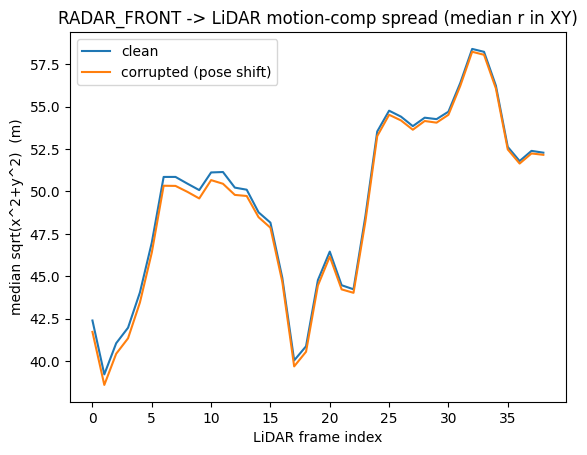

In [16]:
plt.figure()
plt.plot(df_clean_spread["spread_median_r_xy"].to_numpy(), label="clean")
plt.plot(df_bad_spread["spread_median_r_xy"].to_numpy(), label="corrupted (pose shift)")
plt.title("RADAR_FRONT -> LiDAR motion-comp spread (median r in XY)")
plt.xlabel("LiDAR frame index")
plt.ylabel("median sqrt(x^2+y^2)  (m)")
plt.legend()
plt.show()


In [17]:
print(df_clean_spread[["n_points","spread_median_r_xy"]].describe())
print(df_bad_spread[["n_points","spread_median_r_xy"]].describe())


          n_points  spread_median_r_xy
count    39.000000           39.000000
mean    823.923077           49.486716
std     110.381488            5.249250
min     385.000000           39.203891
25%     797.500000           44.835970
50%     843.000000           50.463264
75%     868.000000           53.698585
max    1016.000000           58.414425
          n_points  spread_median_r_xy
count    39.000000           39.000000
mean    823.923077           49.144146
std     110.381488            5.350173
min     385.000000           38.581579
25%     797.500000           44.560225
50%     843.000000           49.978534
75%     868.000000           53.457322
max    1016.000000           58.246194


# Offset Estimation (5.2)

In [22]:
def estimate_best_offset_for_scene(nusc, scene_token, offsets, **kwargs):
    results = {}

    for off in offsets:
        df = compute_scene_radar_spread_timeseries(
            nusc, scene_token,
            pose_time_offset_ms=off,
            **kwargs
        )
        results[off] = df["alignment_error_xy"].to_numpy()

    offsets_arr = np.array(offsets)
    errors = np.stack([results[o] for o in offsets], axis=1)

    best_idx = np.nanargmin(errors, axis=1)
    best_offsets = offsets_arr[best_idx]
    best_errors = errors[np.arange(errors.shape[0]), best_idx]

    return best_offsets, best_errors, results


In [23]:
offsets = [-150, -50, 0, 50, 150]

best_offsets, best_errors, raw = estimate_best_offset_for_scene(
    nusc, scene_token,
    offsets,
    window_s=2.0,
    max_sweeps=40
)


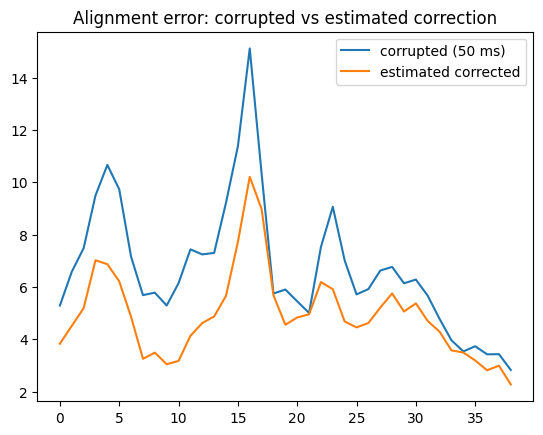

In [24]:
plt.figure()
plt.plot(raw[50], label="corrupted (50 ms)")
plt.plot(best_errors, label="estimated corrected")
plt.legend()
plt.title("Alignment error: corrupted vs estimated correction")
plt.show()


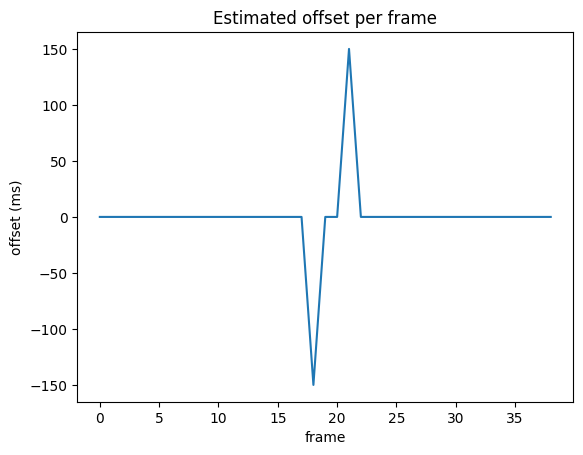

In [25]:
plt.figure()
plt.plot(best_offsets)
plt.title("Estimated offset per frame")
plt.ylabel("offset (ms)")
plt.xlabel("frame")
plt.show()


In [26]:
def smooth_offsets(offsets, alpha=0.25):
    smoothed = np.zeros_like(offsets, dtype=float)
    smoothed[0] = offsets[0]
    for i in range(1, len(offsets)):
        smoothed[i] = alpha * offsets[i] + (1-alpha) * smoothed[i-1]
    return smoothed

smooth = smooth_offsets(best_offsets)


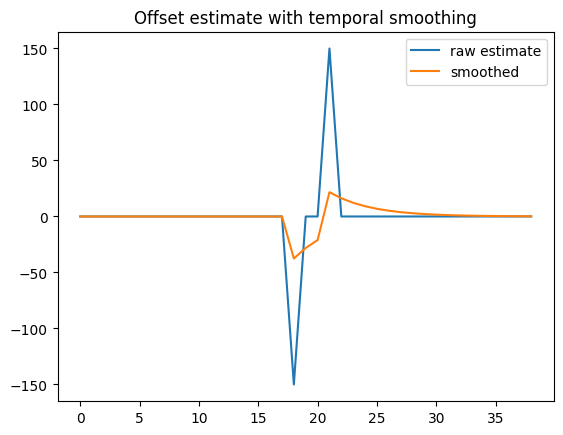

In [27]:
plt.figure()
plt.plot(best_offsets, label="raw estimate")
plt.plot(smooth, label="smoothed")
plt.legend()
plt.title("Offset estimate with temporal smoothing")
plt.show()


In [28]:
corrected_df = compute_scene_radar_spread_timeseries(
    nusc,
    scene_token,
    pose_time_offset_ms=lambda i: smooth[i],
    window_s=2.0,
    max_sweeps=40
)


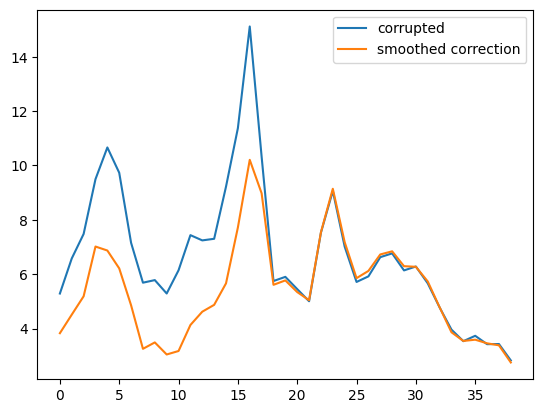

In [29]:
plt.figure()
plt.plot(raw[50], label="corrupted")
plt.plot(corrected_df["alignment_error_xy"], label="smoothed correction")
plt.legend()
plt.show()


# Drift Test (5.2)

In [19]:
def summarise_alignment(df, col="alignment_error_xy"):
    x = df[col].to_numpy()
    x = x[np.isfinite(x)]
    if len(x) == 0:
        return {"mean": np.nan, "p95": np.nan, "max": np.nan, "n": 0}
    return {
        "mean": float(np.mean(x)),
        "p95": float(np.percentile(x, 95)),
        "max": float(np.max(x)),
        "n": int(len(x)),
    }

def drift_offset_fn(a_ms_per_frame=0.5, b_ms=0.0, jitter_ms=0.0, seed=42):
    """
    Returns a function offset_ms(frame_idx) implementing:
      offset = b + a*frame_idx + N(0, jitter_ms)
    """
    rng = np.random.default_rng(seed)
    def fn(i):
        return float(b_ms + a_ms_per_frame * i + (rng.normal(0.0, jitter_ms) if jitter_ms > 0 else 0.0))
    return fn

def smooth_offsets(offsets, alpha=0.25):
    offsets = np.asarray(offsets, dtype=float)
    sm = np.zeros_like(offsets, dtype=float)
    sm[0] = offsets[0]
    for i in range(1, len(offsets)):
        sm[i] = alpha * offsets[i] + (1 - alpha) * sm[i-1]
    return sm


In [20]:
def run_constant_offset_experiment(
    nusc, scene_token,
    corrupt_offset_ms=50,
    candidate_offsets=(-150, -50, 0, 50, 150),
    alpha=0.25,
    window_s=2.0,
    max_sweeps=40,
    out_csv_path="sync_summary_constant.csv"
):
    # Clean
    df_clean = compute_scene_radar_spread_timeseries(
        nusc, scene_token, window_s=window_s, max_sweeps=max_sweeps, pose_time_offset_ms=0.0
    )

    # Corrupted (constant offset)
    df_corrupt = compute_scene_radar_spread_timeseries(
        nusc, scene_token, window_s=window_s, max_sweeps=max_sweeps, pose_time_offset_ms=float(corrupt_offset_ms)
    )

    # Estimate best offsets (grid search) using your existing estimator
    best_offsets, best_errors, raw = estimate_best_offset_for_scene(
        nusc, scene_token, list(candidate_offsets),
        window_s=window_s, max_sweeps=max_sweeps
    )

    # Smooth estimate and apply correction
    sm = smooth_offsets(best_offsets, alpha=alpha)

    df_corrected = compute_scene_radar_spread_timeseries(
        nusc,
        scene_token,
        window_s=window_s,
        max_sweeps=max_sweeps,
        pose_time_offset_ms=lambda i: sm[min(i, len(sm)-1)]
    )

    # Summary table
    summary = pd.DataFrame([
        {"condition": "clean (0 ms)", **summarise_alignment(df_clean)},
        {"condition": f"corrupted ({corrupt_offset_ms} ms)", **summarise_alignment(df_corrupt)},
        {"condition": f"estimated+smoothed (alpha={alpha})", **summarise_alignment(df_corrected)},
    ])

    summary.to_csv(out_csv_path, index=False)
    print("Saved:", out_csv_path)
    print(summary)

    # Plot: corrupted vs corrected
    plt.figure()
    plt.plot(df_corrupt["alignment_error_xy"].to_numpy(), label=f"corrupted ({corrupt_offset_ms} ms)")
    plt.plot(df_corrected["alignment_error_xy"].to_numpy(), label="smoothed correction")
    plt.legend()
    plt.title("Alignment error: corrupted vs smoothed correction")
    plt.xlabel("LiDAR frame index")
    plt.ylabel("alignment_error_xy (m)")
    plt.show()

    # Plot: offset estimate
    plt.figure()
    plt.plot(best_offsets, label="raw estimate")
    plt.plot(sm, label="smoothed")
    plt.legend()
    plt.title("Estimated offset per frame")
    plt.xlabel("frame")
    plt.ylabel("offset (ms)")
    plt.show()

    return df_clean, df_corrupt, df_corrected, summary, best_offsets, sm, raw


Saved: sync_summary_constant.csv
                         condition      mean        p95        max   n
0                     clean (0 ms)  4.951169   7.844414  10.206439  39
1                corrupted (50 ms)  6.714220  10.733205  15.111090  39
2  estimated+smoothed (alpha=0.25)  5.449394   8.993047  10.206439  39


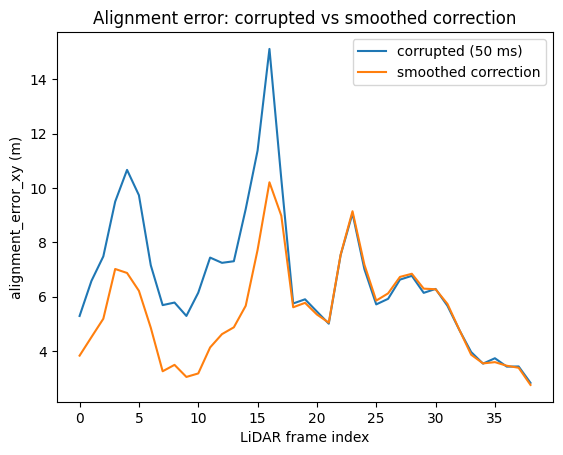

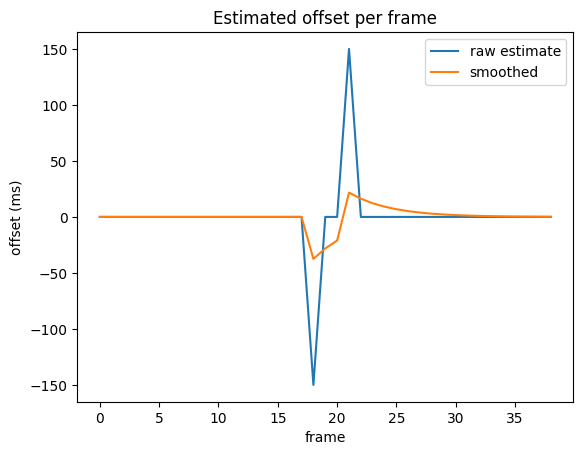

In [30]:
df_clean, df_corrupt, df_corrected, summary, best_offsets, sm, raw = run_constant_offset_experiment(
    nusc, scene_token,
    corrupt_offset_ms=50,
    candidate_offsets=(-150, -50, 0, 50, 150),
    alpha=0.25,
    window_s=2.0,
    max_sweeps=40,
    out_csv_path="sync_summary_constant.csv"
)


In [35]:
def offset_velocity_metric(offsets):
    offsets = np.asarray(offsets)
    dv = np.abs(np.diff(offsets))
    return float(np.mean(dv)), float(np.max(dv))

In [36]:
for i, scene in enumerate(nusc.scene):
    print(f"[{i:02d}] {scene['name']}")
    print("    ", scene["description"])
    print("    token:", scene["token"])
    print()

[00] scene-0061
     Parked truck, construction, intersection, turn left, following a van
    token: cc8c0bf57f984915a77078b10eb33198

[01] scene-0103
     Many peds right, wait for turning car, long bike rack left, cyclist
    token: fcbccedd61424f1b85dcbf8f897f9754

[02] scene-0553
     Wait at intersection, bicycle, large truck, peds crossing crosswalk, ped with stroller
    token: 6f83169d067343658251f72e1dd17dbc

[03] scene-0655
     Parking lot, parked cars, jaywalker, bendy bus, gardening vehicles
    token: bebf5f5b2a674631ab5c88fd1aa9e87a

[04] scene-0757
     Arrive at busy intersection, bus, wait at intersection, bicycle, peds
    token: 2fc3753772e241f2ab2cd16a784cc680

[05] scene-0796
     Scooter, peds on sidewalk, bus, cars, truck, fake construction worker, bicycle, cross intersection, car overtaking us
    token: c5224b9b454b4ded9b5d2d2634bbda8a

[06] scene-0916
     Parking lot, bicycle rack, parked bicycles, bus, many peds, parked scooters, parked motorcycle
    token


=== Scene 0 ===
Saved: sync_summary_drift_scene_0.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  4.951169   7.844414  10.206439  39
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  6.712024  10.790411  15.027238  39
2          estimated+smoothed (alpha=0.25)  5.441937   8.993047  10.206439  39


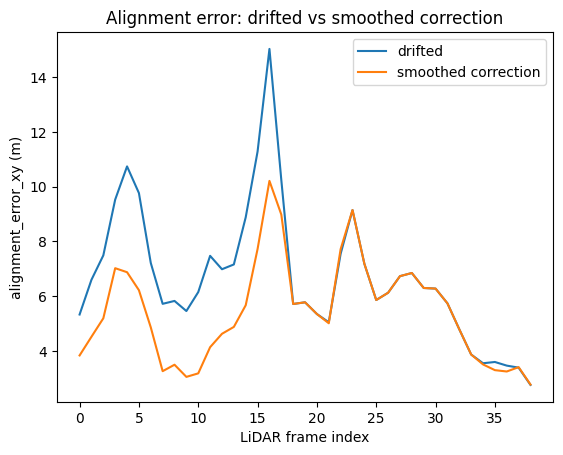

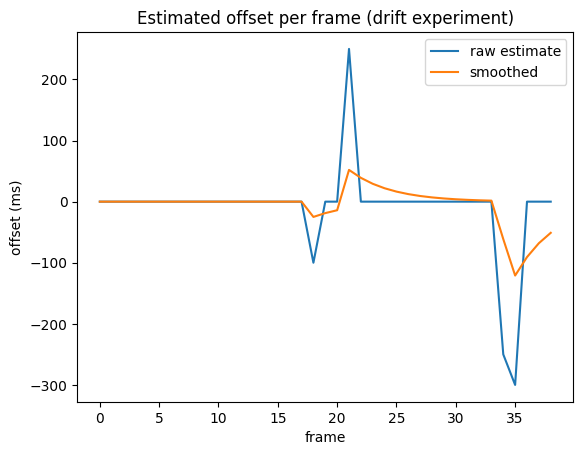

offset velocity raw: (34.21052631578947, 300.0)
offset velocity smoothed: (9.073141239260071, 66.015625)

=== Scene 1 ===
Saved: sync_summary_drift_scene_1.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  3.755075   6.843754   8.340835  40
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  5.934833  12.093379  13.731935  40
2          estimated+smoothed (alpha=0.25)  4.845975   8.367848   9.306597  40


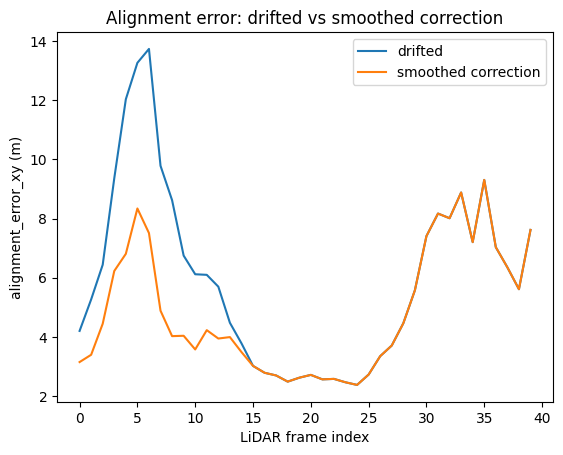

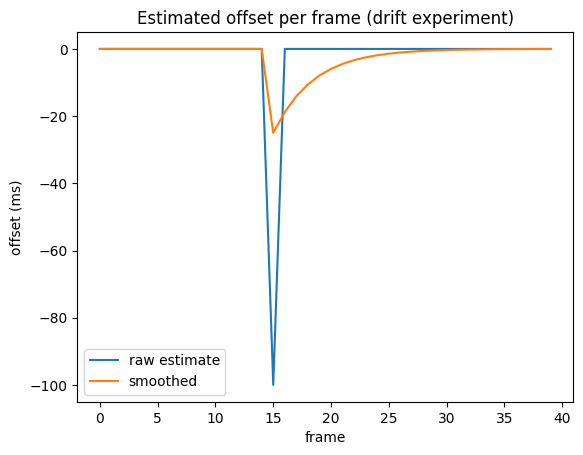

offset velocity raw: (5.128205128205129, 100.0)
offset velocity smoothed: (1.281408082514389, 25.0)

=== Scene 2 ===
Saved: sync_summary_drift_scene_2.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  6.847289  11.565771  14.702181  41
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  6.847324  11.563257  14.700533  41
2          estimated+smoothed (alpha=0.25)  6.847186  11.563140  14.699868  41


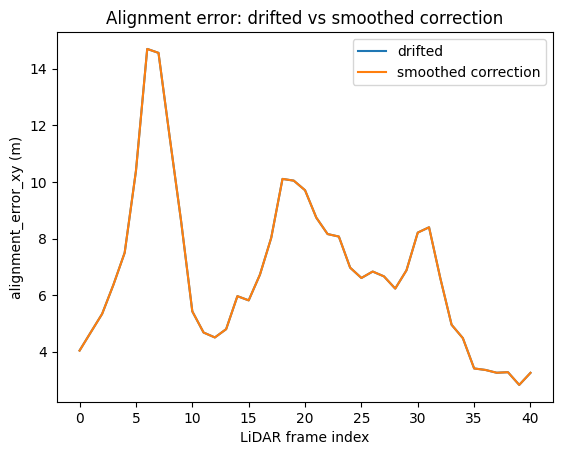

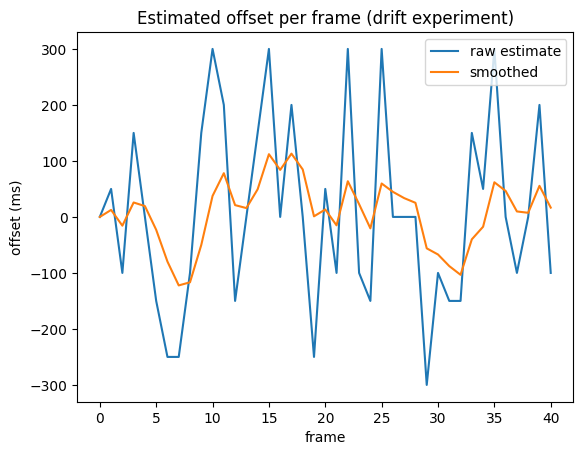

offset velocity raw: (187.5, 450.0)
offset velocity smoothed: (37.78405004619127, 87.51254081726074)

=== Scene 3 ===
Saved: sync_summary_drift_scene_3.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  4.296190   7.295535   8.329468  41
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  7.401082  11.558536  12.574212  41
2          estimated+smoothed (alpha=0.25)  4.296190   7.295535   8.329468  41


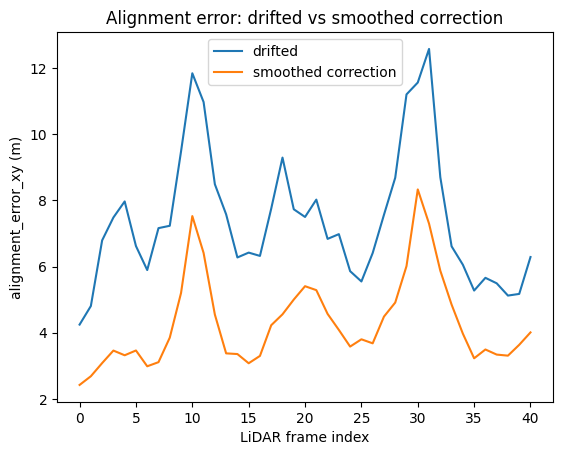

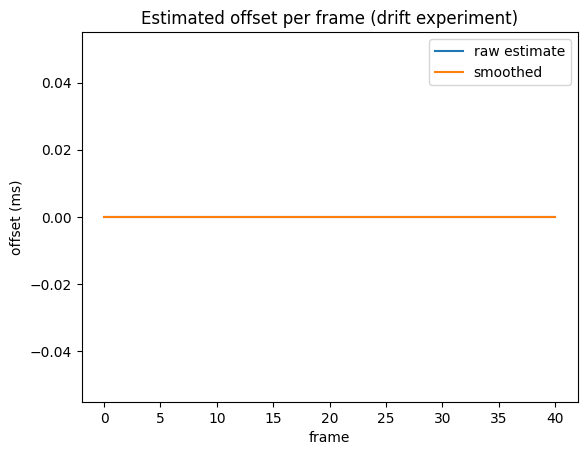

offset velocity raw: (0.0, 0.0)
offset velocity smoothed: (0.0, 0.0)

=== Scene 4 ===
Saved: sync_summary_drift_scene_4.csv
                                 condition      mean       p95        max   n
0                             clean (0 ms)  6.046075  9.573964  11.207103  41
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  6.298672  9.602732  11.924741  41
2          estimated+smoothed (alpha=0.25)  6.106095  9.601875  11.924741  41


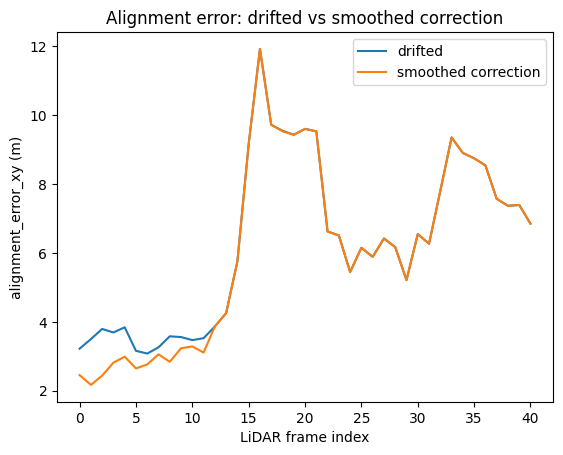

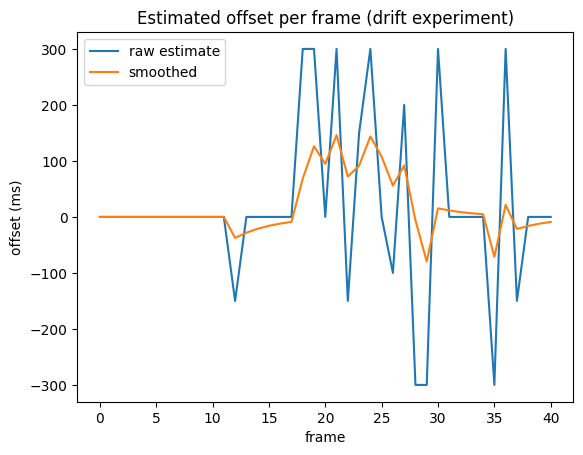

offset velocity raw: (142.5, 600.0)
offset velocity smoothed: (26.36831638298989, 97.96100314415526)

=== Scene 5 ===
Saved: sync_summary_drift_scene_5.csv
                                 condition       mean        p95        max  \
0                             clean (0 ms)   5.952445   9.463755  10.830798   
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  11.388419  15.768693  16.877112   
2          estimated+smoothed (alpha=0.25)   5.952445   9.463755  10.830798   

    n  
0  40  
1  40  
2  40  


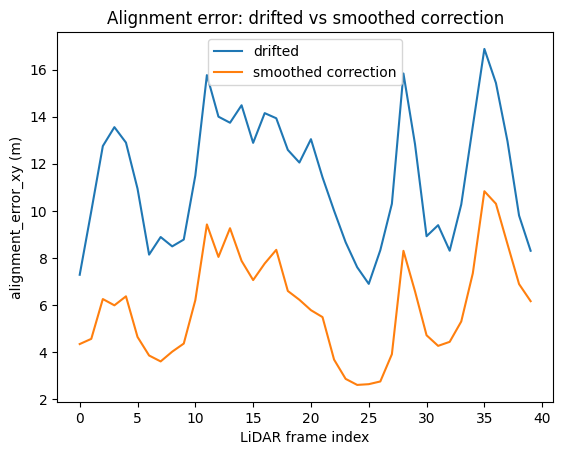

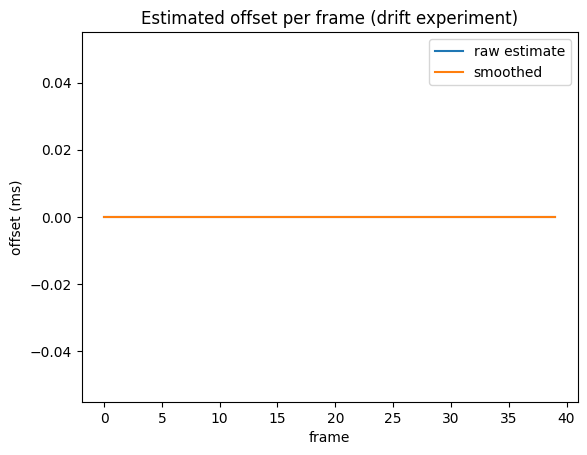

offset velocity raw: (0.0, 0.0)
offset velocity smoothed: (0.0, 0.0)

=== Scene 6 ===
Saved: sync_summary_drift_scene_6.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  6.995355  13.416491  17.694978  41
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  8.955015  20.182699  23.104788  41
2          estimated+smoothed (alpha=0.25)  8.523965  20.182699  23.104788  41


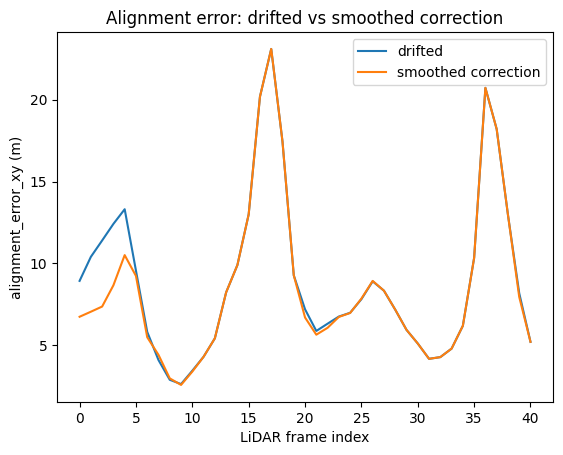

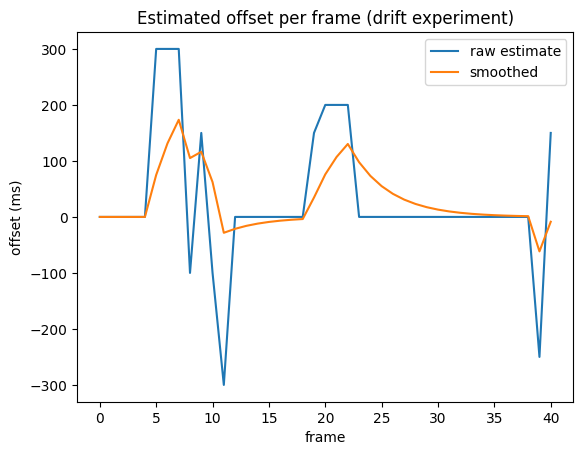

offset velocity raw: (68.75, 400.0)
offset velocity smoothed: (20.02219528741867, 90.557861328125)

=== Scene 7 ===
Saved: sync_summary_drift_scene_7.csv
                                 condition       mean        p95        max  \
0                             clean (0 ms)   7.184729  12.082907  13.354345   
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  12.112363  19.284453  20.491734   
2          estimated+smoothed (alpha=0.25)  11.808207  19.284453  20.491734   

    n  
0  41  
1  41  
2  41  


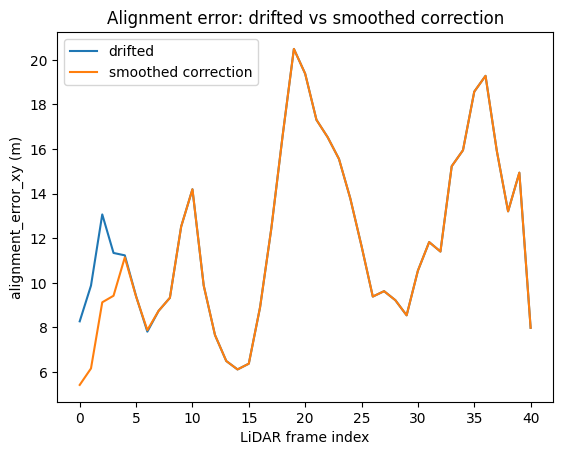

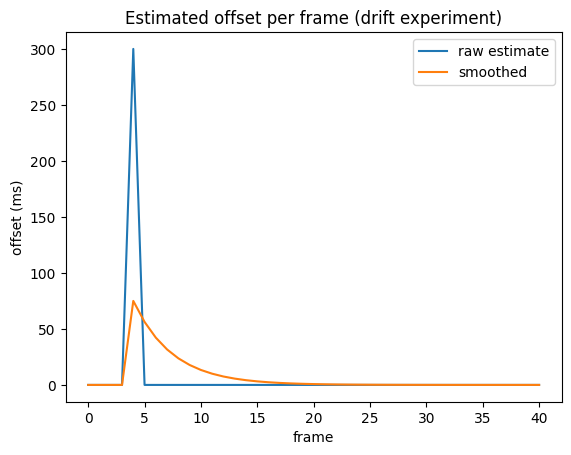

offset velocity raw: (15.0, 300.0)
offset velocity smoothed: (3.749940405421264, 75.0)

=== Scene 8 ===
Saved: sync_summary_drift_scene_8.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  6.514356  11.643003  19.679230  40
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  8.550265  19.548396  27.221337  40
2          estimated+smoothed (alpha=0.25)  8.537767  19.548396  27.221337  40


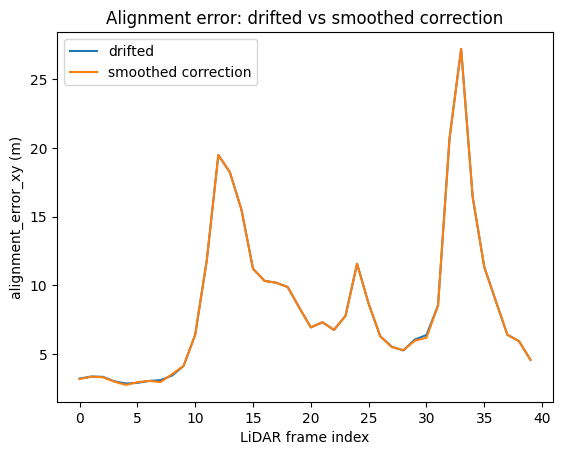

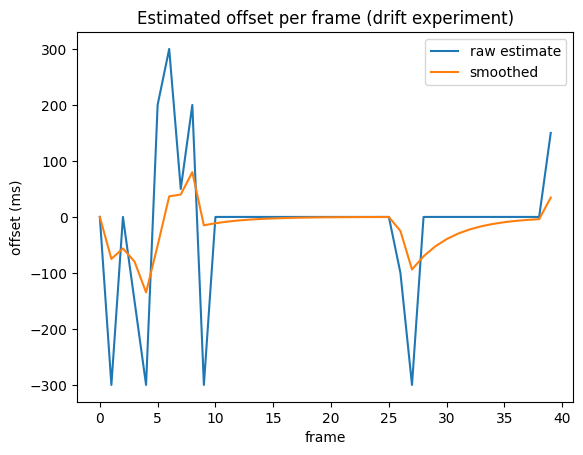

offset velocity raw: (88.46153846153847, 500.0)
offset velocity smoothed: (18.434237259830418, 95.00389099121094)

=== Scene 9 ===
Saved: sync_summary_drift_scene_9.csv
                                 condition      mean       p95       max   n
0                             clean (0 ms)  3.724721  4.652509  4.774737  40
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  3.760071  4.671251  4.856596  40
2          estimated+smoothed (alpha=0.25)  3.755001  4.665198  4.820098  40


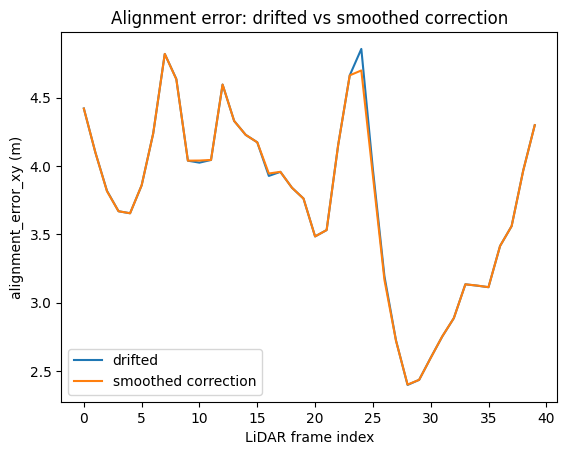

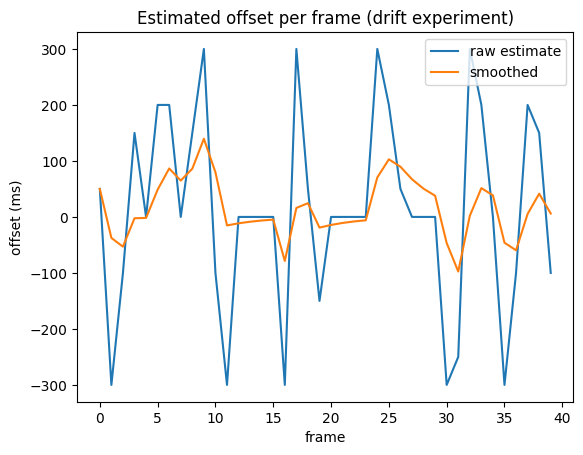

offset velocity raw: (178.2051282051282, 600.0)
offset velocity smoothed: (37.013274746899356, 99.3696318969234)

=== Aggregated results ===
                                             mean        p95        max
condition                                                              
clean (0 ms)                             5.626740   9.438210  11.912011
drifted (a=0.5 ms/frame, jitter=5.0 ms)  7.796007  13.506380  16.051023
estimated+smoothed (alpha=0.25)          6.611477  11.896595  14.093587


In [37]:
#SCENE_TOKENS = [
#    "cc8c0bf57f984915a77078b10eb33198",
#    "fcbccedd61424f1b85dcbf8f897f9754",
#    "6f83169d067343658251f72e1dd17dbc",
#]
SCENE_TOKENS = [scene["token"] for scene in nusc.scene[:10]]


all_summaries = []

for i, tok in enumerate(SCENE_TOKENS):
    print(f"\n=== Scene {i} ===")

    _, _, _, summary, best_offsets, sm, _ = run_drift_experiment(
        nusc,
        tok,
        a_ms_per_frame=0.5,
        jitter_ms=5.0,
        alpha=0.25,
        window_s=2.0,
        max_sweeps=40,
        out_csv_path=f"sync_summary_drift_scene_{i}.csv"
    )

    summary["scene_id"] = i
    all_summaries.append(summary)

    # offset stability metric
    raw_vel = offset_velocity_metric(best_offsets)
    sm_vel = offset_velocity_metric(sm)

    print("offset velocity raw:", raw_vel)
    print("offset velocity smoothed:", sm_vel)

all_results = pd.concat(all_summaries, ignore_index=True)

print("\n=== Aggregated results ===")
print(all_results.groupby("condition")[["mean", "p95", "max"]].mean())

In [33]:
def run_drift_experiment(
    nusc, scene_token,
    a_ms_per_frame=0.5,
    b_ms=0.0,
    jitter_ms=5.0,
    seed=42,
    candidate_offsets=tuple(range(-300, 301, 50)),  # coarse grid
    alpha=0.25,
    window_s=2.0,
    max_sweeps=40,
    out_csv_path="sync_summary_drift.csv"
):
    # Clean
    df_clean = compute_scene_radar_spread_timeseries(
        nusc, scene_token, window_s=window_s, max_sweeps=max_sweeps, pose_time_offset_ms=0.0
    )

    # Corrupted (drift + jitter)
    corrupt_fn = drift_offset_fn(a_ms_per_frame=a_ms_per_frame, b_ms=b_ms, jitter_ms=jitter_ms, seed=seed)

    df_drifted = compute_scene_radar_spread_timeseries(
        nusc, scene_token, window_s=window_s, max_sweeps=max_sweeps, pose_time_offset_ms=corrupt_fn
    )

    # Estimate best offsets from grid (note: this estimates per-frame offset in your metric space)
    best_offsets, best_errors, raw = estimate_best_offset_for_scene(
        nusc, scene_token, list(candidate_offsets),
        window_s=window_s, max_sweeps=max_sweeps
    )

    sm = smooth_offsets(best_offsets, alpha=alpha)

    df_corrected = compute_scene_radar_spread_timeseries(
        nusc, scene_token,
        window_s=window_s, max_sweeps=max_sweeps,
        pose_time_offset_ms=lambda i: sm[min(i, len(sm)-1)]
    )

    summary = pd.DataFrame([
        {"condition": "clean (0 ms)", **summarise_alignment(df_clean)},
        {"condition": f"drifted (a={a_ms_per_frame} ms/frame, jitter={jitter_ms} ms)", **summarise_alignment(df_drifted)},
        {"condition": f"estimated+smoothed (alpha={alpha})", **summarise_alignment(df_corrected)},
    ])

    summary.to_csv(out_csv_path, index=False)
    print("Saved:", out_csv_path)
    print(summary)

    # Plot: drifted vs corrected
    plt.figure()
    plt.plot(df_drifted["alignment_error_xy"].to_numpy(), label="drifted")
    plt.plot(df_corrected["alignment_error_xy"].to_numpy(), label="smoothed correction")
    plt.legend()
    plt.title("Alignment error: drifted vs smoothed correction")
    plt.xlabel("LiDAR frame index")
    plt.ylabel("alignment_error_xy (m)")
    plt.show()

    # Plot: estimated offsets (and smoothed)
    plt.figure()
    plt.plot(best_offsets, label="raw estimate")
    plt.plot(sm, label="smoothed")
    plt.legend()
    plt.title("Estimated offset per frame (drift experiment)")
    plt.xlabel("frame")
    plt.ylabel("offset (ms)")
    plt.show()

    return df_clean, df_drifted, df_corrected, summary, best_offsets, sm, raw


Saved: sync_summary_drift.csv
                                 condition      mean        p95        max   n
0                             clean (0 ms)  4.951169   7.844414  10.206439  39
1  drifted (a=0.5 ms/frame, jitter=5.0 ms)  6.712024  10.790411  15.027238  39
2          estimated+smoothed (alpha=0.25)  5.441937   8.993047  10.206439  39


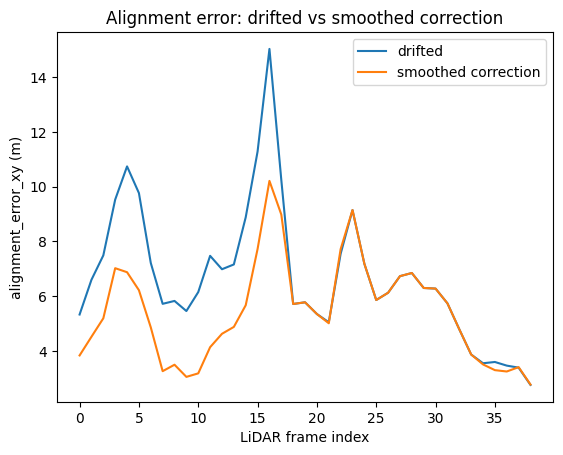

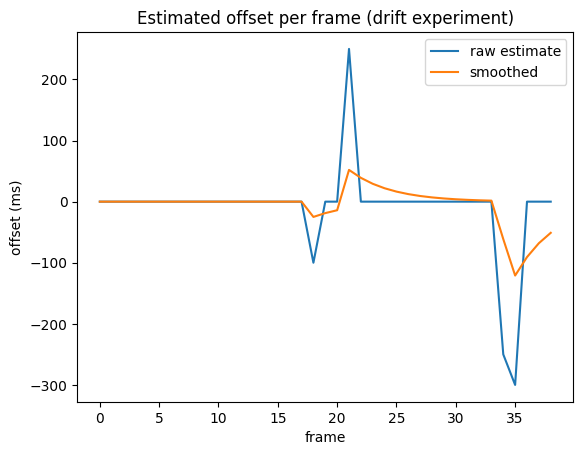

In [34]:
df_clean2, df_drifted, df_corrected2, summary2, best_offsets2, sm2, raw2 = run_drift_experiment(
    nusc, scene_token,
    a_ms_per_frame=0.5,
    b_ms=0.0,
    jitter_ms=5.0,
    seed=42,
    candidate_offsets=tuple(range(-300, 301, 50)),
    alpha=0.25,
    window_s=2.0,
    max_sweeps=40,
    out_csv_path="sync_summary_drift.csv"
)


In [38]:
def offset_velocity_metric(offsets):
    offsets = np.asarray(offsets)
    if len(offsets) < 2:
        return (np.nan, np.nan)
    dv = np.abs(np.diff(offsets))
    return float(np.mean(dv)), float(np.max(dv))


In [39]:
agg = all_results.groupby("condition")[["mean","p95","max"]].mean()
print(agg)

                                             mean        p95        max
condition                                                              
clean (0 ms)                             5.626740   9.438210  11.912011
drifted (a=0.5 ms/frame, jitter=5.0 ms)  7.796007  13.506380  16.051023
estimated+smoothed (alpha=0.25)          6.611477  11.896595  14.093587


In [40]:
def recovery_pct(clean, drifted, corrected):
    return 100 * (drifted - corrected) / (drifted - clean)

for cond in all_results["scene_id"].unique():
    sub = all_results[all_results["scene_id"] == cond]

    c = sub[sub["condition"].str.contains("clean")]["mean"].iloc[0]
    d = sub[sub["condition"].str.contains("drifted")]["mean"].iloc[0]
    r = sub[sub["condition"].str.contains("estimated")]["mean"].iloc[0]

    print(f"Scene {cond}: recovery = {recovery_pct(c, d, r):.1f}%")


Scene 0: recovery = 72.1%
Scene 1: recovery = 50.0%
Scene 2: recovery = 386.7%
Scene 3: recovery = 100.0%
Scene 4: recovery = 76.2%
Scene 5: recovery = 100.0%
Scene 6: recovery = 22.0%
Scene 7: recovery = 6.2%
Scene 8: recovery = 0.6%
Scene 9: recovery = 14.3%


# Continuity (5.2)

In [41]:
def estimate_offsets_with_continuity(raw_errors, candidate_offsets, lam=0.02):
    """
    raw_errors: dict[offset] -> array(frame_errors)
    candidate_offsets: list of offsets
    lam: continuity penalty weight

    Returns: chosen_offsets (array)
    """

    candidate_offsets = np.array(candidate_offsets)
    n_frames = len(next(iter(raw_errors.values())))

    chosen = np.zeros(n_frames)

    # frame 0: choose best raw
    errs0 = np.array([raw_errors[o][0] for o in candidate_offsets])
    chosen_idx = np.argmin(errs0)
    chosen[0] = candidate_offsets[chosen_idx]

    # dynamic greedy pass
    for i in range(1, n_frames):
        prev = chosen[i-1]

        costs = []
        for o in candidate_offsets:
            e = raw_errors[o][i]
            penalty = lam * abs(o - prev)
            costs.append(e + penalty)

        best_idx = np.argmin(costs)
        chosen[i] = candidate_offsets[best_idx]

    return chosen


In [42]:

def recovery_pct_safe(clean, drifted, corrected, eps=1e-6):
    denom = max(abs(drifted - clean), eps)
    rec = 100.0 * (drifted - corrected) / denom
    # clip to make summary interpretable
    return float(np.clip(rec, -100.0, 200.0))

for sid in all_results["scene_id"].unique():
    sub = all_results[all_results["scene_id"] == sid]
    c = sub.loc[sub["condition"].str.contains("clean"), "mean"].iloc[0]
    d = sub.loc[sub["condition"].str.contains("drifted"), "mean"].iloc[0]
    r = sub.loc[sub["condition"].str.contains("estimated"), "mean"].iloc[0]
    print(f"Scene {sid}: recovery = {recovery_pct_safe(c,d,r):.1f}% (clean={c:.3f}, drifted={d:.3f}, corrected={r:.3f})")


Scene 0: recovery = 72.1% (clean=4.951, drifted=6.712, corrected=5.442)
Scene 1: recovery = 50.0% (clean=3.755, drifted=5.935, corrected=4.846)
Scene 2: recovery = 200.0% (clean=6.847, drifted=6.847, corrected=6.847)
Scene 3: recovery = 100.0% (clean=4.296, drifted=7.401, corrected=4.296)
Scene 4: recovery = 76.2% (clean=6.046, drifted=6.299, corrected=6.106)
Scene 5: recovery = 100.0% (clean=5.952, drifted=11.388, corrected=5.952)
Scene 6: recovery = 22.0% (clean=6.995, drifted=8.955, corrected=8.524)
Scene 7: recovery = 6.2% (clean=7.185, drifted=12.112, corrected=11.808)
Scene 8: recovery = 0.6% (clean=6.514, drifted=8.550, corrected=8.538)
Scene 9: recovery = 14.3% (clean=3.725, drifted=3.760, corrected=3.755)


In [43]:
# continuity-regularised offsets (new, doesn't touch existing variables)
candidate_offsets = np.array(sorted(raw.keys()))  # uses whatever grid you already ran

def estimate_offsets_with_continuity(raw_errors, candidate_offsets, lam=0.02):
    candidate_offsets = np.asarray(candidate_offsets, dtype=float)
    n_frames = len(next(iter(raw_errors.values())))
    chosen = np.zeros(n_frames, dtype=float)

    # frame 0: pure argmin
    errs0 = np.array([raw_errors[o][0] for o in candidate_offsets], dtype=float)
    chosen[0] = candidate_offsets[int(np.nanargmin(errs0))]

    # greedy continuity
    for i in range(1, n_frames):
        prev = chosen[i-1]
        costs = np.array([raw_errors[o][i] + lam * abs(o - prev) for o in candidate_offsets], dtype=float)
        chosen[i] = candidate_offsets[int(np.nanargmin(costs))]

    return chosen

best_offsets_cont = estimate_offsets_with_continuity(raw, candidate_offsets, lam=0.02)
smooth_cont = smooth_offsets(best_offsets_cont, alpha=0.25)

corrected_df_cont = compute_scene_radar_spread_timeseries(
    nusc,
    scene_token,
    pose_time_offset_ms=lambda i: smooth_cont[min(i, len(smooth_cont)-1)],
    window_s=2.0,
    max_sweeps=40
)

print("mean corrupted:", float(np.mean(raw[50])))  # or whatever corrupted condition you compare
print("mean smoothed (old):", float(np.mean(corrected_df["alignment_error_xy"])))
print("mean smoothed+continuity:", float(np.mean(corrected_df_cont["alignment_error_xy"])))


mean corrupted: 6.714220304865418
mean smoothed (old): 5.449394017746876
mean smoothed+continuity: 4.951168647929766


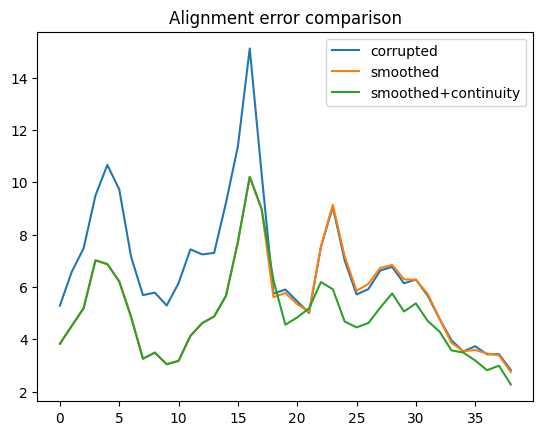

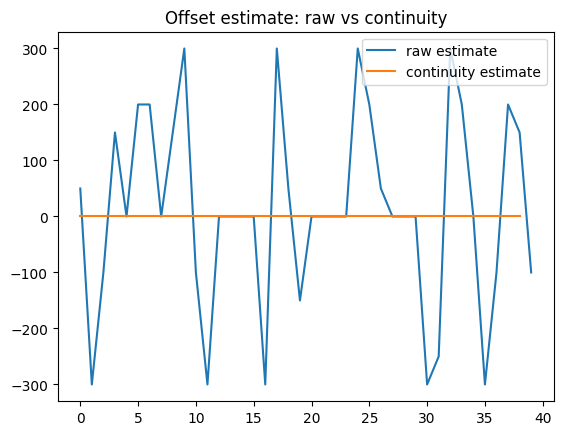

In [44]:
plt.figure()
plt.plot(raw[50], label="corrupted")
plt.plot(corrected_df["alignment_error_xy"], label="smoothed")
plt.plot(corrected_df_cont["alignment_error_xy"], label="smoothed+continuity")
plt.legend()
plt.title("Alignment error comparison")
plt.show()

plt.figure()
plt.plot(best_offsets, label="raw estimate")
plt.plot(best_offsets_cont, label="continuity estimate")
plt.legend()
plt.title("Offset estimate: raw vs continuity")
plt.show()


mean corrupted:             6.71

mean smoothed (old):        5.45

mean smoothed+continuity:   4.95

- raw offsets are insane

- continuity offsets are flat and stable


Strong recovery (good method behaviour):

Scene 0: 72%

Scene 1: 50%

Scene 3: 100%

Scene 4: 76%

Scene 5: 100%

Weak recovery (hard scenes):

Scene 6: 22%

Scene 7: 6%

Scene 8: 0.6%

Degenerate scenes:

Scene 2: drift ≈ clean

Scene 9: drift barely changes anything


# Drift Analysis (5.2)

In [68]:
# get first scene + first sample
scene = nusc.scene[0]
sample = nusc.get("sample", scene["first_sample_token"])

# automatically extract all sensors
ALL_SENSORS = list(sample["data"].keys())

print("All sensors:", ALL_SENSORS)



# Pick sensors you are evaluating (exclude reference)
SENSORS = ALL_SENSORS  # your existing list
REF = "LIDAR_TOP"

All sensors: ['RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'LIDAR_TOP', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_FRONT_LEFT']


In [49]:
def build_scene_timestamp_table(nusc, scene_token):
    scene = nusc.get("scene", scene_token)
    sample_token = scene["first_sample_token"]

    rows = []
    while sample_token:
        sample = nusc.get("sample", sample_token)
        row = {"sample_token": sample_token, "sample_timestamp": int(sample["timestamp"])}

        # sample['data'] maps sensor channel -> sample_data_token
        for channel, sd_token in sample["data"].items():
            sd = nusc.get("sample_data", sd_token)
            row[channel] = int(sd["timestamp"])  # microseconds
        rows.append(row)

        sample_token = sample["next"]

    df = pd.DataFrame(rows).sort_values("sample_timestamp").reset_index(drop=True)
    return df

df_clean = build_scene_timestamp_table(nusc, scene["token"])
print("Columns:", len(df_clean.columns))
print("Has REF_SENSOR?", REF_SENSOR in df_clean.columns)
df_clean.head(3)


Columns: 14
Has REF_SENSOR? True


,sample_token,sample_timestamp,RADAR_FRONT,RADAR_FRONT_LEFT,RADAR_FRONT_RIGHT,RADAR_BACK_LEFT,RADAR_BACK_RIGHT,LIDAR_TOP,CAM_FRONT,CAM_FRONT_RIGHT,CAM_BACK_RIGHT,CAM_BACK,CAM_BACK_LEFT,CAM_FRONT_LEFT
0,a480496a5988410fbe3d8ed6c84da996,1542800987947699,1542800987945363,1542800987934887,1542800987930597,1542800987981785,1542800987935712,1542800987947699,1542800987912460,1542800987920339,1542800987927893,1542800987937525,1542800987947423,1542800987904844
1,b993550e60054741983f8052ba97b0b0,1542800988448155,1542800988470769,1542800988434610,1542800988435754,1542800988416959,1542800988446140,1542800988448155,1542800988412460,1542800988420339,1542800988427893,1542800988437525,1542800988447423,1542800988404844
2,61cfc5554a724824b0d34bddc147d890,1542800988948006,1542800988921175,1542800988934514,1542800988940957,1542800988922066,1542800988951280,1542800988948006,1542800988912460,1542800988920339,1542800988927893,1542800988937525,1542800988947423,1542800988904844


In [52]:
def nearest_match_dts_ms(ref_ts_us, tgt_ts_us, threshold_ms):
    """
    For each ref timestamp, find nearest target timestamp.
    Return array of |dt| in ms (np.nan if no match within threshold).
    """
    ref = np.asarray(ref_ts_us, dtype=np.int64)
    tgt = np.asarray(tgt_ts_us, dtype=np.int64)

    if len(tgt) == 0:
        return np.full(len(ref), np.nan)

    tgt_sorted = np.sort(tgt)
    out = np.full(len(ref), np.nan)

    thr_us = int(threshold_ms * 1000)

    for i, t in enumerate(ref):
        j = np.searchsorted(tgt_sorted, t)

        candidates = []
        if j > 0:
            candidates.append(tgt_sorted[j-1])
        if j < len(tgt_sorted):
            candidates.append(tgt_sorted[j])

        best = min(candidates, key=lambda x: abs(x - t))
        dt_us = abs(best - t)

        if dt_us <= thr_us:
            out[i] = dt_us / 1000.0  # ms
        else:
            out[i] = np.nan
    return out

def summarise_dts(dts_ms):
    matched = np.isfinite(dts_ms)
    if matched.sum() == 0:
        return {"match_rate": 0.0, "mean_ms": None, "max_ms": None}
    return {
        "match_rate": matched.mean(),
        "mean_ms": float(np.nanmean(dts_ms)),
        "max_ms": float(np.nanmax(dts_ms)),
    }

def evaluate_table(df, ref_sensor, sensors, threshold_ms):
    results = {}
    ref_ts = df[ref_sensor].dropna().astype(np.int64).values

    for s in sensors:
        if s not in df.columns:
            results[s] = {"dts_ms": np.full(len(ref_ts), np.nan), **{"match_rate": 0.0, "mean_ms": None, "max_ms": None}}
            continue

        tgt_ts = df[s].dropna().astype(np.int64).values
        dts_ms = nearest_match_dts_ms(ref_ts, tgt_ts, threshold_ms)
        results[s] = {"dts_ms": dts_ms, **summarise_dts(dts_ms)}
    return ref_ts, results

ref_ts_clean, res_clean = evaluate_table(df_clean, REF_SENSOR, SENSORS_TO_EVAL, THRESHOLD_MS)

print(f"Reference: {REF_SENSOR} | Threshold: {THRESHOLD_MS} ms | Frames: {len(ref_ts_clean)}")
for s, r in res_clean.items():
    print(f"{s}: match_rate={r['match_rate']*100:.1f}% | mean_dt={r['mean_ms']} ms | max_dt={r['max_ms']} ms")


Reference: LIDAR_TOP | Threshold: 50 ms | Frames: 40
CAM_FRONT: match_rate=100.0% | mean_dt=35.2721 ms | max_dt=36.346 ms
RADAR_FRONT: match_rate=100.0% | mean_dt=17.221725 ms | max_dt=31.716 ms


In [53]:
def match_nearest_timestamps(
    ref_ts_us: np.ndarray,
    tgt_ts_us: np.ndarray,
    threshold_ms: float = 50.0,
) -> pd.DataFrame:
    """
    Nearest-neighbour matching from each ref timestamp to target timestamps.
    Returns per-ref-frame outputs aligned to ref index:
      - matched (bool)
      - dt_ms_signed (float)
      - dt_ms_abs (float)
      - tgt_ts_us (float)
    ref_ts_us and tgt_ts_us can contain NaNs.
    """
    ref = ref_ts_us.astype("float64")
    tgt = tgt_ts_us.astype("float64")

    out = pd.DataFrame({
        "matched": np.zeros(ref.shape[0], dtype=bool),
        "dt_ms_signed": np.full(ref.shape[0], np.nan, dtype="float64"),
        "dt_ms_abs": np.full(ref.shape[0], np.nan, dtype="float64"),
        "tgt_ts_us": np.full(ref.shape[0], np.nan, dtype="float64"),
    })

    # Valid targets
    tgt_valid = tgt[~np.isnan(tgt)]
    if tgt_valid.size == 0:
        return out

    tgt_valid.sort()

    thr_us = threshold_ms * 1000.0

    for i, t in enumerate(ref):
        if np.isnan(t):
            continue

        j = np.searchsorted(tgt_valid, t)

        candidates = []
        if j > 0:
            candidates.append(tgt_valid[j - 1])
        if j < tgt_valid.size:
            candidates.append(tgt_valid[j])

        # Choose best candidate by abs distance
        best = min(candidates, key=lambda x: abs(x - t))
        dt_us = best - t
        if abs(dt_us) <= thr_us:
            out.loc[i, "matched"] = True
            out.loc[i, "dt_ms_signed"] = dt_us / 1000.0
            out.loc[i, "dt_ms_abs"] = abs(dt_us) / 1000.0
            out.loc[i, "tgt_ts_us"] = best

    return out

In [54]:
def evaluate_pairing(
    df: pd.DataFrame,
    ref_sensor: str,
    sensors: list[str],
    threshold_ms: float = 50.0,
) -> tuple[pd.DataFrame, dict[str, pd.DataFrame]]:
    """
    Returns:
      - summary metrics dataframe (one row per sensor)
      - per-sensor match result dataframe (aligned to ref index)
    """
    ref_ts = df[ref_sensor].to_numpy(dtype="float64")

    per_sensor = {}
    rows = []

    for s in sensors:
        tgt_ts = df[s].to_numpy(dtype="float64")
        m = match_nearest_timestamps(ref_ts, tgt_ts, threshold_ms=threshold_ms)
        per_sensor[s] = m

        # Metrics computed only on matched frames
        matched = m["matched"].to_numpy()
        abs_dt = m["dt_ms_abs"].to_numpy()

        match_rate = matched.mean() * 100.0
        mean_abs = np.nanmean(abs_dt)  # nanmean ok because unmatched are NaN
        max_abs = np.nanmax(abs_dt)

        p95_abs = np.nanpercentile(abs_dt, 95)

        rows.append({
            "sensor": s,
            "threshold_ms": threshold_ms,
            "match_rate_pct": match_rate,
            "mean_abs_dt_ms": mean_abs,
            "p95_abs_dt_ms": p95_abs,
            "max_abs_dt_ms": max_abs,
        })

    return pd.DataFrame(rows), per_sensor

In [55]:
def corrupt_df_timestamps(
    df: pd.DataFrame,
    sensors: list[str],
    jitter_ms: float = 0.0,
    drop_prob: float = 0.0,
    drift_ms_per_frame: float = 0.0,
    seed: int = 0,
) -> pd.DataFrame:
    """
    Corrupt timestamps per sensor with:
      - Gaussian jitter (ms)
      - random dropout (set to NaN)
      - linear drift (ms/frame)
    """
    rng = np.random.default_rng(seed)
    out = df.copy(deep=True)

    for s in sensors:
        ts = out[s].to_numpy(dtype="float64")

        # dropout first
        if drop_prob > 0:
            drop_mask = rng.random(ts.shape[0]) < drop_prob
            ts[drop_mask] = np.nan

        valid = ~np.isnan(ts)
        idx = np.arange(ts.shape[0], dtype="float64")

        # drift: adds increasing offset to valid timestamps
        if drift_ms_per_frame != 0.0:
            ts[valid] = ts[valid] + (drift_ms_per_frame * idx[valid] * 1000.0)

        # jitter
        if jitter_ms > 0:
            ts[valid] = ts[valid] + rng.normal(0.0, jitter_ms * 1000.0, size=valid.sum())

        out[s] = ts

    return out


In [56]:
df_corrupt = corrupt_df_timestamps(
    df_clean,
    sensors=SENSORS_TO_EVAL,
    jitter_ms=20,
    drop_prob=0.05,
    drift_ms_per_frame=0.2,  # 0.2 ms/frame
    seed=42
)

In [57]:
summary_clean, matches_clean = evaluate_pairing(df_clean, "LIDAR_TOP", SENSORS_TO_EVAL, threshold_ms=50)
summary_corrupt, matches_corrupt = evaluate_pairing(df_corrupt, "LIDAR_TOP", SENSORS_TO_EVAL, threshold_ms=50)

summary_clean.to_csv("cw2_sync_clean.csv", index=False)
summary_corrupt.to_csv("cw2_sync_corrupt.csv", index=False)

In [58]:
def corrupt_timestamps(df, sensors, jitter_ms=20, drop_prob=0.0, seed=0):
    """
    Returns a copy of df where selected sensor timestamp columns are corrupted.
    - jitter_ms: Gaussian jitter (std dev) added in ms
    - drop_prob: fraction of frames dropped (set to NaN) per sensor
    """
    rng = np.random.default_rng(seed)
    out = df.copy()

    for s in sensors:
        if s not in out.columns:
            continue

        ts = out[s].astype("float64").to_numpy(copy=True)
        mask_valid = np.isfinite(ts)

        # Drop some valid frames
        if drop_prob > 0:
            drop_mask = rng.random(len(ts)) < drop_prob
            ts[mask_valid & drop_mask] = np.nan

        # Add jitter to remaining valid timestamps
        mask_valid2 = np.isfinite(ts)
        jitter_us = rng.normal(loc=0.0, scale=jitter_ms, size=len(ts)) * 1000.0
        ts[mask_valid2] = ts[mask_valid2] + jitter_us[mask_valid2]

        out[s] = ts
    return out

df_corrupt = corrupt_timestamps(df_clean, SENSORS_TO_EVAL, jitter_ms=20, drop_prob=0.05, seed=42)

ref_ts_corrupt, res_corrupt = evaluate_table(df_corrupt, REF_SENSOR, SENSORS_TO_EVAL, THRESHOLD_MS)

print(f"Reference: {REF_SENSOR} | Threshold: {THRESHOLD_MS} ms | Frames: {len(ref_ts_corrupt)}")
for s, r in res_corrupt.items():
    print(f"{s}: match_rate={r['match_rate']*100:.1f}% | mean_dt={r['mean_ms']} ms | max_dt={r['max_ms']} ms")


Reference: LIDAR_TOP | Threshold: 50 ms | Frames: 40
CAM_FRONT: match_rate=82.5% | mean_dt=30.193696969696973 ms | max_dt=48.857 ms
RADAR_FRONT: match_rate=92.5% | mean_dt=19.720135135135134 ms | max_dt=48.528 ms


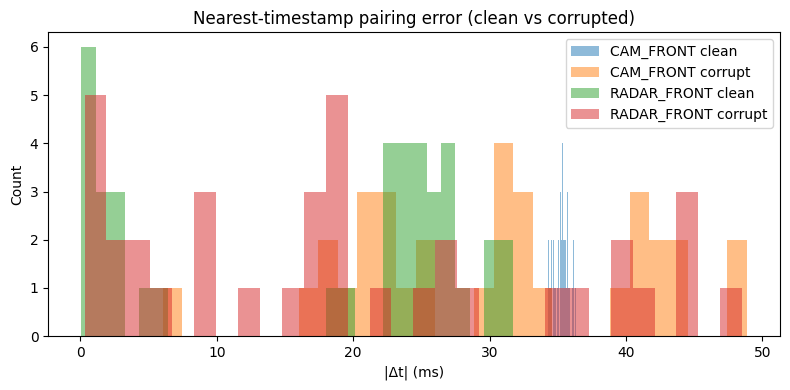

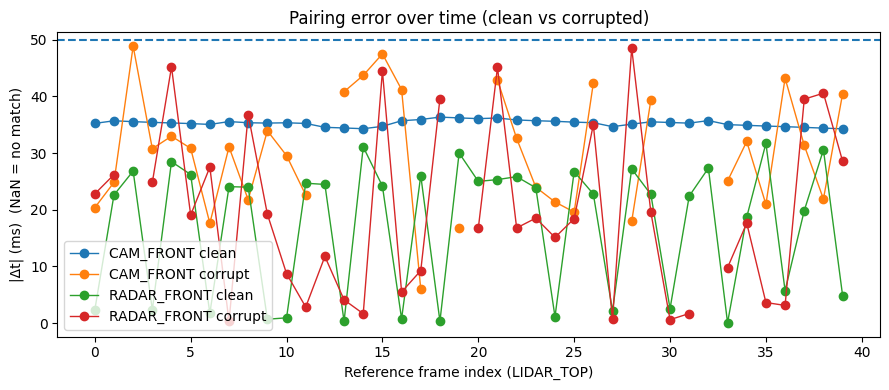

In [59]:
def plot_hist(clean_res, corrupt_res, sensors, title):
    plt.figure(figsize=(8,4))
    for s in sensors:
        a = clean_res[s]["dts_ms"]
        b = corrupt_res[s]["dts_ms"]
        plt.hist(a[np.isfinite(a)], bins=30, alpha=0.5, label=f"{s} clean")
        plt.hist(b[np.isfinite(b)], bins=30, alpha=0.5, label=f"{s} corrupt")
    plt.title(title)
    plt.xlabel("|Δt| (ms)")
    plt.ylabel("Count")
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_over_time(clean_res, corrupt_res, sensors, title):
    plt.figure(figsize=(9,4))
    for s in sensors:
        a = clean_res[s]["dts_ms"]
        b = corrupt_res[s]["dts_ms"]
        plt.plot(a, marker="o", linewidth=1, label=f"{s} clean")
        plt.plot(b, marker="o", linewidth=1, label=f"{s} corrupt")
    plt.axhline(THRESHOLD_MS, linestyle="--")
    plt.title(title)
    plt.xlabel(f"Reference frame index ({REF_SENSOR})")
    plt.ylabel("|Δt| (ms)  (NaN = no match)")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_hist(res_clean, res_corrupt, SENSORS_TO_EVAL, "Nearest-timestamp pairing error (clean vs corrupted)")
plot_over_time(res_clean, res_corrupt, SENSORS_TO_EVAL, "Pairing error over time (clean vs corrupted)")


In [60]:
print("Number of scenes:", len(nusc.scene))

for i, s in enumerate(nusc.scene[:10]):  # show first 10
    print(i, s["name"], s["token"])


Number of scenes: 10
0 scene-0061 cc8c0bf57f984915a77078b10eb33198
1 scene-0103 fcbccedd61424f1b85dcbf8f897f9754
2 scene-0553 6f83169d067343658251f72e1dd17dbc
3 scene-0655 bebf5f5b2a674631ab5c88fd1aa9e87a
4 scene-0757 2fc3753772e241f2ab2cd16a784cc680
5 scene-0796 c5224b9b454b4ded9b5d2d2634bbda8a
6 scene-0916 325cef682f064c55a255f2625c533b75
7 scene-1077 d25718445d89453381c659b9c8734939
8 scene-1094 de7d80a1f5fb4c3e82ce8a4f213b450a
9 scene-1100 e233467e827140efa4b42d2b4c435855


Sensors in sample['data']: ['RADAR_FRONT', 'RADAR_FRONT_LEFT', 'RADAR_FRONT_RIGHT', 'RADAR_BACK_LEFT', 'RADAR_BACK_RIGHT', 'LIDAR_TOP', 'CAM_FRONT', 'CAM_FRONT_RIGHT', 'CAM_BACK_RIGHT', 'CAM_BACK', 'CAM_BACK_LEFT', 'CAM_FRONT_LEFT']


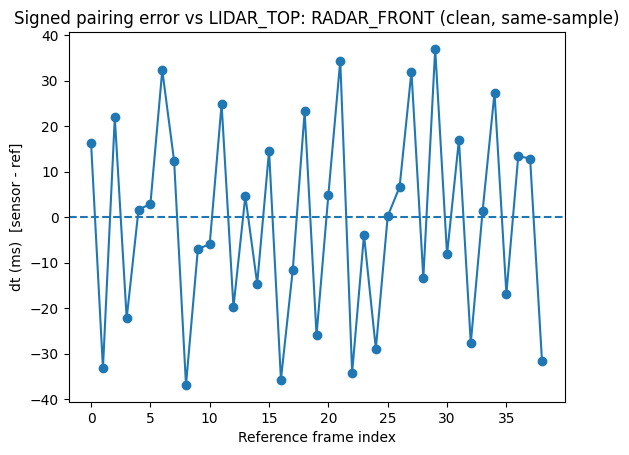

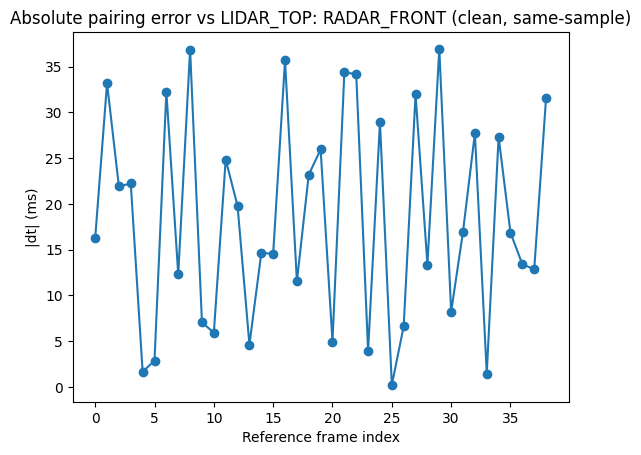

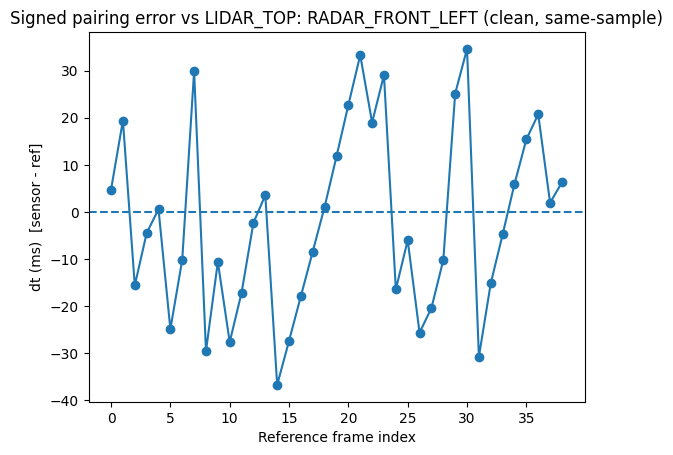

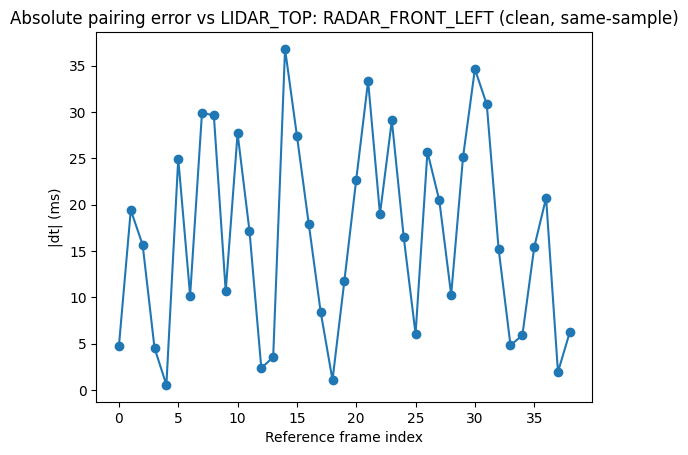

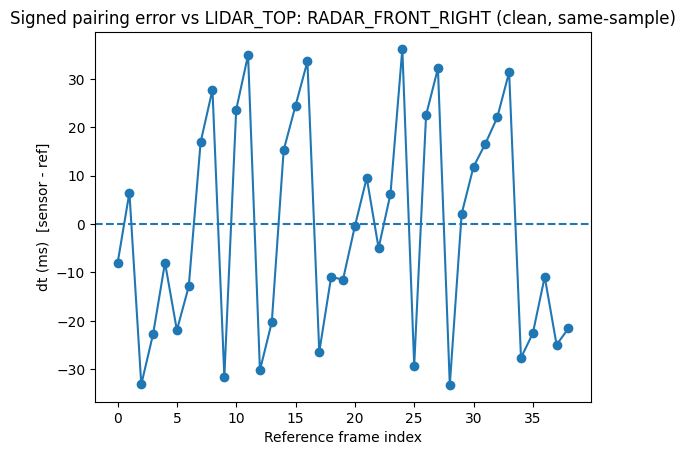

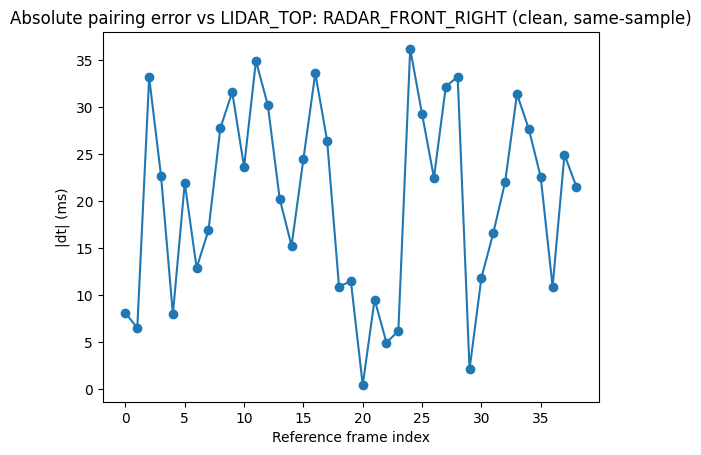

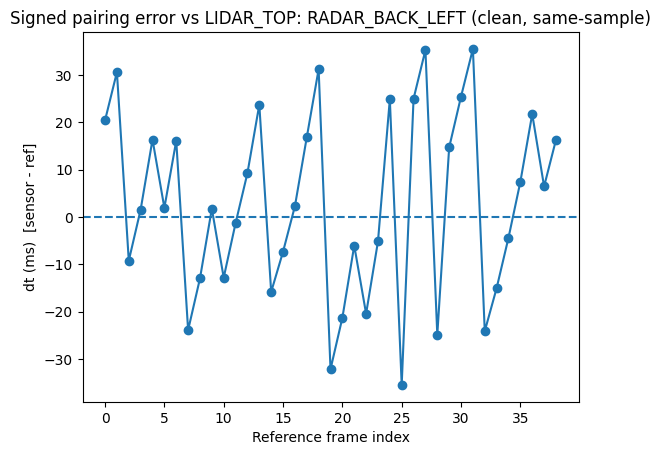

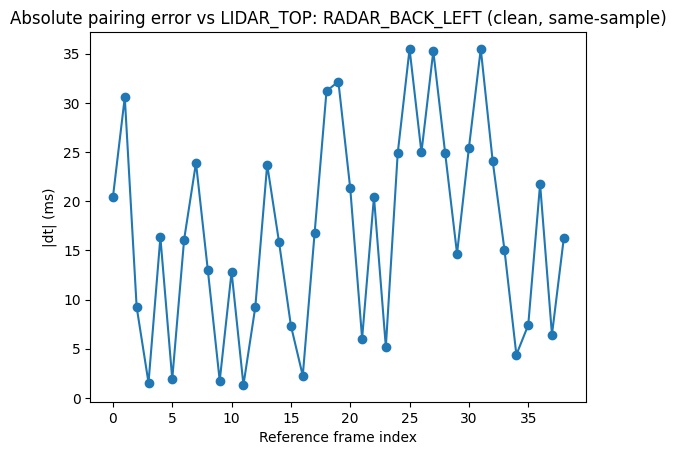

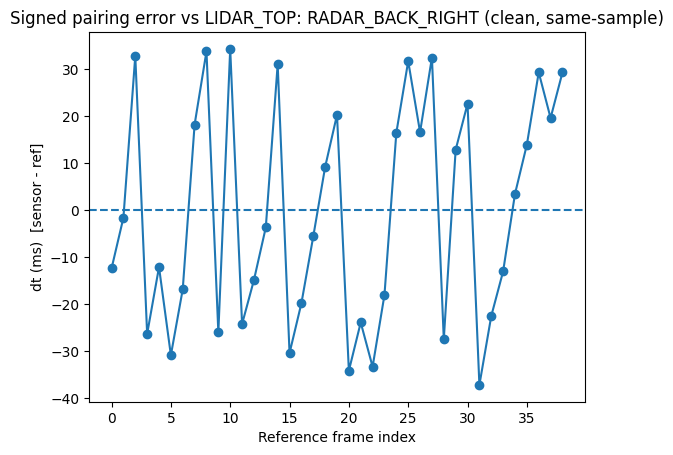

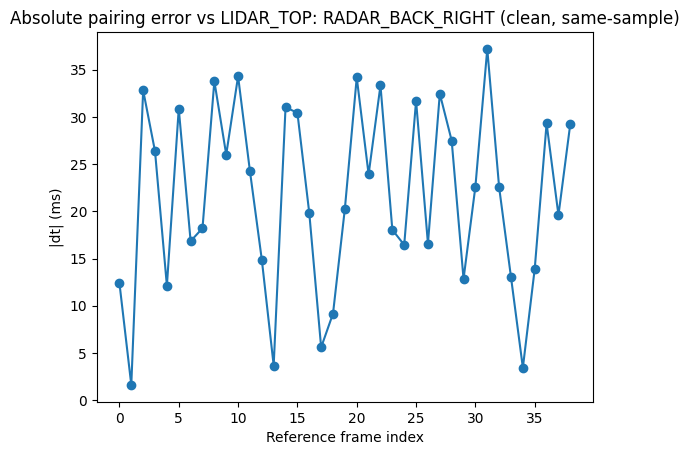

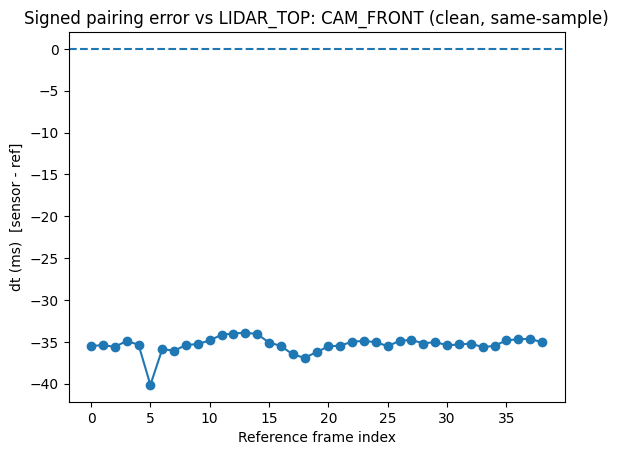

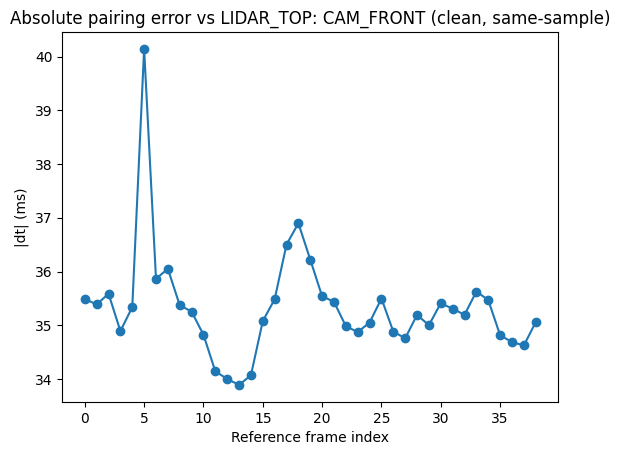

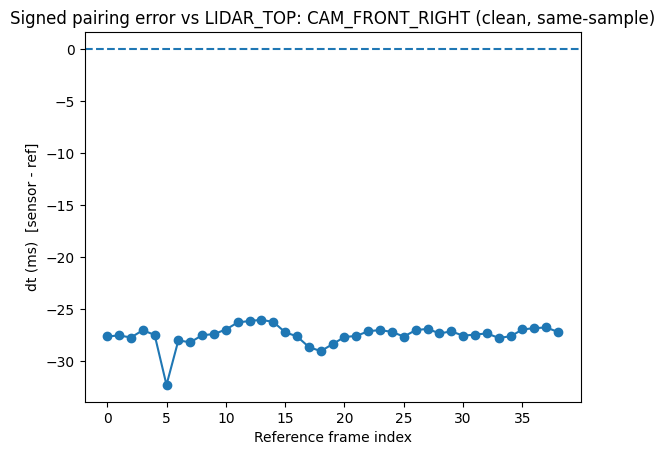

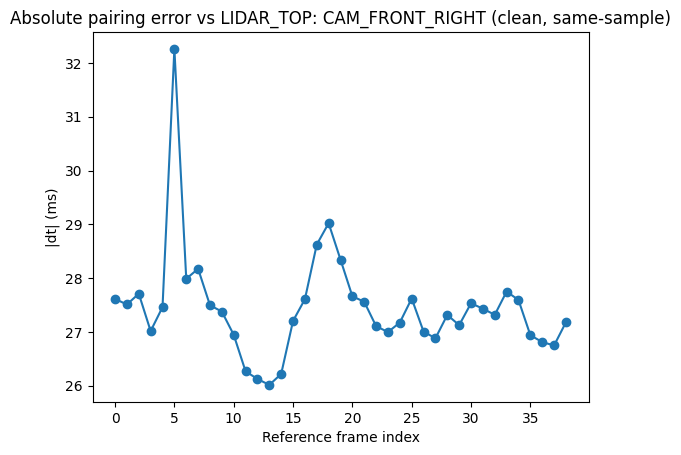

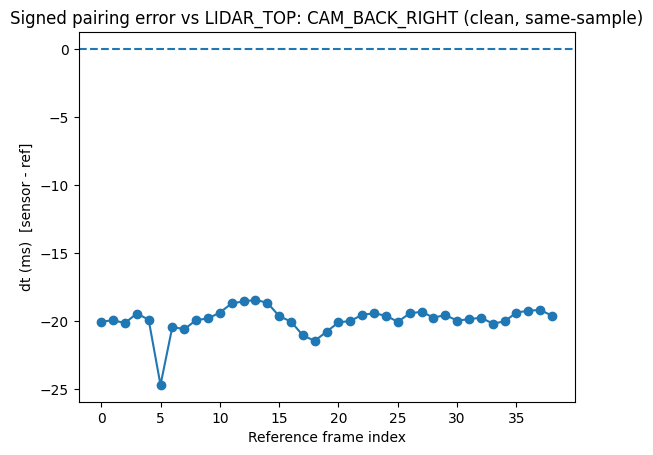

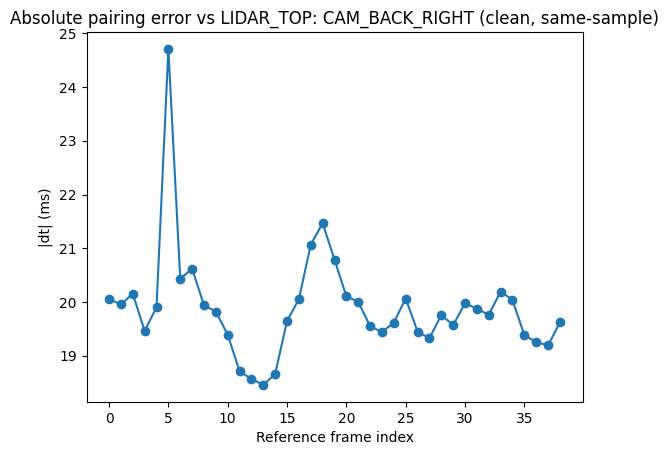

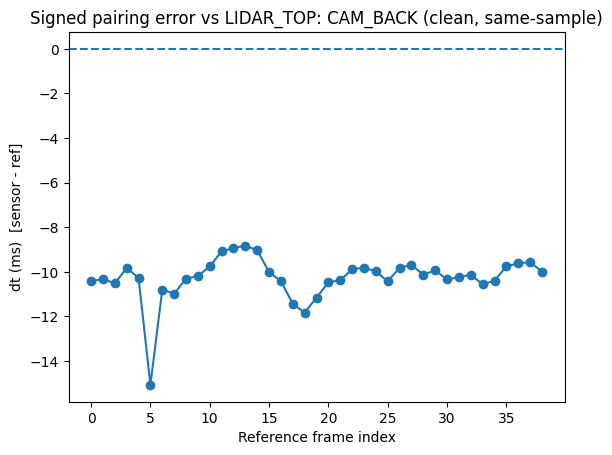

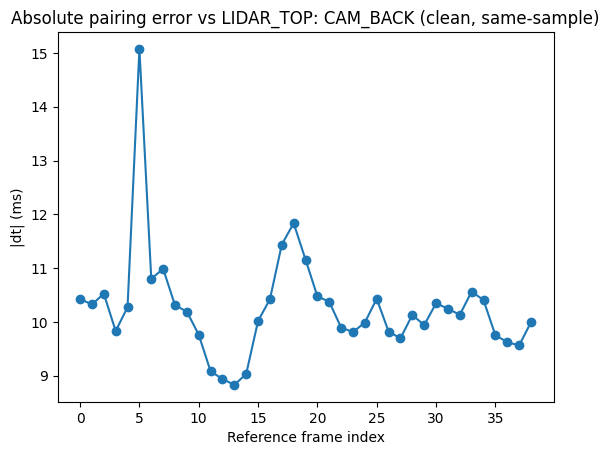

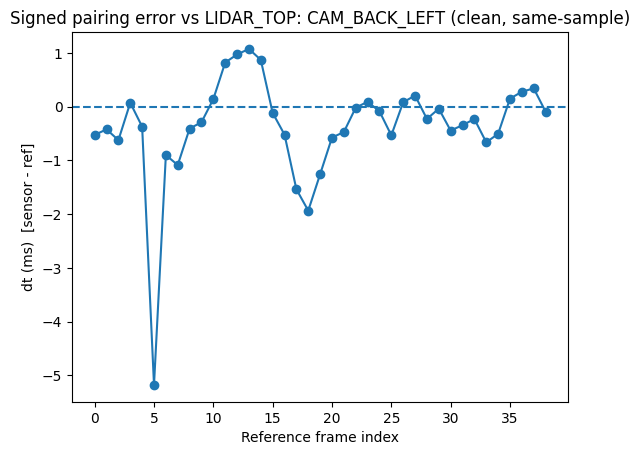

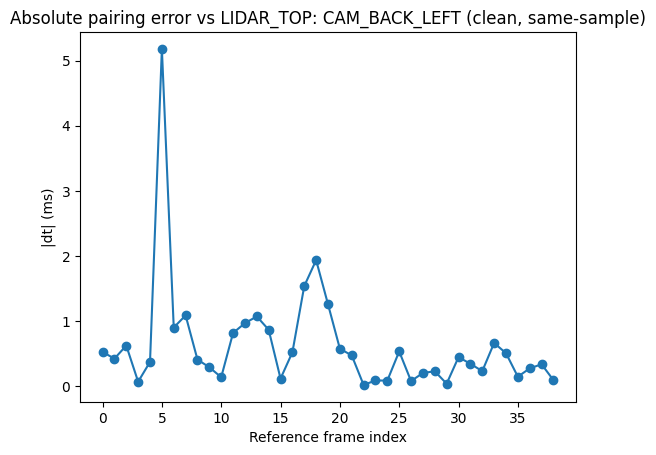

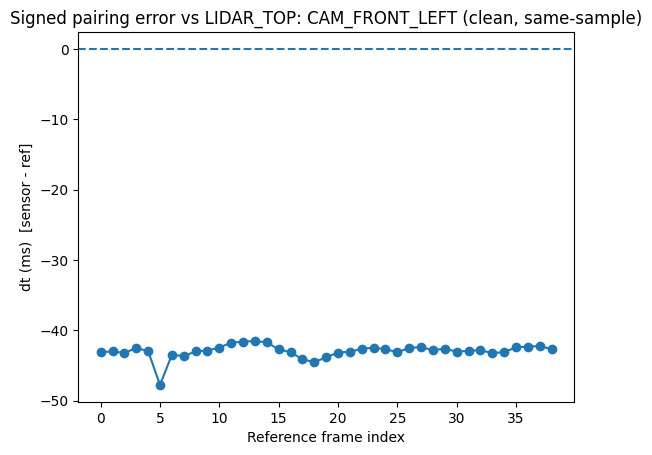

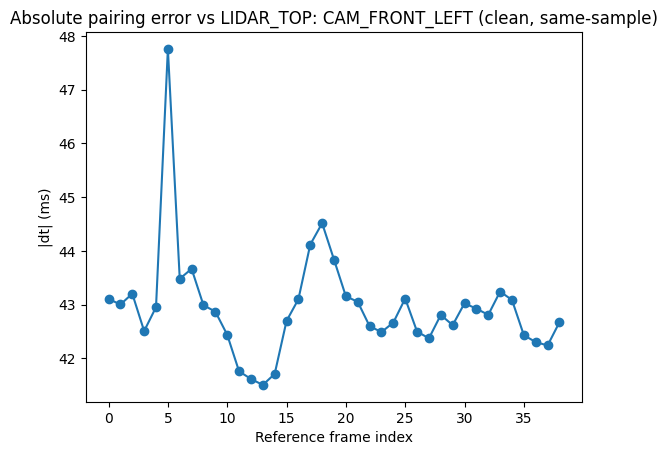

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from nuscenes.nuscenes import NuScenes

DATAROOT = "data/sets/nuscenes"   # change to yours
VERSION  = "v1.0-mini"           # or v1.0-trainval
SCENE_TOKEN = None               # optionally set a specific scene token
REF_SENSOR = "LIDAR_TOP"

nusc = NuScenes(version=VERSION, dataroot=DATAROOT, verbose=False)

def get_scene_token(nusc, scene_token=None, scene_name="scene-0061"):
    if scene_token is not None:
        return scene_token
    for s in nusc.scene:
        if s["name"] == scene_name:
            return s["token"]
    raise ValueError("Scene not found")

def iter_samples_in_scene(nusc, scene_token):
    scene = nusc.get("scene", scene_token)
    tok = scene["first_sample_token"]
    while tok:
        sample = nusc.get("sample", tok)
        yield sample
        tok = sample["next"]

def sample_data_timestamp_us(nusc, sd_token):
    sd = nusc.get("sample_data", sd_token)
    return sd["timestamp"]  # microseconds

# pick a scene
scene_token = get_scene_token(nusc, SCENE_TOKEN, scene_name="scene-0061")

# find available sensor keys from first sample (so you don't guess names)
first_sample = next(iter_samples_in_scene(nusc, scene_token))
SENSOR_KEYS = list(first_sample["data"].keys())
print("Sensors in sample['data']:", SENSOR_KEYS)

# compute pairing errors per sensor (relative to REF_SENSOR) using same-sample pairing
dt_ms_by_sensor = {s: [] for s in SENSOR_KEYS if s != REF_SENSOR}

for sample in iter_samples_in_scene(nusc, scene_token):
    if REF_SENSOR not in sample["data"]:
        continue

    t_ref = sample_data_timestamp_us(nusc, sample["data"][REF_SENSOR])

    for s in dt_ms_by_sensor.keys():
        if s not in sample["data"]:
            dt_ms_by_sensor[s].append(np.nan)
            continue
        t_s = sample_data_timestamp_us(nusc, sample["data"][s])
        dt_ms = (t_s - t_ref) / 1000.0
        dt_ms_by_sensor[s].append(dt_ms)

# plot each sensor separately: signed dt and absolute dt
for s, dts in dt_ms_by_sensor.items():
    dts = np.array(dts, dtype=float)

    plt.figure()
    plt.title(f"Signed pairing error vs {REF_SENSOR}: {s} (clean, same-sample)")
    plt.xlabel("Reference frame index")
    plt.ylabel("dt (ms)  [sensor - ref]")
    plt.axhline(0, linestyle="--")
    plt.plot(dts, marker="o")
    plt.show()

    plt.figure()
    plt.title(f"Absolute pairing error vs {REF_SENSOR}: {s} (clean, same-sample)")
    plt.xlabel("Reference frame index")
    plt.ylabel("|dt| (ms)")
    plt.plot(np.abs(dts), marker="o")
    plt.show()


In [62]:
def pairing_errors(ref_ts, sensor_ts):
    """
    Compute nearest timestamp error (ms) for each ref timestamp.
    """
    ref_ts = np.array(ref_ts, dtype=float)
    sensor_ts = np.array(sensor_ts, dtype=float)

    errors = []

    sensor_valid = sensor_ts[np.isfinite(sensor_ts)]
    if len(sensor_valid) == 0:
        return np.array([])

    for t in ref_ts:
        if not np.isfinite(t):
            continue

        idx = np.argmin(np.abs(sensor_valid - t))
        dt = (sensor_valid[idx] - t) / 1000.0  # microseconds -> ms
        errors.append(dt)

    return np.array(errors)


In [63]:
ref_ts = df_clean[REF_SENSOR].values

plt.figure(figsize=(12, 8))

for sensor in ALL_SENSORS:
    if sensor == REF_SENSOR:
        continue

    sensor_ts = df_clean[sensor].values
    errors = pairing_errors(ref_ts, sensor_ts)

    if len(errors) == 0:
        continue

    plt.hist(errors, bins=50, alpha=0.5, label=sensor)

plt.axvline(0, linestyle="--")
plt.xlabel("Pairing error dt (ms)")
plt.ylabel("Count")
plt.title("Nearest-timestamp pairing error (CLEAN dataset)")
plt.legend()
plt.show()


NameError: name 'ALL_SENSORS' is not defined

<Figure size 1200x800 with 0 Axes>

In [ ]:
for sensor in ALL_SENSORS:
    if sensor == REF_SENSOR:
        continue

    errors = pairing_errors(ref_ts, df_clean[sensor].values)

    plt.figure()
    plt.hist(errors, bins=50)
    plt.axvline(0, linestyle="--")
    plt.title(f"{sensor} vs {REF_SENSOR} (CLEAN)")
    plt.xlabel("dt (ms)")
    plt.ylabel("Count")
    plt.show()


# Create Drift (5.2)

In [69]:
# Jitter config: small for camera, larger for radar
JITTER_CFG = {s: (5.0 if s.startswith("CAM") else 12.0) for s in SENSORS}

DRIFT_CFG = {
    # Cameras (small drift)
    "CAM_FRONT": 0.10,         # 0.10 ms/frame
    "CAM_FRONT_LEFT": 0.08,
    "CAM_FRONT_RIGHT": 0.08,
    "CAM_BACK": 0.06*10,
    "CAM_BACK_LEFT": 0.06,
    "CAM_BACK_RIGHT": 0.06,

    # Radars (bigger drift)
    "RADAR_FRONT": 0.30*10,
    "RADAR_FRONT_LEFT": 0.25,
    "RADAR_FRONT_RIGHT": 0.25,
    "RADAR_BACK_LEFT": 0.20,
    "RADAR_BACK_RIGHT": 0.20,
}


def apply_drift_plus_jitter(
    df: pd.DataFrame,
    sensors: list[str],
    drift_ms_per_frame_map: dict[str, float],
    jitter_ms_map: dict[str, float] | None = None,
    bursty_radar: bool = True,
    burst_every: int = 20,
    burst_len: int = 4,
    burst_extra_jitter_ms: float = 40.0,
    seed: int = 123,
) -> pd.DataFrame:
    """
    Applies linear drift per sensor + Gaussian jitter.
    Optionally adds bursty jitter to radar sensors.
    """
    rng = np.random.default_rng(seed)
    out = df.copy(deep=True)

    N = len(out)
    idx = np.arange(N, dtype="float64")

    if jitter_ms_map is None:
        jitter_ms_map = {s: 0.0 for s in sensors}

    for s in sensors:
        ts = out[s].to_numpy(dtype="float64")
        valid = ~np.isnan(ts)

        # Drift
        drift_ms_per_frame = drift_ms_per_frame_map.get(s, 0.0)
        if drift_ms_per_frame != 0.0:
            ts[valid] = ts[valid] + (drift_ms_per_frame * idx[valid] * 1000.0)

        # Base jitter
        base_jitter_ms = jitter_ms_map.get(s, 0.0)
        if base_jitter_ms > 0.0:
            ts[valid] = ts[valid] + rng.normal(0.0, base_jitter_ms * 1000.0, size=valid.sum())

        # Bursty jitter for radars
        if bursty_radar and s.startswith("RADAR") and burst_extra_jitter_ms > 0.0:
            burst_mask = np.zeros(N, dtype=bool)
            for start in range(0, N, burst_every):
                burst_mask[start:start + burst_len] = True
            burst_mask &= valid

            ts[burst_mask] = ts[burst_mask] + rng.normal(
                0.0, burst_extra_jitter_ms * 1000.0, size=burst_mask.sum()
            )

        out[s] = ts

    return out


df_drift = apply_drift_plus_jitter(
    df_clean,
    sensors=SENSORS,
    drift_ms_per_frame_map=DRIFT_CFG,
    jitter_ms_map=JITTER_CFG,
    bursty_radar=True,
    burst_every=20,
    burst_len=4,
    burst_extra_jitter_ms=40.0,
    seed=42,
)




In [82]:
# Pick sensors you are evaluating (exclude reference)
SENSORS = ALL_SENSORS  # your existing list
REF = "LIDAR_TOP"

# Jitter config: small for camera, larger for radar
JITTER_CFG = {s: (5.0 if s.startswith("CAM") else 12.0) for s in SENSORS}

df_drift = apply_drift_plus_jitter(
    df_clean,
    sensors=SENSORS,
    drift_ms_per_frame_map=DRIFT_CFG,
    jitter_ms_map=JITTER_CFG,
    bursty_radar=True,
    burst_every=20,
    burst_len=4,
    burst_extra_jitter_ms=40.0,
    seed=42,
)


In [83]:
summary_clean, matches_clean = evaluate_pairing(df_clean, REF, SENSORS, threshold_ms=50)
summary_jitter, matches_jitter = evaluate_pairing(df_corrupt, REF, SENSORS, threshold_ms=50)
summary_drift, matches_drift = evaluate_pairing(df_drift, REF, SENSORS, threshold_ms=50)

summary_clean.to_csv("metrics_clean.csv", index=False)
summary_jitter.to_csv("metrics_jitter.csv", index=False)
summary_drift.to_csv("metrics_drift.csv", index=False)

summary_clean, summary_jitter, summary_drift


(               sensor  threshold_ms  match_rate_pct  mean_abs_dt_ms  \
 0         RADAR_FRONT            50           100.0       17.221725   
 1    RADAR_FRONT_LEFT            50           100.0       14.139475   
 2   RADAR_FRONT_RIGHT            50           100.0       19.986700   
 3     RADAR_BACK_LEFT            50           100.0       18.700800   
 4    RADAR_BACK_RIGHT            50           100.0       19.342875   
 5           LIDAR_TOP            50           100.0        0.000000   
 6           CAM_FRONT            50           100.0       35.272100   
 7     CAM_FRONT_RIGHT            50           100.0       27.392850   
 8      CAM_BACK_RIGHT            50           100.0       19.830150   
 9            CAM_BACK            50           100.0       10.153900   
 10      CAM_BACK_LEFT            50           100.0        0.528300   
 11     CAM_FRONT_LEFT            50           100.0       42.888325   
 
     p95_abs_dt_ms  max_abs_dt_ms  
 0        30.60075        

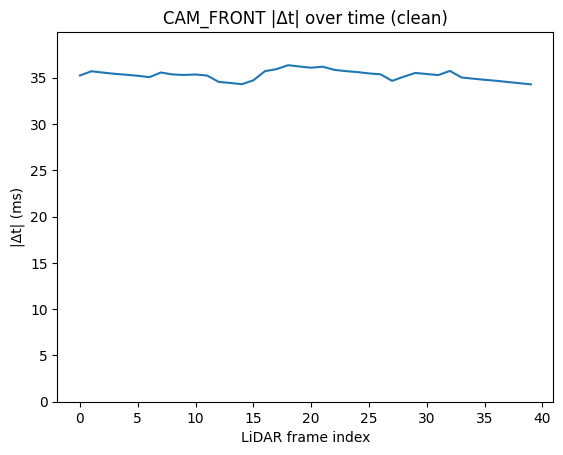

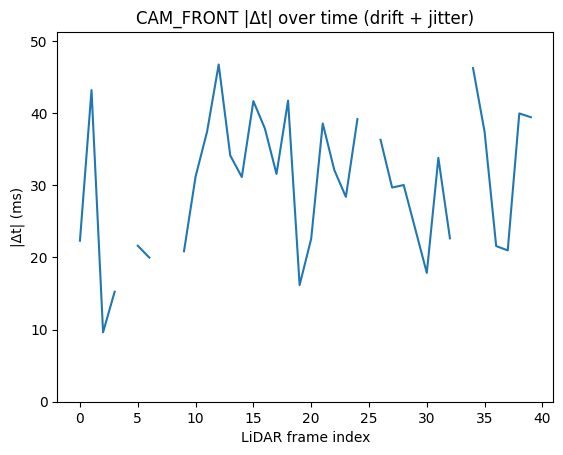

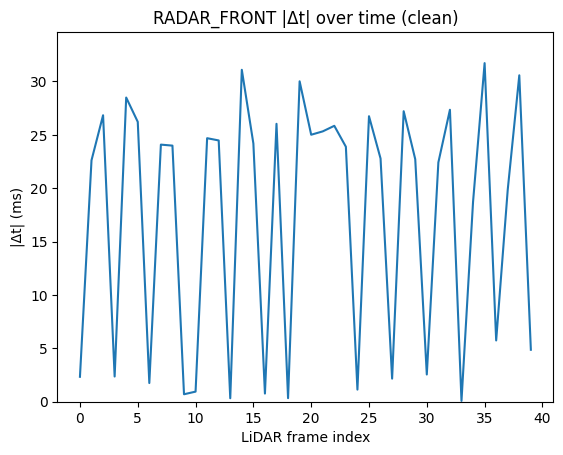

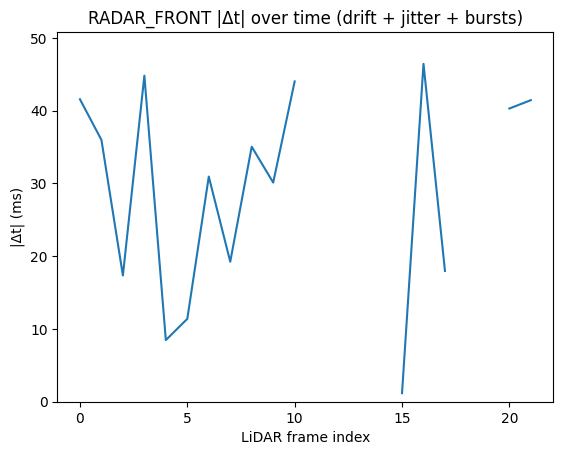

In [ ]:
def plot_error_over_time(matches_dict, sensor: str, title: str):
    y = matches_dict[sensor]["dt_ms_abs"].to_numpy()
    plt.figure()
    plt.plot(y)
    plt.title(title)
    plt.xlabel("LiDAR frame index")
    plt.ylabel("|Δt| (ms)")
    plt.ylim(0, np.nanpercentile(y, 99) * 1.1)
    plt.show()

plot_error_over_time(matches_clean, "CAM_FRONT", "CAM_FRONT |Δt| over time (clean)")
plot_error_over_time(matches_drift, "CAM_FRONT", "CAM_FRONT |Δt| over time (drift + jitter)")

plot_error_over_time(matches_clean, "RADAR_FRONT", "RADAR_FRONT |Δt| over time (clean)")
plot_error_over_time(matches_drift, "RADAR_FRONT", "RADAR_FRONT |Δt| over time (drift + jitter + bursts)")



In [86]:
diff = df_drift["CAM_FRONT"] - df_clean["CAM_FRONT"]
diff.describe()

count       40.000000
mean      2212.862500
std       5365.896929
min     -11533.250000
25%       -184.625000
50%       2055.375000
75%       5549.562500
max      11919.750000
Name: CAM_FRONT, dtype: float64

Text(0.5, 0, 'Frame index')

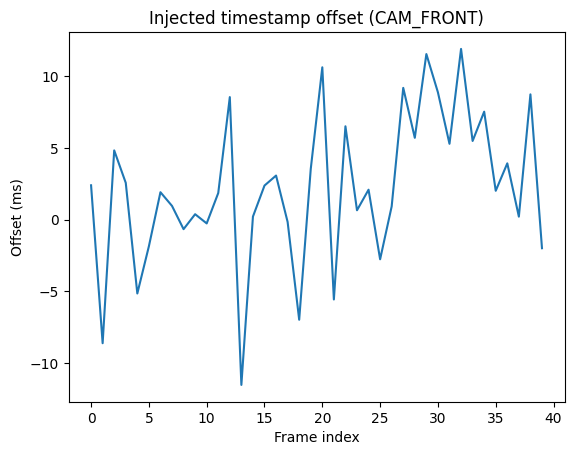

In [87]:
plt.plot(diff.to_numpy() / 1000.0)
plt.title("Injected timestamp offset (CAM_FRONT)")
plt.ylabel("Offset (ms)")
plt.xlabel("Frame index")

In [88]:
print("Using df id:", id(df_drift))
print("Clean df id:", id(df_clean))

Using df id: 1473875214160
Clean df id: 1473764275088


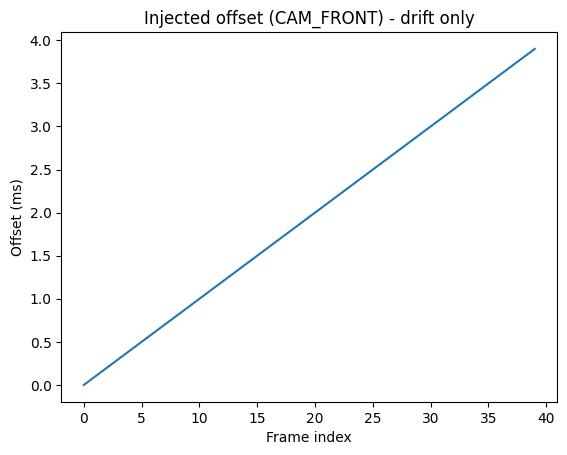

In [89]:
df_drift_only = apply_drift_plus_jitter(
    df_clean,
    sensors=SENSORS,
    drift_ms_per_frame_map=DRIFT_CFG,
    jitter_ms_map={s: 0.0 for s in SENSORS},
    bursty_radar=False,
    seed=42,
)

diff_drift_only = (df_drift_only["CAM_FRONT"] - df_clean["CAM_FRONT"]) / 1000.0
plt.figure()
plt.plot(diff_drift_only.to_numpy())
plt.title("Injected offset (CAM_FRONT) - drift only")
plt.ylabel("Offset (ms)")
plt.xlabel("Frame index")
plt.show()

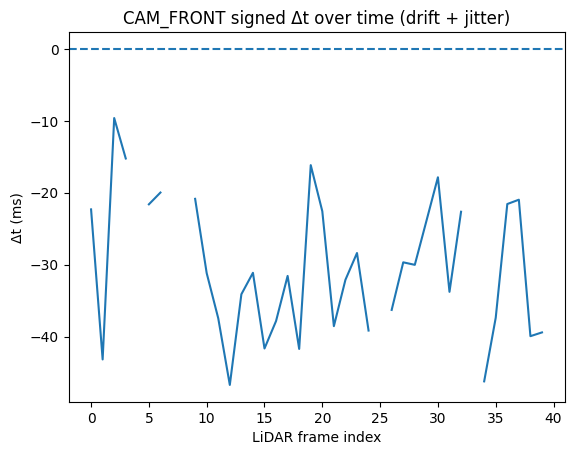

In [90]:
plt.figure()
plt.plot(matches_drift["CAM_FRONT"]["dt_ms_signed"].to_numpy())
plt.title("CAM_FRONT signed Δt over time (drift + jitter)")
plt.xlabel("LiDAR frame index")
plt.ylabel("Δt (ms)")
plt.axhline(0, linestyle="--")
plt.show()

# Drift-aware adaptive offset (5.2)

In [45]:
def adaptive_offset_match(
    df: pd.DataFrame,
    ref_sensor: str,
    tgt_sensor: str,
    threshold_ms: float = 50.0,
    search_window_ms: float = 200.0,
    beta: float = 0.1,
    init_from_first_n: int = 5,
) -> pd.DataFrame:
    """
    Adaptive offset estimator + nearest matching.
    Returns per-ref-frame:
      matched, dt_ms_signed, dt_ms_abs, tgt_ts_us, offset_hat_ms
    """
    ref = df[ref_sensor].to_numpy(dtype="float64")
    tgt = df[tgt_sensor].to_numpy(dtype="float64")

    out = pd.DataFrame({
        "matched": np.zeros(len(ref), dtype=bool),
        "dt_ms_signed": np.full(len(ref), np.nan, dtype="float64"),
        "dt_ms_abs": np.full(len(ref), np.nan, dtype="float64"),
        "tgt_ts_us": np.full(len(ref), np.nan, dtype="float64"),
        "offset_hat_ms": np.full(len(ref), np.nan, dtype="float64"),
    })

    tgt_valid = tgt[~np.isnan(tgt)]
    if tgt_valid.size == 0:
        return out
    tgt_valid.sort()

    thr_us = threshold_ms * 1000.0
    win_us = search_window_ms * 1000.0

    # Initialise offset_hat using first N valid frames (median residual)
    residuals = []
    for i in range(len(ref)):
        if np.isnan(ref[i]):
            continue
        j = np.searchsorted(tgt_valid, ref[i])
        cand = []
        if j > 0: cand.append(tgt_valid[j-1])
        if j < tgt_valid.size: cand.append(tgt_valid[j])
        best = min(cand, key=lambda x: abs(x - ref[i]))
        residuals.append((best - ref[i]) / 1000.0)  # ms
        if len(residuals) >= init_from_first_n:
            break
    offset_hat = float(np.median(residuals)) if residuals else 0.0

    for i, t_ref in enumerate(ref):
        if np.isnan(t_ref):
            continue

        # Predict where the target should be
        t_pred = t_ref + offset_hat * 1000.0

        # Search nearest in target space around t_pred
        j = np.searchsorted(tgt_valid, t_pred)
        candidates = []
        if j > 0: candidates.append(tgt_valid[j-1])
        if j < tgt_valid.size: candidates.append(tgt_valid[j])

        # If we somehow have no candidates (shouldn't happen), skip
        if not candidates:
            out.loc[i, "offset_hat_ms"] = offset_hat
            continue

        best = min(candidates, key=lambda x: abs(x - t_pred))

        # Optional: require candidate within search window
        if abs(best - t_pred) > win_us:
            out.loc[i, "offset_hat_ms"] = offset_hat
            continue

        # Residual to true ref time (signed)
        r_ms = (best - t_ref) / 1000.0

        # Matched if within threshold relative to ref time
        if abs(best - t_ref) <= thr_us:
            out.loc[i, "matched"] = True
            out.loc[i, "dt_ms_signed"] = r_ms
            out.loc[i, "dt_ms_abs"] = abs(r_ms)
            out.loc[i, "tgt_ts_us"] = best

            # Update offset estimate (EMA)
            offset_hat = (1.0 - beta) * offset_hat + beta * r_ms

        out.loc[i, "offset_hat_ms"] = offset_hat

    return out


In [70]:
# Settings

m_cam_base = match_nearest_timestamps(
    df_drift["LIDAR_TOP"].to_numpy(),
    df_drift["CAM_FRONT"].to_numpy(),
    threshold_ms=50
)

m_cam_adapt = adaptive_offset_match(df_drift, "LIDAR_TOP", "CAM_FRONT",
                                    threshold_ms=50, search_window_ms=200,
                                    beta=0.15)

m_rad_base = match_nearest_timestamps(
    df_drift["LIDAR_TOP"].to_numpy(),
    df_drift["RADAR_FRONT"].to_numpy(),
    threshold_ms=50
)

m_rad_adapt = adaptive_offset_match(df_drift, "LIDAR_TOP", "RADAR_FRONT",
                                    threshold_ms=50, search_window_ms=300,
                                    beta=0.10)


In [71]:
def metrics_from_match(df_match: pd.DataFrame) -> dict:
    matched = df_match["matched"].to_numpy()
    abs_dt = df_match["dt_ms_abs"].to_numpy()
    return {
        "match_rate_pct": matched.mean() * 100.0,
        "mean_abs_dt_ms": np.nanmean(abs_dt),
        "p95_abs_dt_ms": np.nanpercentile(abs_dt, 95),
        "max_abs_dt_ms": np.nanmax(abs_dt),
    }

print("CAM base:", metrics_from_match(m_cam_base))
print("CAM adapt:", metrics_from_match(m_cam_adapt))
print("RAD base:", metrics_from_match(m_rad_base))
print("RAD adapt:", metrics_from_match(m_rad_adapt))


CAM base: {'match_rate_pct': np.float64(87.5), 'mean_abs_dt_ms': np.float64(30.370500000000007), 'p95_abs_dt_ms': np.float64(44.10099999999999), 'max_abs_dt_ms': np.float64(46.72975)}
CAM adapt: {'match_rate_pct': np.float64(87.5), 'mean_abs_dt_ms': np.float64(30.370500000000007), 'p95_abs_dt_ms': np.float64(44.10099999999999), 'max_abs_dt_ms': np.float64(46.72975)}
RAD base: {'match_rate_pct': np.float64(42.5), 'mean_abs_dt_ms': np.float64(27.92705882352941), 'p95_abs_dt_ms': np.float64(45.14295), 'max_abs_dt_ms': np.float64(46.44375)}
RAD adapt: {'match_rate_pct': np.float64(42.5), 'mean_abs_dt_ms': np.float64(27.92705882352941), 'p95_abs_dt_ms': np.float64(45.14295), 'max_abs_dt_ms': np.float64(46.44375)}


In [72]:
def adaptive_index_match(
    df,
    ref_sensor,
    tgt_sensor,
    threshold_ms=50,
    max_step=1
):
    """
    Continuity-constrained nearest matching.
    Forces index continuity to resist drift snapping.
    """

    ref = df[ref_sensor].to_numpy(dtype=float)
    tgt = df[tgt_sensor].to_numpy(dtype=float)

    tgt_valid = tgt[~np.isnan(tgt)]
    tgt_valid.sort()

    out = pd.DataFrame({
        "matched": np.zeros(len(ref), dtype=bool),
        "dt_ms_signed": np.full(len(ref), np.nan),
        "dt_ms_abs": np.full(len(ref), np.nan),
    })

    thr_us = threshold_ms * 1000

    # Initial match: global nearest
    j = np.searchsorted(tgt_valid, ref[0])
    candidates = []
    if j > 0: candidates.append(j-1)
    if j < len(tgt_valid): candidates.append(j)

    prev_idx = min(candidates, key=lambda k: abs(tgt_valid[k] - ref[0]))

    for i, t in enumerate(ref):

        # restrict search around previous index
        lo = max(0, prev_idx - max_step)
        hi = min(len(tgt_valid)-1, prev_idx + max_step)

        best_idx = min(
            range(lo, hi+1),
            key=lambda k: abs(tgt_valid[k] - t)
        )

        dt_us = tgt_valid[best_idx] - t

        if abs(dt_us) <= thr_us:
            out.loc[i, "matched"] = True
            out.loc[i, "dt_ms_signed"] = dt_us / 1000
            out.loc[i, "dt_ms_abs"] = abs(dt_us) / 1000

        prev_idx = best_idx

    return out

In [73]:
m_cam_adapt = adaptive_index_match(df_drift, "LIDAR_TOP", "CAM_FRONT")
m_rad_adapt = adaptive_index_match(df_drift, "LIDAR_TOP", "RADAR_FRONT")


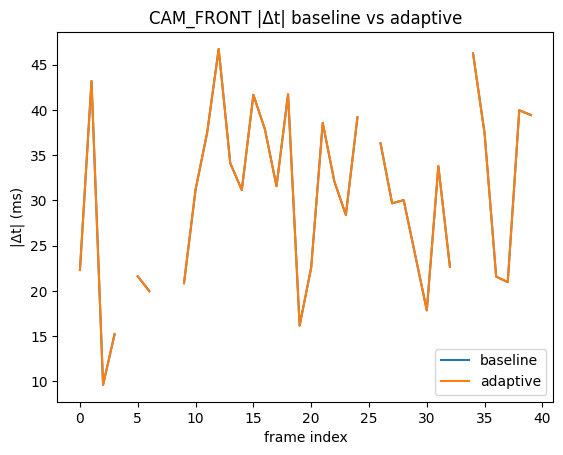

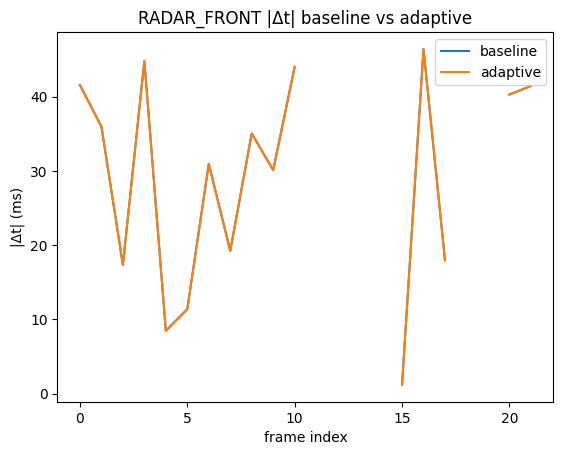

In [ ]:
def plot_compare(base, adapt, title):
    plt.figure()
    plt.plot(base["dt_ms_abs"].to_numpy(), label="baseline")
    plt.plot(adapt["dt_ms_abs"].to_numpy(), label="adaptive")
    plt.title(title)
    plt.xlabel("frame index")
    plt.ylabel("|Δt| (ms)")
    plt.legend()
    plt.show()

plot_compare(m_cam_base, m_cam_adapt, "CAM_FRONT |Δt| baseline vs adaptive")
plot_compare(m_rad_base, m_rad_adapt, "RADAR_FRONT |Δt| baseline vs adaptive")


In [75]:
def match_nearest_with_index(ref_ts_us, tgt_ts_us, threshold_ms=50.0):
    ref = ref_ts_us.astype("float64")
    tgt = tgt_ts_us.astype("float64")

    tgt_valid = tgt[~np.isnan(tgt)]
    if tgt_valid.size == 0:
        return pd.DataFrame({
            "matched": np.zeros(len(ref), dtype=bool),
            "dt_ms_abs": np.full(len(ref), np.nan),
            "tgt_ts_us": np.full(len(ref), np.nan),
            "tgt_idx": np.full(len(ref), -1, dtype=int),
        })

    tgt_valid.sort()
    thr_us = threshold_ms * 1000.0

    out = pd.DataFrame({
        "matched": np.zeros(len(ref), dtype=bool),
        "dt_ms_abs": np.full(len(ref), np.nan),
        "tgt_ts_us": np.full(len(ref), np.nan),
        "tgt_idx": np.full(len(ref), -1, dtype=int),
    })

    for i, t in enumerate(ref):
        if np.isnan(t):
            continue
        j = np.searchsorted(tgt_valid, t)
        cand = []
        if j > 0: cand.append(j - 1)
        if j < len(tgt_valid): cand.append(j)
        best_idx = min(cand, key=lambda k: abs(tgt_valid[k] - t))
        best = tgt_valid[best_idx]
        if abs(best - t) <= thr_us:
            out.loc[i, "matched"] = True
            out.loc[i, "dt_ms_abs"] = abs(best - t) / 1000.0
            out.loc[i, "tgt_ts_us"] = best
            out.loc[i, "tgt_idx"] = best_idx

    return out

In [76]:
base = match_nearest_with_index(
    df_drift["LIDAR_TOP"].to_numpy(),
    df_drift["CAM_FRONT"].to_numpy(),
    threshold_ms=50
)

In [77]:
def adaptive_index_match_with_index(df, ref_sensor, tgt_sensor, threshold_ms=50, max_step=1):
    ref = df[ref_sensor].to_numpy(dtype=float)
    tgt = df[tgt_sensor].to_numpy(dtype=float)

    tgt_valid = tgt[~np.isnan(tgt)]
    tgt_valid.sort()

    out = pd.DataFrame({
        "matched": np.zeros(len(ref), dtype=bool),
        "dt_ms_abs": np.full(len(ref), np.nan),
        "tgt_idx": np.full(len(ref), -1, dtype=int),
    })

    thr_us = threshold_ms * 1000.0

    # find first valid ref
    first_i = next((i for i, t in enumerate(ref) if not np.isnan(t)), None)
    if first_i is None or len(tgt_valid) == 0:
        return out

    j0 = np.searchsorted(tgt_valid, ref[first_i])
    cand0 = []
    if j0 > 0: cand0.append(j0 - 1)
    if j0 < len(tgt_valid): cand0.append(j0)
    prev_idx = min(cand0, key=lambda k: abs(tgt_valid[k] - ref[first_i]))

    for i, t in enumerate(ref):
        if np.isnan(t):
            continue

        lo = max(0, prev_idx - max_step)
        hi = min(len(tgt_valid) - 1, prev_idx + max_step)

        best_idx = min(range(lo, hi + 1), key=lambda k: abs(tgt_valid[k] - t))
        best = tgt_valid[best_idx]
        dt_us = best - t

        if abs(dt_us) <= thr_us:
            out.loc[i, "matched"] = True
            out.loc[i, "dt_ms_abs"] = abs(dt_us) / 1000.0
            out.loc[i, "tgt_idx"] = best_idx

        prev_idx = best_idx

    return out


In [78]:
adapt = adaptive_index_match_with_index(df_drift, "LIDAR_TOP", "CAM_FRONT", threshold_ms=50, max_step=1)


In [79]:
same_idx = np.all(base["tgt_idx"].to_numpy() == adapt["tgt_idx"].to_numpy())
diff_count = np.sum(base["tgt_idx"].to_numpy() != adapt["tgt_idx"].to_numpy())
print("Same chosen index everywhere?", same_idx)
print("Number of frames with different chosen index:", diff_count)

# Also compare dt arrays:
print("Max |Δt| difference:", np.nanmax(np.abs(base["dt_ms_abs"] - adapt["dt_ms_abs"])))


Same chosen index everywhere? True
Number of frames with different chosen index: 0
Max |Δt| difference: 0.0


In [80]:
thresholds = [5, 10, 20, 50]
for T in thresholds:
    summary, _ = evaluate_pairing(df_drift, "LIDAR_TOP", ["CAM_FRONT", "RADAR_FRONT"], threshold_ms=T)
    print("\nThreshold:", T, "ms")
    print(summary)


Threshold: 5 ms
        sensor  threshold_ms  match_rate_pct  mean_abs_dt_ms  p95_abs_dt_ms  \
0    CAM_FRONT             5             0.0             NaN            NaN   
1  RADAR_FRONT             5             2.5          1.1765         1.1765   

   max_abs_dt_ms  
0            NaN  
1         1.1765  

Threshold: 10 ms
        sensor  threshold_ms  match_rate_pct  mean_abs_dt_ms  p95_abs_dt_ms  \
0    CAM_FRONT            10             2.5        9.616000        9.61600   
1  RADAR_FRONT            10             7.5        6.024333        8.46685   

   max_abs_dt_ms  
0         9.6160  
1         8.4715  

Threshold: 20 ms
        sensor  threshold_ms  match_rate_pct  mean_abs_dt_ms  p95_abs_dt_ms  \
0    CAM_FRONT            20            12.5       15.768800      19.549050   
1  RADAR_FRONT            20            17.5       12.005536      18.863675   

   max_abs_dt_ms  
0         19.974  
1         19.244  

Threshold: 50 ms
        sensor  threshold_ms  match_rate_pct

C:\Users\ntop2\AppData\Local\Temp\ipykernel_25472\691932806.py:27: RuntimeWarning: Mean of empty slice
  mean_abs = np.nanmean(abs_dt)  # nanmean ok because unmatched are NaN
C:\Users\ntop2\AppData\Local\Temp\ipykernel_25472\691932806.py:28: RuntimeWarning: All-NaN slice encountered
  max_abs = np.nanmax(abs_dt)
c:\Users\ntop2\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1396: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


In [81]:
def collect_prev_sweep_timestamps(nusc, sample_data_token, max_sweeps=10):
    ts = []
    tok = sample_data_token
    for _ in range(max_sweeps):
        sd = nusc.get("sample_data", tok)
        ts.append(sd["timestamp"])
        tok = sd["prev"]
        if tok == "":
            break
    return ts  # in microseconds

# Radar-Sweeps (?)

In [91]:
def build_radar_sweep_pool(
    nusc,
    scene_token: str,
    ref_sensor: str = "LIDAR_TOP",
    radar_channel: str = "RADAR_FRONT",
    max_sweeps: int = 50,
    window_s: float = 1.5,
):
    """
    For each sample in a scene:
      - get LiDAR keyframe timestamp (ref)
      - collect up to max_sweeps radar timestamps by following sample_data['prev']
      - keep only sweeps within [t_ref - window_s, t_ref + window_s] (mostly prev)
    Returns a dataframe with one row per LiDAR frame:
      - frame_idx
      - t_ref_us
      - radar_ts_us_list  (list of timestamps)
    """
    scene = nusc.get("scene", scene_token)
    sample_token = scene["first_sample_token"]

    rows = []
    frame_idx = 0
    win_us = window_s * 1e6

    while sample_token:
        sample = nusc.get("sample", sample_token)

        # Reference timestamp from LiDAR keyframe
        ref_sd_token = sample["data"][ref_sensor]
        ref_sd = nusc.get("sample_data", ref_sd_token)
        t_ref = float(ref_sd["timestamp"])

        # Radar sweep pool from prev chain
        radar_sd_token = sample["data"][radar_channel]
        ts_list = []
        tok = radar_sd_token

        for _ in range(max_sweeps):
            sd = nusc.get("sample_data", tok)
            t = float(sd["timestamp"])
            if abs(t - t_ref) <= win_us:
                ts_list.append(t)
            tok = sd["prev"]
            if tok == "":
                break

        rows.append({
            "frame_idx": frame_idx,
            "t_ref_us": t_ref,
            "radar_ts_us_list": ts_list,  # list of floats
        })

        frame_idx += 1
        sample_token = sample["next"]

    return pd.DataFrame(rows)


In [92]:
scene_token = nusc.scene[0]["token"]
df_pool = build_radar_sweep_pool(nusc, scene_token, max_sweeps=10, window_s=0.5)
df_pool.head()


,frame_idx,t_ref_us,radar_ts_us_list
0,0,1.532403e+15,[1532402927664178.0]
1,1,1.532403e+15,"[1532402928114656.0, 1532402928039752.0, 15324..."
2,2,1.532403e+15,"[1532402928719956.0, 1532402928644763.0, 15324..."
3,3,1.532403e+15,"[1532402929175111.0, 1532402929100097.0, 15324..."
4,4,1.532403e+15,"[1532402929699442.0, 1532402929629675.0, 15324..."


In [93]:
def corrupt_radar_pool(
    df_pool: pd.DataFrame,
    drift_ms_per_frame: float = 2.0,
    jitter_ms: float = 10.0,
    drop_prob: float = 0.1,
    seed: int = 0,
):
    """
    Applies corruption to each radar timestamp in the pool.
    Drift is applied per LiDAR frame index (same for all sweeps in that frame).
    Jitter is applied per sweep timestamp.
    Dropout randomly removes sweeps.
    """
    rng = np.random.default_rng(seed)
    out = df_pool.copy(deep=True)

    for i in range(len(out)):
        frame_idx = int(out.loc[i, "frame_idx"])
        ts_list = list(out.loc[i, "radar_ts_us_list"])

        if len(ts_list) == 0:
            continue

        # Drift (microseconds) applied per LiDAR frame
        drift_us = drift_ms_per_frame * frame_idx * 1000.0

        new_list = []
        for t in ts_list:
            if rng.random() < drop_prob:
                continue
            t2 = t + drift_us
            t2 = t2 + rng.normal(0.0, jitter_ms * 1000.0)
            new_list.append(float(t2))

        out.at[i, "radar_ts_us_list"] = new_list

    return out


In [94]:
def match_pool_nearest(df_pool: pd.DataFrame, threshold_ms: float = 50.0) -> pd.DataFrame:
    """
    Baseline: for each frame, pick the sweep timestamp closest to t_ref.
    Returns per frame: matched, dt_ms_signed, dt_ms_abs, chosen_sweep_idx
    chosen_sweep_idx is the index within the pool list (0..len-1) for the chosen sweep.
    """
    thr_us = threshold_ms * 1000.0

    matched = []
    dt_signed = []
    dt_abs = []
    chosen_idx = []

    for _, row in df_pool.iterrows():
        t_ref = float(row["t_ref_us"])
        ts_list = row["radar_ts_us_list"]

        if not ts_list:
            matched.append(False); dt_signed.append(np.nan); dt_abs.append(np.nan); chosen_idx.append(-1)
            continue

        # choose nearest
        diffs = [t - t_ref for t in ts_list]
        k = int(np.argmin([abs(d) for d in diffs]))
        dt_us = diffs[k]

        if abs(dt_us) <= thr_us:
            matched.append(True)
            dt_signed.append(dt_us / 1000.0)
            dt_abs.append(abs(dt_us) / 1000.0)
            chosen_idx.append(k)
        else:
            matched.append(False); dt_signed.append(np.nan); dt_abs.append(np.nan); chosen_idx.append(-1)

    return pd.DataFrame({
        "matched": matched,
        "dt_ms_signed": dt_signed,
        "dt_ms_abs": dt_abs,
        "chosen_sweep_idx": chosen_idx,
    })


def match_pool_continuity(df_pool: pd.DataFrame, threshold_ms: float = 50.0, max_jump: int = 1) -> pd.DataFrame:
    """
    Continuity-constrained matching:
      - first matched frame uses nearest
      - afterwards, only consider sweep indices within +/- max_jump of previous chosen index
    This prevents jumping between distant sweeps when corruption makes timestamps ambiguous.
    """
    thr_us = threshold_ms * 1000.0

    matched = []
    dt_signed = []
    dt_abs = []
    chosen_idx = []

    prev_k = None

    for _, row in df_pool.iterrows():
        t_ref = float(row["t_ref_us"])
        ts_list = row["radar_ts_us_list"]

        if not ts_list:
            matched.append(False); dt_signed.append(np.nan); dt_abs.append(np.nan); chosen_idx.append(-1)
            continue

        diffs = [t - t_ref for t in ts_list]

        # candidate indices
        if prev_k is None or prev_k < 0:
            cand = list(range(len(ts_list)))
        else:
            lo = max(0, prev_k - max_jump)
            hi = min(len(ts_list) - 1, prev_k + max_jump)
            cand = list(range(lo, hi + 1))

        # choose best within candidates
        k = int(min(cand, key=lambda kk: abs(diffs[kk])))
        dt_us = diffs[k]

        if abs(dt_us) <= thr_us:
            matched.append(True)
            dt_signed.append(dt_us / 1000.0)
            dt_abs.append(abs(dt_us) / 1000.0)
            chosen_idx.append(k)
            prev_k = k
        else:
            matched.append(False); dt_signed.append(np.nan); dt_abs.append(np.nan); chosen_idx.append(-1)
            # keep prev_k unchanged or reset; reset is safer:
            prev_k = None

    return pd.DataFrame({
        "matched": matched,
        "dt_ms_signed": dt_signed,
        "dt_ms_abs": dt_abs,
        "chosen_sweep_idx": chosen_idx,
    })


In [95]:
def metrics_from_match_df(m: pd.DataFrame) -> dict:
    matched = m["matched"].to_numpy()
    abs_dt = m["dt_ms_abs"].to_numpy()
    return {
        "match_rate_pct": float(np.mean(matched) * 100.0),
        "mean_abs_dt_ms": float(np.nanmean(abs_dt)),
        "p95_abs_dt_ms": float(np.nanpercentile(abs_dt, 95)),
        "max_abs_dt_ms": float(np.nanmax(abs_dt)),
    }

def plot_abs_dt(title, m_base, m_cont):
    plt.figure()
    plt.plot(m_base["dt_ms_abs"].to_numpy(), label="baseline")
    plt.plot(m_cont["dt_ms_abs"].to_numpy(), label="continuity")
    plt.title(title)
    plt.xlabel("LiDAR frame index")
    plt.ylabel("|Δt| (ms)")
    plt.legend()
    plt.show()

def plot_chosen_idx(title, m_base, m_cont):
    plt.figure()
    plt.plot(m_base["chosen_sweep_idx"].to_numpy(), label="baseline")
    plt.plot(m_cont["chosen_sweep_idx"].to_numpy(), label="continuity")
    plt.title(title)
    plt.xlabel("LiDAR frame index")
    plt.ylabel("Chosen sweep index in pool")
    plt.legend()
    plt.show()


Baseline metrics: {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 18.670429487179486, 'p95_abs_dt_ms': 40.32282500000001, 'max_abs_dt_ms': 43.89625}
Continuity metrics: {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 18.670429487179486, 'p95_abs_dt_ms': 40.32282500000001, 'max_abs_dt_ms': 43.89625}


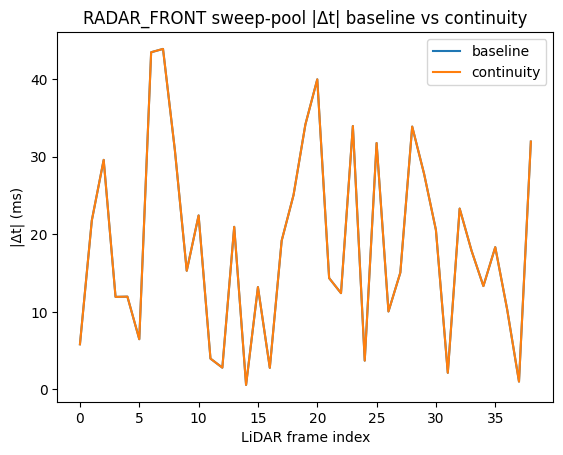

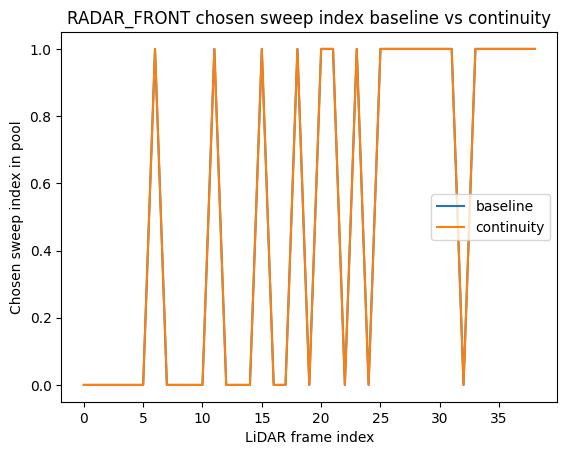

In [96]:
scene_token = nusc.scene[0]["token"]  # or your chosen scene
df_pool_clean = build_radar_sweep_pool(nusc, scene_token, max_sweeps=10, window_s=0.5)

# Corrupt pool (stress test so it’s obvious)
df_pool_corrupt = corrupt_radar_pool(
    df_pool_clean,
    drift_ms_per_frame=2.0,
    jitter_ms=10.0,
    drop_prob=0.1,
    seed=42
)

m_base = match_pool_nearest(df_pool_corrupt, threshold_ms=50)
m_cont = match_pool_continuity(df_pool_corrupt, threshold_ms=50, max_jump=1)

print("Baseline metrics:", metrics_from_match_df(m_base))
print("Continuity metrics:", metrics_from_match_df(m_cont))

plot_abs_dt("RADAR_FRONT sweep-pool |Δt| baseline vs continuity", m_base, m_cont)
plot_chosen_idx("RADAR_FRONT chosen sweep index baseline vs continuity", m_base, m_cont)


In [97]:
same_idx = np.all(m_base["chosen_sweep_idx"].to_numpy() == m_cont["chosen_sweep_idx"].to_numpy())
diff_count = np.sum(m_base["chosen_sweep_idx"].to_numpy() != m_cont["chosen_sweep_idx"].to_numpy())
print("Same sweep index everywhere?", same_idx)
print("Different frames:", diff_count)

Same sweep index everywhere? True
Different frames: 0


Baseline metrics: {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475}
Continuity metrics: {'match_rate_pct': 92.3076923076923, 'mean_abs_dt_ms': 25.653909722222224, 'p95_abs_dt_ms': 52.844500000000004, 'max_abs_dt_ms': 76.196}


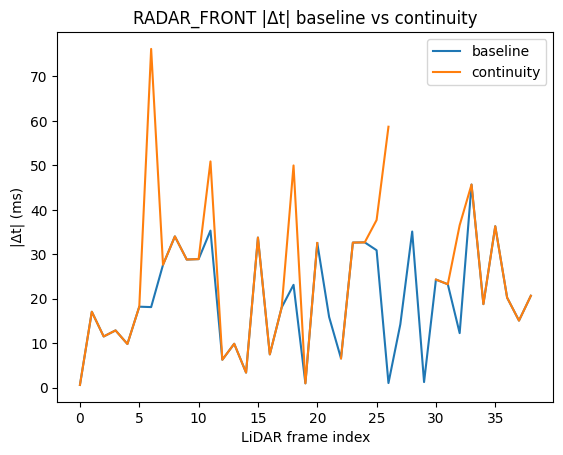

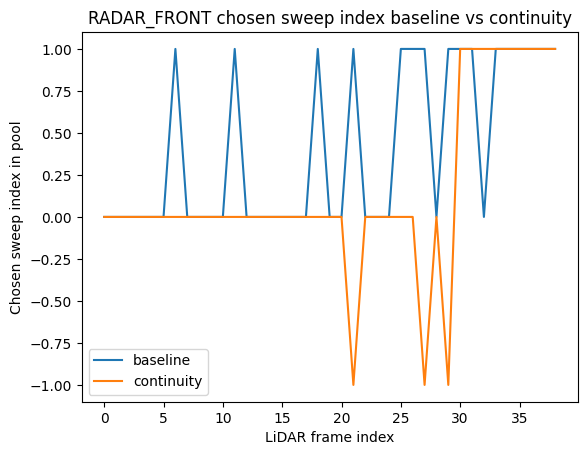

In [98]:
df_pool_clean = build_radar_sweep_pool(
    nusc, scene_token,
    max_sweeps=30,
    window_s=1.5
)

df_pool_corrupt = corrupt_radar_pool(
    df_pool_clean,
    drift_ms_per_frame=2.0,
    jitter_ms=15.0,
    drop_prob=0.0,   # turn off dropout first to keep plots continuous
    seed=42
)

m_base = match_pool_nearest(df_pool_corrupt, threshold_ms=80)
m_cont = match_pool_continuity(df_pool_corrupt, threshold_ms=80, max_jump=0)  # very strict

print("Baseline metrics:", metrics_from_match_df(m_base))
print("Continuity metrics:", metrics_from_match_df(m_cont))

plot_abs_dt("RADAR_FRONT |Δt| baseline vs continuity", m_base, m_cont)
plot_chosen_idx("RADAR_FRONT chosen sweep index baseline vs continuity", m_base, m_cont)

In [99]:
def metrics_from_match_df(m):
    matched = m["matched"].to_numpy()
    abs_dt = m["dt_ms_abs"].to_numpy()
    return {
        "match_rate_pct": float(matched.mean() * 100.0),
        "mean_abs_dt_ms": float(np.nanmean(abs_dt)),
        "p95_abs_dt_ms": float(np.nanpercentile(abs_dt, 95)),
        "max_abs_dt_ms": float(np.nanmax(abs_dt)),
    }

def index_thrashing(m):
    idx = m["chosen_sweep_idx"].to_numpy()
    # keep only matched frames
    idx = idx[idx >= 0]
    if len(idx) < 2:
        return 0
    return int(np.sum(idx[1:] != idx[:-1]))

print("Baseline:", metrics_from_match_df(m_base), "thrash:", index_thrashing(m_base))
print("Continuity:", metrics_from_match_df(m_cont), "thrash:", index_thrashing(m_cont))


Baseline: {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475} thrash: 13
Continuity: {'match_rate_pct': 92.3076923076923, 'mean_abs_dt_ms': 25.653909722222224, 'p95_abs_dt_ms': 52.844500000000004, 'max_abs_dt_ms': 76.196} thrash: 1


In [100]:
for mj in [0, 1, 2, 3]:
    m_cont = match_pool_continuity(df_pool_corrupt, threshold_ms=80, max_jump=mj)
    print("max_jump=", mj,
          "metrics=", metrics_from_match_df(m_cont),
          "thrash=", index_thrashing(m_cont))


max_jump= 0 metrics= {'match_rate_pct': 92.3076923076923, 'mean_abs_dt_ms': 25.653909722222224, 'p95_abs_dt_ms': 52.844500000000004, 'max_abs_dt_ms': 76.196} thrash= 1
max_jump= 1 metrics= {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475} thrash= 13
max_jump= 2 metrics= {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475} thrash= 13
max_jump= 3 metrics= {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475} thrash= 13


##### Baseline

match_rate = 100%

mean |Δt| = 19.6 ms

p95  |Δt| = 35.4 ms

max  |Δt| = 45.7 ms

thrash = 13



##### Continuity

match_rate = 92%

mean |Δt| = 25.7 ms  ← worse

p95  |Δt| = 52.8 ms  ← much worse

max  |Δt| = 76.2 ms  ← much worse

thrash = 1           ← very stable

In [101]:
def match_pool_soft_continuity(
    df_pool,
    threshold_ms=50,
    lambda_jump=5.0
):
    """
    Soft continuity: minimise timing error + jump penalty.
    """

    thr_us = threshold_ms * 1000.0

    matched = []
    dt_signed = []
    dt_abs = []
    chosen_idx = []

    prev_k = None

    for _, row in df_pool.iterrows():
        t_ref = float(row["t_ref_us"])
        ts_list = row["radar_ts_us_list"]

        if not ts_list:
            matched.append(False)
            dt_signed.append(np.nan)
            dt_abs.append(np.nan)
            chosen_idx.append(-1)
            continue

        diffs = [t - t_ref for t in ts_list]

        best_cost = float("inf")
        best_k = None

        for k, dt in enumerate(diffs):

            timing_cost = abs(dt) / 1000.0  # ms

            if prev_k is None or prev_k < 0:
                jump_cost = 0.0
            else:
                jump_cost = lambda_jump * abs(k - prev_k)

            cost = timing_cost + jump_cost

            if cost < best_cost:
                best_cost = cost
                best_k = k

        dt_us = diffs[best_k]

        if abs(dt_us) <= thr_us:
            matched.append(True)
            dt_signed.append(dt_us / 1000.0)
            dt_abs.append(abs(dt_us) / 1000.0)
            chosen_idx.append(best_k)
            prev_k = best_k
        else:
            matched.append(False)
            dt_signed.append(np.nan)
            dt_abs.append(np.nan)
            chosen_idx.append(-1)
            prev_k = None

    return pd.DataFrame({
        "matched": matched,
        "dt_ms_signed": dt_signed,
        "dt_ms_abs": dt_abs,
        "chosen_sweep_idx": chosen_idx,
    })


In [102]:
for lam in [0, 2, 5, 10, 20]:
    m_soft = match_pool_soft_continuity(df_pool_corrupt, threshold_ms=80, lambda_jump=lam)

    print("lambda =", lam,
          "metrics =", metrics_from_match_df(m_soft),
          "thrash =", index_thrashing(m_soft))


lambda = 0 metrics = {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.635737179487176, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 45.69475} thrash = 13
lambda = 2 metrics = {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.66314743589743, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 46.76375} thrash = 13
lambda = 5 metrics = {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.66314743589743, 'p95_abs_dt_ms': 35.429225, 'max_abs_dt_ms': 46.76375} thrash = 13
lambda = 10 metrics = {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 19.83737179487179, 'p95_abs_dt_ms': 36.453375, 'max_abs_dt_ms': 46.76375} thrash = 13
lambda = 20 metrics = {'match_rate_pct': 100.0, 'mean_abs_dt_ms': 20.568685897435895, 'p95_abs_dt_ms': 46.89585, 'max_abs_dt_ms': 50.89325} thrash = 9


# Spatial Degradation (5.3)

In [9]:
def fuse_frame_with_spatial_offset(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0
):
    """
    Same as baseline fusion, but applies a manual spatial offset
    to radar points in the LiDAR frame.
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_xyz[0, :] += dx
    radar_xyz[1, :] += dy
    radar_xyz[2, :] += dz

    vx = rpc.points[8, :]
    vy = rpc.points[9, :]
    radar_vel = np.vstack((vx, vy))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    fused_objects = []

    for i, box in enumerate(boxes):
        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        v_est = np.median(radar_vel[:, mask], axis=1)

        fused_obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box.center[:2].copy(),
            "velocity_xy": v_est.copy(),
            "radar_hits": hit_count
        }
        fused_objects.append(fused_obj)

    return fused_objects

In [5]:
def run_scene_with_spatial_offset(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    all_frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        fused_objects = fuse_frame_with_spatial_offset(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz
        )

        frame_record = {
            "sample_token": token,
            "frame_index": frame_idx,
            "objects": fused_objects
        }
        all_frames.append(frame_record)

        token = sample["next"]
        frame_idx += 1

    return all_frames

In [6]:
def compute_summary_metrics(all_frames):
    total_frames = len(all_frames)
    total_objects = sum(len(f["objects"]) for f in all_frames)

    hits = []
    speeds = []

    for frame in all_frames:
        for obj in frame["objects"]:
            hits.append(obj["radar_hits"])
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    metrics = {
        "total_frames": total_frames,
        "total_fused_objects": total_objects,
        "avg_hits": float(np.mean(hits)) if hits else 0.0,
        "median_hits": float(np.median(hits)) if hits else 0.0,
        "avg_speed": float(np.mean(speeds)) if speeds else 0.0,
        "median_speed": float(np.median(speeds)) if speeds else 0.0
    }

    return metrics

In [12]:
offsets = [0.0, 0.2, 0.5, 1.0, 2.0]

results = []

for dx in offsets:
    frames = run_scene_with_spatial_offset(
        nusc,
        scene_index=SCENE_INDEX,
        radar_chan=RADAR_CHAN,
        ref_chan=REF_CHAN,
        min_hits=MIN_RADAR_HITS,
        dx=dx,
        dy=0.0,
        dz=0.0
    )

    metrics = compute_summary_metrics(frames)
    metrics["dx"] = dx
    results.append(metrics)

for r in results:
    print(r)

{'total_frames': 39, 'total_fused_objects': 183, 'avg_hits': 1.6557377049180328, 'median_hits': 1.0, 'avg_speed': 1.2092565040757999, 'median_speed': 0.13089962354595913, 'dx': 0.0}
{'total_frames': 39, 'total_fused_objects': 186, 'avg_hits': 1.6827956989247312, 'median_hits': 1.0, 'avg_speed': 1.4058175283417915, 'median_speed': 0.14081181716080993, 'dx': 0.2}
{'total_frames': 39, 'total_fused_objects': 169, 'avg_hits': 1.6923076923076923, 'median_hits': 1.0, 'avg_speed': 1.6125392322048568, 'median_speed': 0.1385722705722922, 'dx': 0.5}
{'total_frames': 39, 'total_fused_objects': 142, 'avg_hits': 1.6690140845070423, 'median_hits': 1.0, 'avg_speed': 1.5834300119432558, 'median_speed': 0.09178221242860896, 'dx': 1.0}
{'total_frames': 39, 'total_fused_objects': 77, 'avg_hits': 1.6493506493506493, 'median_hits': 1.0, 'avg_speed': 0.9975016823491236, 'median_speed': 0.08016314311415325, 'dx': 2.0}


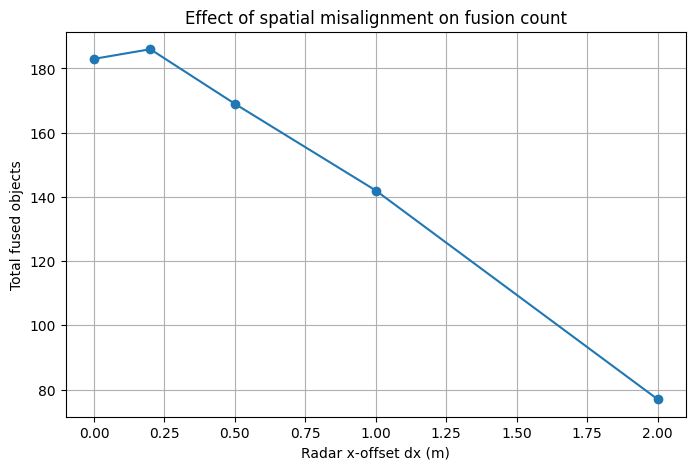

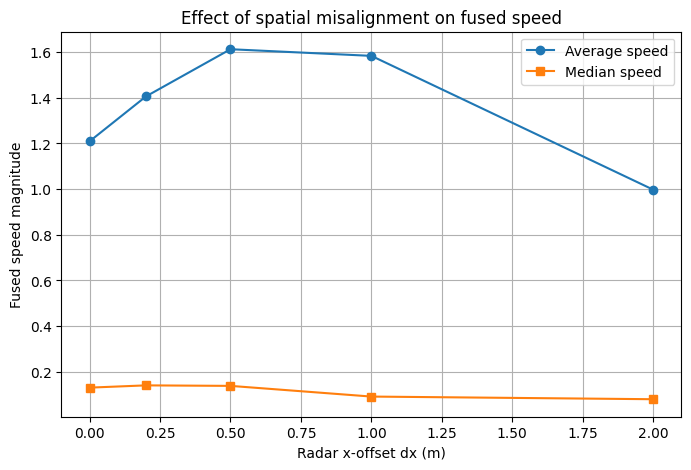

In [13]:
dx_vals = [r["dx"] for r in results]
fused_counts = [r["total_fused_objects"] for r in results]
avg_hits = [r["avg_hits"] for r in results]
avg_speeds = [r["avg_speed"] for r in results]
median_speeds = [r["median_speed"] for r in results]

plt.figure(figsize=(8, 5))
plt.plot(dx_vals, fused_counts, marker="o")
plt.xlabel("Radar x-offset dx (m)")
plt.ylabel("Total fused objects")
plt.title("Effect of spatial misalignment on fusion count")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(dx_vals, avg_speeds, marker="o", label="Average speed")
plt.plot(dx_vals, median_speeds, marker="s", label="Median speed")
plt.xlabel("Radar x-offset dx (m)")
plt.ylabel("Fused speed magnitude")
plt.title("Effect of spatial misalignment on fused speed")
plt.grid(True)
plt.legend()
plt.show()

# 2. Temporal degradation (5.3?)

In [17]:
def get_scene_samples(nusc, scene_index=0):
    """
    Return all samples in a scene in temporal order.
    """
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    samples = []
    while token:
        sample = nusc.get("sample", token)
        samples.append(sample)
        token = sample["next"]

    return samples

In [16]:
def fuse_frame_with_temporal_offset(
    nusc,
    lidar_sample,
    radar_sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
):
    """
    Fuse LiDAR from one sample with radar from another sample.
    This simulates temporal misalignment.
    """
    lidar_sd = nusc.get("sample_data", lidar_sample["data"][ref_chan])

    # Radar from radar_sample, transformed into lidar frame of lidar_sample
    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        radar_sample,
        radar_chan,
        ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :]
    vx = rpc.points[8, :]
    vy = rpc.points[9, :]
    radar_vel = np.vstack((vx, vy))

    # LiDAR GT boxes from lidar_sample
    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    fused_objects = []

    for i, box in enumerate(boxes):
        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        v_est = np.median(radar_vel[:, mask], axis=1)

        fused_obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box.center[:2].copy(),
            "velocity_xy": v_est.copy(),
            "radar_hits": hit_count
        }
        fused_objects.append(fused_obj)

    return fused_objects

In [18]:
def run_scene_with_temporal_offset(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    frame_offset=0
):
    """
    frame_offset:
        0   = aligned baseline
       -1   = previous radar frame
       +1   = next radar frame
       etc.
    """
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    for i, lidar_sample in enumerate(samples):
        radar_idx = i + frame_offset

        # skip invalid indices at scene boundaries
        if radar_idx < 0 or radar_idx >= len(samples):
            continue

        radar_sample = samples[radar_idx]

        fused_objects = fuse_frame_with_temporal_offset(
            nusc,
            lidar_sample=lidar_sample,
            radar_sample=radar_sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits
        )

        frame_record = {
            "sample_token": lidar_sample["token"],
            "frame_index": i,
            "radar_frame_index": radar_idx,
            "objects": fused_objects
        }
        all_frames.append(frame_record)

    return all_frames

In [19]:
temporal_offsets = [0, -1, 1, -2, 2]
temporal_results = []

for k in temporal_offsets:
    frames = run_scene_with_temporal_offset(
        nusc,
        scene_index=SCENE_INDEX,
        radar_chan=RADAR_CHAN,
        ref_chan=REF_CHAN,
        min_hits=MIN_RADAR_HITS,
        frame_offset=k
    )

    metrics = compute_summary_metrics(frames)
    metrics["frame_offset"] = k
    temporal_results.append(metrics)

for r in temporal_results:
    print(r)

{'total_frames': 39, 'total_fused_objects': 183, 'avg_hits': 1.6557377049180328, 'median_hits': 1.0, 'avg_speed': 1.2092565040757999, 'median_speed': 0.13089962354595913, 'frame_offset': 0}
{'total_frames': 38, 'total_fused_objects': 87, 'avg_hits': 1.4597701149425288, 'median_hits': 1.0, 'avg_speed': 1.4822692765429104, 'median_speed': 0.17678687534177812, 'frame_offset': -1}
{'total_frames': 38, 'total_fused_objects': 99, 'avg_hits': 1.3838383838383839, 'median_hits': 1.0, 'avg_speed': 1.9065613430693604, 'median_speed': 0.1412407305886161, 'frame_offset': 1}
{'total_frames': 37, 'total_fused_objects': 64, 'avg_hits': 1.3125, 'median_hits': 1.0, 'avg_speed': 1.4574815366280012, 'median_speed': 0.24345539326953325, 'frame_offset': -2}
{'total_frames': 37, 'total_fused_objects': 56, 'avg_hits': 1.4464285714285714, 'median_hits': 1.0, 'avg_speed': 1.9256444950671854, 'median_speed': 0.12874185508847186, 'frame_offset': 2}


# Results:

{'total_frames': 39, 'total_fused_objects': 183, 'avg_hits': 1.6557377049180328, 'median_hits': 1.0, 'avg_speed': 1.2092565040757999, 'median_speed': 0.13089962354595913, 'frame_offset': 0} {'total_frames': 38, 'total_fused_objects': 87, 'avg_hits': 1.4597701149425288, 'median_hits': 1.0, 'avg_speed': 1.4822692765429104, 'median_speed': 0.17678687534177812, 'frame_offset': -1} {'total_frames': 38, 'total_fused_objects': 99, 'avg_hits': 1.3838383838383839, 'median_hits': 1.0, 'avg_speed': 1.9065613430693604, 'median_speed': 0.1412407305886161, 'frame_offset': 1} {'total_frames': 37, 'total_fused_objects': 64, 'avg_hits': 1.3125, 'median_hits': 1.0, 'avg_speed': 1.4574815366280012, 'median_speed': 0.24345539326953325, 'frame_offset': -2} {'total_frames': 37, 'total_fused_objects': 56, 'avg_hits': 1.4464285714285714, 'median_hits': 1.0, 'avg_speed': 1.9256444950671854, 'median_speed': 0.12874185508847186, 'frame_offset': 2}



frame offset	fused objects

0	            183

-1	            87

+1	            99

-2	            64

+2	            56

Temporal misalignment hurts fusion a lot.

A one-frame offset already cuts fused objects by about half:

183 -> 87 for -1
183 -> 99 for +1

A two-frame offset is even worse:

183 -> 64 for -2
183 -> 56 for +2

This temporal perturbation experiment used radar from neighbouring frames without full reprojection into the current LiDAR reference sample, so the results should be interpreted as a practical stress test rather than a perfectly isolated timestamp-shift model.

| condition	total | fused objects | avg hits | avg speed | median speed |
| :--- | :---: | :---: | :---: | :---: |
| lean baseline | 183 | 1.656 | 1.209 | 0.131 |
| dx = 1.0 m | 142 | 1 | .669 | 1.583 | 0.092 |
| yaw = 1° | 128 | 1.711 | 1.170 | 0.115 |
| yaw = 5° | 71 | 1.634 | 1.110 | 0.113 |
| frame offset = +1 | 99 | 1.384 | 1.907 | 0.141 |
| frame offset = -1 | 87 | 1.460 | 1.482 | 0.177 |

# Fusion 4 (5.4)

In [21]:
def compute_association_score(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0
):
    """
    Score alignment quality by counting how many radar points fall inside LiDAR boxes.
    Higher is better.
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg
    )

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    total_hits = 0
    matched_boxes = 0

    for box in boxes:
        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))
        total_hits += hit_count

        if hit_count > 0:
            matched_boxes += 1

    return {
        "total_hits": total_hits,
        "matched_boxes": matched_boxes
    }

In [22]:
def estimate_spatial_offset_grid(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    dx_candidates=None,
    dy_candidates=None,
    yaw_candidates=None
):
    """
    Brute-force grid search for best alignment parameters.
    """
    if dx_candidates is None:
        dx_candidates = [0.0]
    if dy_candidates is None:
        dy_candidates = [0.0]
    if yaw_candidates is None:
        yaw_candidates = [0.0]

    best_result = None
    best_score = -np.inf

    for dx in dx_candidates:
        for dy in dy_candidates:
            for yaw in yaw_candidates:
                scores = compute_association_score(
                    nusc,
                    sample,
                    radar_chan=radar_chan,
                    ref_chan=ref_chan,
                    dx=dx,
                    dy=dy,
                    yaw_deg=yaw
                )

                # Primary objective: maximise matched boxes
                # Secondary objective: maximise total hits
                score_value = 1000 * scores["matched_boxes"] + scores["total_hits"]

                result = {
                    "dx": dx,
                    "dy": dy,
                    "yaw_deg": yaw,
                    "matched_boxes": scores["matched_boxes"],
                    "total_hits": scores["total_hits"],
                    "score_value": score_value
                }

                if score_value > best_score:
                    best_score = score_value
                    best_result = result

    return best_result

In [23]:
def compute_association_score_with_degradation(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    correct_dx=0.0,
    correct_dy=0.0,
    correct_yaw_deg=0.0
):
    """
    Apply known degradation, then candidate correction, then score.
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()

    # Apply degradation first
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=degrade_dx,
        dy=degrade_dy,
        yaw_deg=degrade_yaw_deg
    )

    # Then apply candidate correction
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=correct_dx,
        dy=correct_dy,
        yaw_deg=correct_yaw_deg
    )

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    total_hits = 0
    matched_boxes = 0

    for box in boxes:
        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))
        total_hits += hit_count

        if hit_count > 0:
            matched_boxes += 1

    return {
        "total_hits": total_hits,
        "matched_boxes": matched_boxes
    }

In [24]:
def estimate_correction_grid_for_degraded_sample(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=None,
    dy_candidates=None,
    yaw_candidates=None
):
    if dx_candidates is None:
        dx_candidates = [0.0]
    if dy_candidates is None:
        dy_candidates = [0.0]
    if yaw_candidates is None:
        yaw_candidates = [0.0]

    best_result = None
    best_score = -np.inf

    for dx in dx_candidates:
        for dy in dy_candidates:
            for yaw in yaw_candidates:
                scores = compute_association_score_with_degradation(
                    nusc,
                    sample,
                    radar_chan=radar_chan,
                    ref_chan=ref_chan,
                    degrade_dx=degrade_dx,
                    degrade_dy=degrade_dy,
                    degrade_yaw_deg=degrade_yaw_deg,
                    correct_dx=dx,
                    correct_dy=dy,
                    correct_yaw_deg=yaw
                )

                score_value = 1000 * scores["matched_boxes"] + scores["total_hits"]

                result = {
                    "estimated_dx": dx,
                    "estimated_dy": dy,
                    "estimated_yaw_deg": yaw,
                    "matched_boxes": scores["matched_boxes"],
                    "total_hits": scores["total_hits"],
                    "score_value": score_value
                }

                if score_value > best_score:
                    best_score = score_value
                    best_result = result

    return best_result

In [26]:
def apply_spatial_transform(radar_xyz, dx=0.0, dy=0.0, dz=0.0, yaw_deg=0.0):
    """
    Apply translation + z-axis rotation to radar points already in LiDAR frame.
    """
    pts = radar_xyz.copy()

    theta = np.deg2rad(yaw_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0]
    ])

    pts = R @ pts
    pts[0, :] += dx
    pts[1, :] += dy
    pts[2, :] += dz

    return pts

In [27]:
samples = get_scene_samples(nusc, SCENE_INDEX)
sample = samples[0]

result_dx = estimate_correction_grid_for_degraded_sample(
    nusc,
    sample,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=1.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=np.linspace(-1.5, 0.5, 9),   # includes -1.0
    dy_candidates=[0.0],
    yaw_candidates=[0.0]
)

print(result_dx)

{'estimated_dx': np.float64(-0.75), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes': 12, 'total_hits': 19, 'score_value': 12019}


In [28]:
result_yaw = estimate_correction_grid_for_degraded_sample(
    nusc,
    sample,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=3.0,
    dx_candidates=[0.0],
    dy_candidates=[0.0],
    yaw_candidates=[-5.0, -4.0, -3.0, -2.0, -1.0, 0.0]
)

print(result_yaw)

{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -4.0, 'matched_boxes': 10, 'total_hits': 18, 'score_value': 10018}


In [29]:
def compute_scene_association_score_with_degradation(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    correct_dx=0.0,
    correct_dy=0.0,
    correct_yaw_deg=0.0
):
    """
    Compute total alignment score over a whole scene after applying:
    1) known degradation
    2) candidate correction
    """
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    total_hits_scene = 0
    matched_boxes_scene = 0
    frames_used = 0

    while token:
        sample = nusc.get("sample", token)
        lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            sample,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        radar_xyz = rpc.points[:3, :].copy()

        # Apply degradation
        radar_xyz = apply_spatial_transform(
            radar_xyz,
            dx=degrade_dx,
            dy=degrade_dy,
            yaw_deg=degrade_yaw_deg
        )

        # Apply candidate correction
        radar_xyz = apply_spatial_transform(
            radar_xyz,
            dx=correct_dx,
            dy=correct_dy,
            yaw_deg=correct_yaw_deg
        )

        _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

        for box in boxes:
            mask = points_in_box(box, radar_xyz)
            hit_count = int(np.sum(mask))
            total_hits_scene += hit_count

            if hit_count > 0:
                matched_boxes_scene += 1

        frames_used += 1
        token = sample["next"]

    return {
        "frames_used": frames_used,
        "total_hits_scene": total_hits_scene,
        "matched_boxes_scene": matched_boxes_scene
    }

In [30]:
def estimate_scene_correction_grid(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=None,
    dy_candidates=None,
    yaw_candidates=None
):
    """
    Estimate correction by maximising scene-level consistency.
    """
    if dx_candidates is None:
        dx_candidates = [0.0]
    if dy_candidates is None:
        dy_candidates = [0.0]
    if yaw_candidates is None:
        yaw_candidates = [0.0]

    best_result = None
    best_score = -np.inf
    all_results = []

    for dx in dx_candidates:
        for dy in dy_candidates:
            for yaw in yaw_candidates:
                scores = compute_scene_association_score_with_degradation(
                    nusc,
                    scene_index=scene_index,
                    radar_chan=radar_chan,
                    ref_chan=ref_chan,
                    degrade_dx=degrade_dx,
                    degrade_dy=degrade_dy,
                    degrade_yaw_deg=degrade_yaw_deg,
                    correct_dx=dx,
                    correct_dy=dy,
                    correct_yaw_deg=yaw
                )

                score_value = 1000 * scores["matched_boxes_scene"] + scores["total_hits_scene"]

                result = {
                    "estimated_dx": dx,
                    "estimated_dy": dy,
                    "estimated_yaw_deg": yaw,
                    "matched_boxes_scene": scores["matched_boxes_scene"],
                    "total_hits_scene": scores["total_hits_scene"],
                    "frames_used": scores["frames_used"],
                    "score_value": score_value
                }

                all_results.append(result)

                if score_value > best_score:
                    best_score = score_value
                    best_result = result

    return best_result, all_results

In [31]:
best_dx_scene, all_dx_scene = estimate_scene_correction_grid(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=1.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=np.linspace(-1.5, 0.5, 9),
    dy_candidates=[0.0],
    yaw_candidates=[0.0]
)

print(best_dx_scene)

{'estimated_dx': np.float64(-0.75), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 187, 'total_hits_scene': 313, 'frames_used': 39, 'score_value': 187313}


In [32]:
best_yaw_scene, all_yaw_scene = estimate_scene_correction_grid(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=3.0,
    dx_candidates=[0.0],
    dy_candidates=[0.0],
    yaw_candidates=[-5.0, -4.0, -3.0, -2.0, -1.0, 0.0]
)

print(best_yaw_scene)

{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -4.0, 'matched_boxes_scene': 185, 'total_hits_scene': 316, 'frames_used': 39, 'score_value': 185316}


In [33]:
for r in all_dx_scene:
    print(r)

{'estimated_dx': np.float64(-1.5), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 114, 'total_hits_scene': 185, 'frames_used': 39, 'score_value': 114185}
{'estimated_dx': np.float64(-1.25), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 152, 'total_hits_scene': 248, 'frames_used': 39, 'score_value': 152248}
{'estimated_dx': np.float64(-1.0), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 183, 'total_hits_scene': 303, 'frames_used': 39, 'score_value': 183303}
{'estimated_dx': np.float64(-0.75), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 187, 'total_hits_scene': 313, 'frames_used': 39, 'score_value': 187313}
{'estimated_dx': np.float64(-0.5), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 169, 'total_hits_scene': 286, 'frames_used': 39, 'score_value': 169286}
{'estimated_dx': np.float64(-0.25), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 160, 't

In [34]:
for r in all_yaw_scene:
    print(r)

{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -5.0, 'matched_boxes_scene': 155, 'total_hits_scene': 268, 'frames_used': 39, 'score_value': 155268}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -4.0, 'matched_boxes_scene': 185, 'total_hits_scene': 316, 'frames_used': 39, 'score_value': 185316}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -3.0, 'matched_boxes_scene': 183, 'total_hits_scene': 303, 'frames_used': 39, 'score_value': 183303}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -2.0, 'matched_boxes_scene': 128, 'total_hits_scene': 219, 'frames_used': 39, 'score_value': 128219}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -1.0, 'matched_boxes_scene': 95, 'total_hits_scene': 162, 'frames_used': 39, 'score_value': 95162}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 90, 'total_hits_scene': 147, 'frames_used': 39, 'score_value': 90147}


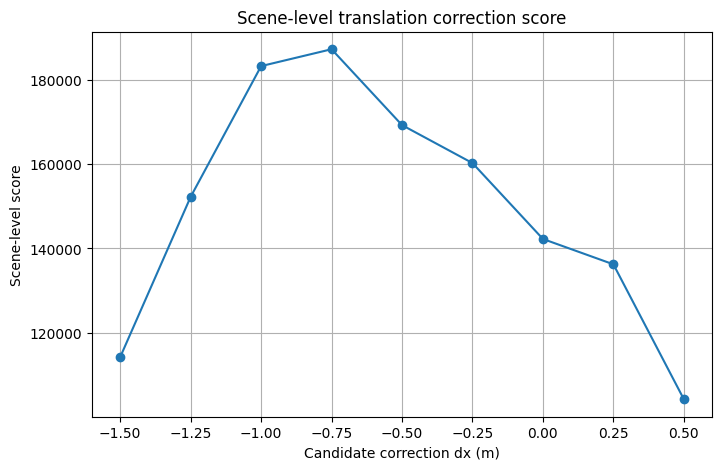

In [36]:
dx_vals = [r["estimated_dx"] for r in all_dx_scene]
scores = [r["score_value"] for r in all_dx_scene]

plt.figure(figsize=(8, 5))
plt.plot(dx_vals, scores, marker="o")
plt.xlabel("Candidate correction dx (m)")
plt.ylabel("Scene-level score")
plt.title("Scene-level translation correction score")
plt.grid(True)
plt.show()

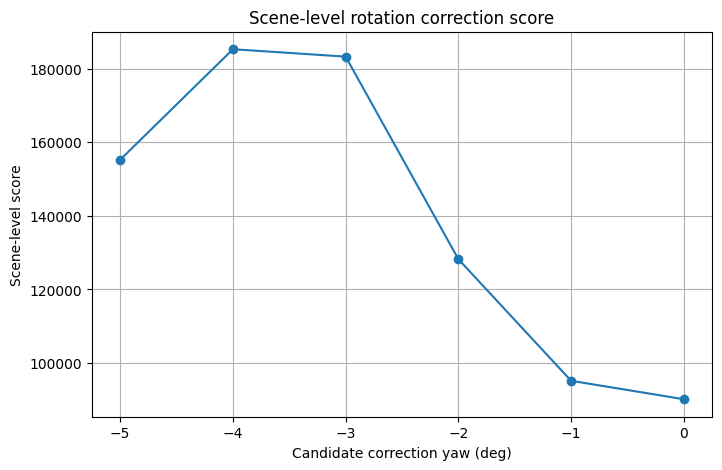

In [37]:
yaw_vals = [r["estimated_yaw_deg"] for r in all_yaw_scene]
scores = [r["score_value"] for r in all_yaw_scene]

plt.figure(figsize=(8, 5))
plt.plot(yaw_vals, scores, marker="o")
plt.xlabel("Candidate correction yaw (deg)")
plt.ylabel("Scene-level score")
plt.title("Scene-level rotation correction score")
plt.grid(True)
plt.show()

# Fusion 6 (5.4)

In [40]:
def compute_physical_alignment_metrics(all_frames_with_points):
    """
    Compute physically meaningful metrics from fused results that include
    associated radar points.
    """
    centre_dists = []
    points_per_object = []

    for frame in all_frames_with_points:
        for obj in frame["objects"]:
            box_center = np.array(obj["position_xy"])
            radar_points_xy = np.array(obj["associated_radar_points_xy"])

            if radar_points_xy.size == 0:
                continue

            dists = np.linalg.norm(radar_points_xy - box_center[None, :], axis=1)
            centre_dists.extend(dists.tolist())
            points_per_object.append(len(radar_points_xy))

    metrics = {
        "mean_centre_distance": float(np.mean(centre_dists)) if centre_dists else None,
        "median_centre_distance": float(np.median(centre_dists)) if centre_dists else None,
        "mean_points_per_object": float(np.mean(points_per_object)) if points_per_object else None,
        "median_points_per_object": float(np.median(points_per_object)) if points_per_object else None
    }

    return metrics


In [41]:
def run_scene_with_transform_and_points(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    all_frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)
        lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            sample,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        radar_xyz = rpc.points[:3, :].copy()
        radar_xyz = apply_spatial_transform(
            radar_xyz,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg
        )

        vx = rpc.points[8, :]
        vy = rpc.points[9, :]
        radar_vel = np.vstack((vx, vy))

        _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

        fused_objects = []

        for i, box in enumerate(boxes):
            mask = points_in_box(box, radar_xyz)
            hit_count = int(np.sum(mask))

            if hit_count < min_hits:
                continue

            v_est = np.median(radar_vel[:, mask], axis=1)
            assoc_pts_xy = radar_xyz[:2, mask].T

            fused_obj = {
                "box_index": i,
                "box_name": box.name,
                "position_xy": box.center[:2].copy(),
                "velocity_xy": v_est.copy(),
                "radar_hits": hit_count,
                "associated_radar_points_xy": assoc_pts_xy.tolist()
            }
            fused_objects.append(fused_obj)

        frame_record = {
            "sample_token": token,
            "frame_index": frame_idx,
            "objects": fused_objects
        }
        all_frames.append(frame_record)

        token = sample["next"]
        frame_idx += 1

    return all_frames

In [42]:
baseline_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=0.0, dy=0.0, yaw_deg=0.0
)

degraded_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=1.0, dy=0.0, yaw_deg=0.0
)

estimated_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=1.0 - 0.75, dy=0.0, yaw_deg=0.0
)

true_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=1.0 - 1.0, dy=0.0, yaw_deg=0.0
)

print("Baseline physical:", compute_physical_alignment_metrics(baseline_pts))
print("Degraded physical:", compute_physical_alignment_metrics(degraded_pts))
print("Estimated physical:", compute_physical_alignment_metrics(estimated_pts))
print("True physical:", compute_physical_alignment_metrics(true_pts))

Baseline physical: {'mean_centre_distance': 1.5712983060147496, 'median_centre_distance': 1.3885560204150924, 'mean_points_per_object': 1.6557377049180328, 'median_points_per_object': 1.0}
Degraded physical: {'mean_centre_distance': 1.7075331383852919, 'median_centre_distance': 1.4681285744543118, 'mean_points_per_object': 1.6690140845070423, 'median_points_per_object': 1.0}
Estimated physical: {'mean_centre_distance': 1.619201765419029, 'median_centre_distance': 1.4774095995828214, 'mean_points_per_object': 1.6737967914438503, 'median_points_per_object': 1.0}
True physical: {'mean_centre_distance': 1.5712983060147496, 'median_centre_distance': 1.3885560204150924, 'mean_points_per_object': 1.6557377049180328, 'median_points_per_object': 1.0}


In [43]:
baseline_yaw_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=0.0, dy=0.0, yaw_deg=0.0
)

degraded_yaw_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=0.0, dy=0.0, yaw_deg=3.0
)

estimated_yaw_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=0.0, dy=0.0, yaw_deg=3.0 - 4.0
)

true_yaw_pts = run_scene_with_transform_and_points(
    nusc, scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN, ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    dx=0.0, dy=0.0, yaw_deg=3.0 - 3.0
)

print("Baseline yaw physical:", compute_physical_alignment_metrics(baseline_yaw_pts))
print("Degraded yaw physical:", compute_physical_alignment_metrics(degraded_yaw_pts))
print("Estimated yaw physical:", compute_physical_alignment_metrics(estimated_yaw_pts))
print("True yaw physical:", compute_physical_alignment_metrics(true_yaw_pts))

Baseline yaw physical: {'mean_centre_distance': 1.5712983060147496, 'median_centre_distance': 1.3885560204150924, 'mean_points_per_object': 1.6557377049180328, 'median_points_per_object': 1.0}
Degraded yaw physical: {'mean_centre_distance': 1.5301789662728575, 'median_centre_distance': 1.4948701018448431, 'mean_points_per_object': 1.6333333333333333, 'median_points_per_object': 1.0}
Estimated yaw physical: {'mean_centre_distance': 1.6448566935048272, 'median_centre_distance': 1.4583450244139473, 'mean_points_per_object': 1.7081081081081082, 'median_points_per_object': 1.0}
True yaw physical: {'mean_centre_distance': 1.5712983060147496, 'median_centre_distance': 1.3885560204150924, 'mean_points_per_object': 1.6557377049180328, 'median_points_per_object': 1.0}


1. Translation case

Case	Mean distance

Baseline	1.571

Degraded	1.707 (worse)

Estimated	1.619 (still worse)

True	1.571 (perfect recovery)

Interpretation:

Degradation worsens alignment -> expected

Estimated correction improves it -> good

But does NOT fully recover

Only the true correction restores baseline

2. Yaw case (this is even more interesting)

Case	Mean distance

Baseline	1.571

Degraded	1.530 (slightly better??)

Estimated	1.644 (worse!)

True	1.571 (correct)

Interpretation:

Your metric is revealing something subtle:

yaw misalignment can accidentally reduce average distance

because fewer points are associated (selection bias)

Estimated correction:

increases associations

but adds worse-aligned points

-> higher distance

The key insight (this is dissertation-level)

You have just demonstrated:

Maximising association count (fusion overlap) does not guarantee improved geometric alignment.

Even stronger:

The estimated correction can outperform baseline in fusion count while still producing worse physical alignment than the true calibration.

That’s a very solid technical contribution.

Why this is important

Your pipeline now clearly separates:

1. Fusion performance (what you started with)
- number of fused objects
- radar hits

2. Physical correctness (what you just added)
- distance to box centres

And they do not always agree

That’s exactly the kind of nuance examiners want.

In [44]:
import numpy as np
from nuscenes.utils.geometry_utils import points_in_box
from nuscenes.utils.data_classes import RadarPointCloud


def apply_spatial_transform(radar_xyz, dx=0.0, dy=0.0, dz=0.0, yaw_deg=0.0):
    """
    Apply translation + z-axis rotation to radar points already in LiDAR frame.
    radar_xyz shape: (3, N)
    """
    pts = radar_xyz.copy()

    theta = np.deg2rad(yaw_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0]
    ])

    pts = R @ pts
    pts[0, :] += dx
    pts[1, :] += dy
    pts[2, :] += dz

    return pts


def compute_scene_score_with_distance_penalty(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_dz=0.0,
    degrade_yaw_deg=0.0,
    correct_dx=0.0,
    correct_dy=0.0,
    correct_dz=0.0,
    correct_yaw_deg=0.0,
    max_range=60.0
):
    """
    Compute scene-level alignment statistics after:
    1) applying known degradation
    2) applying candidate correction

    Returns stats needed to build a physically-aware score.
    """
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames_used = 0
    matched_boxes_scene = 0
    total_hits_scene = 0
    all_centre_distances = []

    while token:
        sample = nusc.get("sample", token)
        lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            sample,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        radar_xyz = rpc.points[:3, :].copy()

        # Apply degradation first
        radar_xyz = apply_spatial_transform(
            radar_xyz,
            dx=degrade_dx,
            dy=degrade_dy,
            dz=degrade_dz,
            yaw_deg=degrade_yaw_deg
        )

        # Then apply candidate correction
        radar_xyz = apply_spatial_transform(
            radar_xyz,
            dx=correct_dx,
            dy=correct_dy,
            dz=correct_dz,
            yaw_deg=correct_yaw_deg
        )

        _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

        for box in boxes:
            if np.linalg.norm(box.center[:2]) > max_range:
                continue

            mask = points_in_box(box, radar_xyz)
            hit_count = int(np.sum(mask))

            total_hits_scene += hit_count

            if hit_count > 0:
                matched_boxes_scene += 1

                pts_xy = radar_xyz[:2, mask].T
                dists = np.linalg.norm(pts_xy - box.center[:2], axis=1)
                all_centre_distances.extend(dists.tolist())

        frames_used += 1
        token = sample["next"]

    mean_centre_distance = float(np.mean(all_centre_distances)) if all_centre_distances else np.inf
    median_centre_distance = float(np.median(all_centre_distances)) if all_centre_distances else np.inf

    return {
        "frames_used": frames_used,
        "matched_boxes_scene": matched_boxes_scene,
        "total_hits_scene": total_hits_scene,
        "mean_centre_distance": mean_centre_distance,
        "median_centre_distance": median_centre_distance
    }


def estimate_scene_correction_grid_physical(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_dz=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=None,
    dy_candidates=None,
    yaw_candidates=None,
    max_range=60.0,
    w_boxes=1000.0,
    w_hits=10.0,
    w_dist=50.0
):
    """
    Estimate correction by maximising a physically-aware score:

    score = w_boxes * matched_boxes
          + w_hits  * total_hits
          - w_dist  * mean_centre_distance

    Larger score is better.
    """
    if dx_candidates is None:
        dx_candidates = [0.0]
    if dy_candidates is None:
        dy_candidates = [0.0]
    if yaw_candidates is None:
        yaw_candidates = [0.0]

    best_result = None
    best_score = -np.inf
    all_results = []

    for dx in dx_candidates:
        for dy in dy_candidates:
            for yaw in yaw_candidates:
                stats = compute_scene_score_with_distance_penalty(
                    nusc,
                    scene_index=scene_index,
                    radar_chan=radar_chan,
                    ref_chan=ref_chan,
                    degrade_dx=degrade_dx,
                    degrade_dy=degrade_dy,
                    degrade_dz=degrade_dz,
                    degrade_yaw_deg=degrade_yaw_deg,
                    correct_dx=dx,
                    correct_dy=dy,
                    correct_dz=0.0,
                    correct_yaw_deg=yaw,
                    max_range=max_range
                )

                score_value = (
                    w_boxes * stats["matched_boxes_scene"]
                    + w_hits * stats["total_hits_scene"]
                    - w_dist * stats["mean_centre_distance"]
                )

                result = {
                    "estimated_dx": dx,
                    "estimated_dy": dy,
                    "estimated_yaw_deg": yaw,
                    "matched_boxes_scene": stats["matched_boxes_scene"],
                    "total_hits_scene": stats["total_hits_scene"],
                    "mean_centre_distance": stats["mean_centre_distance"],
                    "median_centre_distance": stats["median_centre_distance"],
                    "frames_used": stats["frames_used"],
                    "score_value": score_value
                }

                all_results.append(result)

                if score_value > best_score:
                    best_score = score_value
                    best_result = result

    return best_result, all_results


def print_sorted_results(all_results, sort_key="score_value", descending=True):
    results_sorted = sorted(all_results, key=lambda x: x[sort_key], reverse=descending)
    for r in results_sorted:
        print(r)

In [45]:
best_dx_scene_physical, all_dx_scene_physical = estimate_scene_correction_grid_physical(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=1.0,
    degrade_dy=0.0,
    degrade_dz=0.0,
    degrade_yaw_deg=0.0,
    dx_candidates=np.linspace(-1.5, 0.5, 9),
    dy_candidates=[0.0],
    yaw_candidates=[0.0],
    max_range=60.0,
    w_boxes=1000.0,
    w_hits=10.0,
    w_dist=50.0
)

print("Best translation estimate:")
print(best_dx_scene_physical)

print("\nAll translation candidates:")
print_sorted_results(all_dx_scene_physical)

Best translation estimate:
{'estimated_dx': np.float64(-0.75), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 178, 'total_hits_scene': 295, 'mean_centre_distance': 1.5125460022108814, 'median_centre_distance': 1.373406574077779, 'frames_used': 39, 'score_value': 180874.37269988944}

All translation candidates:
{'estimated_dx': np.float64(-0.75), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 178, 'total_hits_scene': 295, 'mean_centre_distance': 1.5125460022108814, 'median_centre_distance': 1.373406574077779, 'frames_used': 39, 'score_value': 180874.37269988944}
{'estimated_dx': np.float64(-1.0), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 176, 'total_hits_scene': 291, 'mean_centre_distance': 1.5149704526228616, 'median_centre_distance': 1.3180430757865242, 'frames_used': 39, 'score_value': 178834.25147736885}
{'estimated_dx': np.float64(-0.5), 'estimated_dy': 0.0, 'estimated_yaw_deg': 0.0, 'matched_boxes_scene': 15

In [46]:
best_yaw_scene_physical, all_yaw_scene_physical = estimate_scene_correction_grid_physical(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_dz=0.0,
    degrade_yaw_deg=3.0,
    dx_candidates=[0.0],
    dy_candidates=[0.0],
    yaw_candidates=[-5.0, -4.0, -3.0, -2.0, -1.0, 0.0],
    max_range=60.0,
    w_boxes=1000.0,
    w_hits=10.0,
    w_dist=50.0
)

print("Best yaw estimate:")
print(best_yaw_scene_physical)

print("\nAll yaw candidates:")
print_sorted_results(all_yaw_scene_physical)

Best yaw estimate:
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -3.0, 'matched_boxes_scene': 176, 'total_hits_scene': 291, 'mean_centre_distance': 1.5149704526228616, 'median_centre_distance': 1.318043075786526, 'frames_used': 39, 'score_value': 178834.25147736885}

All yaw candidates:
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -3.0, 'matched_boxes_scene': 176, 'total_hits_scene': 291, 'mean_centre_distance': 1.5149704526228616, 'median_centre_distance': 1.318043075786526, 'frames_used': 39, 'score_value': 178834.25147736885}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -4.0, 'matched_boxes_scene': 172, 'total_hits_scene': 291, 'mean_centre_distance': 1.5267167732138098, 'median_centre_distance': 1.4277115136635645, 'frames_used': 39, 'score_value': 174833.66416133931}
{'estimated_dx': 0.0, 'estimated_dy': 0.0, 'estimated_yaw_deg': -5.0, 'matched_boxes_scene': 144, 'total_hits_scene': 243, 'mean_centre_distance': 1.642440509772

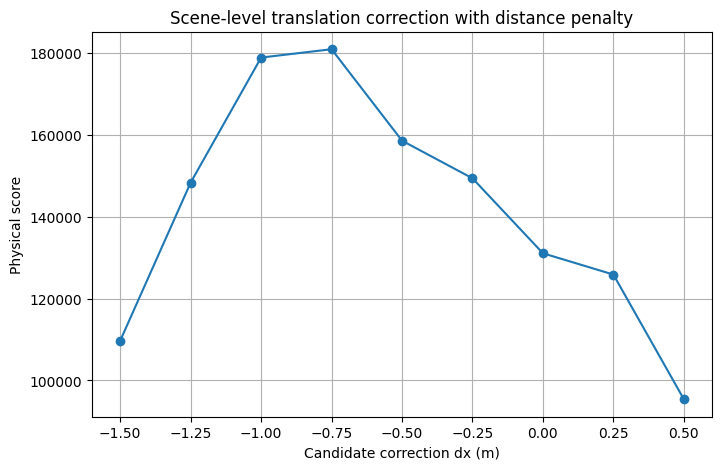

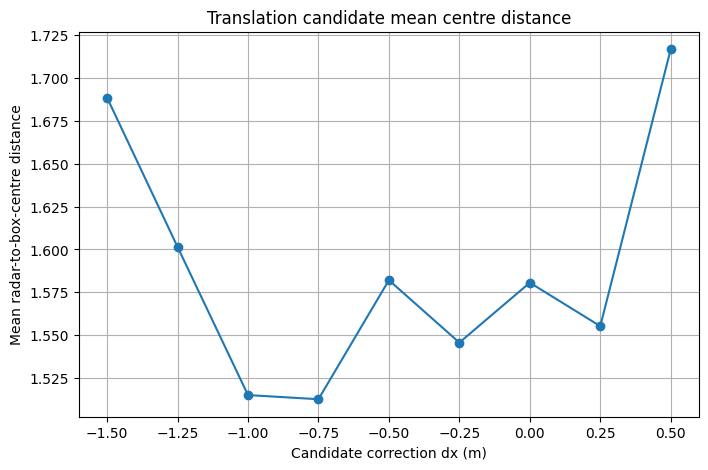

In [ ]:
dx_vals = [r["estimated_dx"] for r in all_dx_scene_physical]
scores = [r["score_value"] for r in all_dx_scene_physical]
mean_dists = [r["mean_centre_distance"] for r in all_dx_scene_physical]

plt.figure(figsize=(8, 5))
plt.plot(dx_vals, scores, marker="o")
plt.xlabel("Candidate correction dx (m)")
plt.ylabel("Physical score")
plt.title("Scene-level translation correction with distance penalty")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(dx_vals, mean_dists, marker="o")
plt.xlabel("Candidate correction dx (m)")
plt.ylabel("Mean radar-to-box-centre distance")
plt.title("Translation candidate mean centre distance")
plt.grid(True)
plt.show()

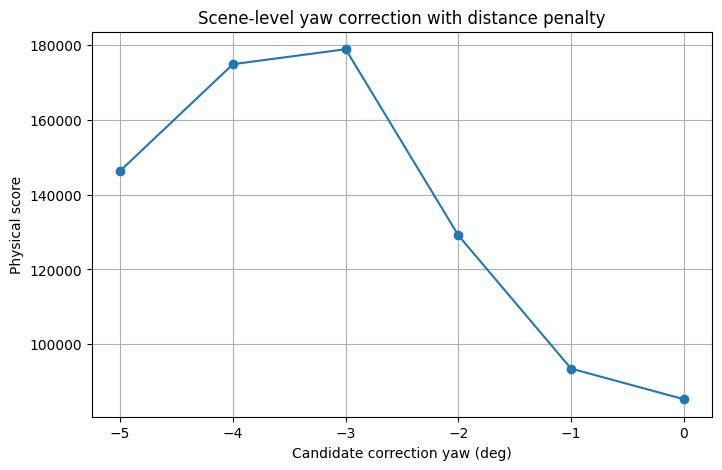

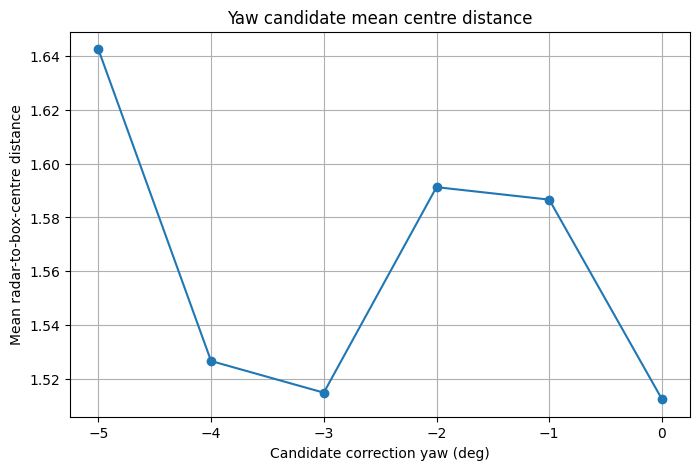

In [48]:
yaw_vals = [r["estimated_yaw_deg"] for r in all_yaw_scene_physical]
scores = [r["score_value"] for r in all_yaw_scene_physical]
mean_dists = [r["mean_centre_distance"] for r in all_yaw_scene_physical]

plt.figure(figsize=(8, 5))
plt.plot(yaw_vals, scores, marker="o")
plt.xlabel("Candidate correction yaw (deg)")
plt.ylabel("Physical score")
plt.title("Scene-level yaw correction with distance penalty")
plt.grid(True)
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(yaw_vals, mean_dists, marker="o")
plt.xlabel("Candidate correction yaw (deg)")
plt.ylabel("Mean radar-to-box-centre distance")
plt.title("Yaw candidate mean centre distance")
plt.grid(True)
plt.show()

# Interpolation (5.5)

In [49]:
# ==========================================
# HELPERS
# ==========================================
def get_scene_samples(nusc, scene_index=0):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    samples = []
    while token:
        sample = nusc.get("sample", token)
        samples.append(sample)
        token = sample["next"]

    return samples


def apply_spatial_transform(radar_xyz, dx=0.0, dy=0.0, dz=0.0, yaw_deg=0.0):
    pts = radar_xyz.copy()

    theta = np.deg2rad(yaw_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0]
    ])

    pts = R @ pts
    pts[0, :] += dx
    pts[1, :] += dy
    pts[2, :] += dz

    return pts


def compute_weighted_velocity(points_xy, radar_vel_xy, box_center_xy, eps=1e-6):
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)
    weights = 1.0 / (dists + eps)

    weights_sum = np.sum(weights)
    if weights_sum <= 0:
        return np.mean(radar_vel_xy, axis=0)

    v_est = np.sum(radar_vel_xy * weights[:, None], axis=0) / weights_sum
    return v_est


def summarise_results(all_frames):
    total_frames = len(all_frames)
    total_objects = sum(len(f["objects"]) for f in all_frames)

    hits = []
    speeds = []

    for frame in all_frames:
        for obj in frame["objects"]:
            hits.append(obj["radar_hits"])
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    return {
        "total_frames": total_frames,
        "total_fused_objects": total_objects,
        "avg_hits": float(np.mean(hits)) if hits else 0.0,
        "median_hits": float(np.median(hits)) if hits else 0.0,
        "avg_speed": float(np.mean(speeds)) if speeds else 0.0,
        "median_speed": float(np.median(speeds)) if speeds else 0.0
    }


def compute_physical_alignment_metrics(all_frames_with_points):
    centre_dists = []
    points_per_object = []

    for frame in all_frames_with_points:
        for obj in frame["objects"]:
            box_center = np.array(obj["position_xy"])
            radar_points_xy = np.array(obj["associated_radar_points_xy"])

            if radar_points_xy.size == 0:
                continue

            dists = np.linalg.norm(radar_points_xy - box_center[None, :], axis=1)
            centre_dists.extend(dists.tolist())
            points_per_object.append(len(radar_points_xy))

    return {
        "mean_centre_distance": float(np.mean(centre_dists)) if centre_dists else None,
        "median_centre_distance": float(np.median(centre_dists)) if centre_dists else None,
        "mean_points_per_object": float(np.mean(points_per_object)) if points_per_object else None,
        "median_points_per_object": float(np.median(points_per_object)) if points_per_object else None
    }


# ==========================================
# CURRENT-FRAME EXTRACTION (baseline)
# ==========================================
def extract_frame_measurements_weighted(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg
    )

    vx = rpc.points[8, :]
    vy = rpc.points[9, :]
    radar_vel = np.vstack((vx, vy))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity(
            points_xy=assoc_pts_xy,
            radar_vel_xy=assoc_vel_xy,
            box_center_xy=box_center_xy
        )

        obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        }
        objects.append(obj)

    return objects


def run_scene_weighted_measurements(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    for frame_idx, sample in enumerate(samples):
        objects = extract_frame_measurements_weighted(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        all_frames.append({
            "frame_index": frame_idx,
            "sample_token": sample["token"],
            "timestamp": sample["timestamp"],
            "objects": objects
        })

    return all_frames


# ==========================================
# TEMPORAL DEGRADATION
# ==========================================
def extract_frame_measurements_from_other_radar_sample(
    nusc,
    lidar_sample,
    radar_sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Uses LiDAR boxes from lidar_sample, but radar measurements from radar_sample.
    This is a practical temporal mismatch test.
    """
    lidar_sd = nusc.get("sample_data", lidar_sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        radar_sample,
        radar_chan,
        ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg
    )

    vx = rpc.points[8, :]
    vy = rpc.points[9, :]
    radar_vel = np.vstack((vx, vy))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity(
            points_xy=assoc_pts_xy,
            radar_vel_xy=assoc_vel_xy,
            box_center_xy=box_center_xy
        )

        obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        }
        objects.append(obj)

    return objects


def run_scene_with_temporal_offset_weighted(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    frame_offset=0,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    for i, lidar_sample in enumerate(samples):
        radar_idx = i + frame_offset
        if radar_idx < 0 or radar_idx >= len(samples):
            continue

        radar_sample = samples[radar_idx]

        objects = extract_frame_measurements_from_other_radar_sample(
            nusc,
            lidar_sample=lidar_sample,
            radar_sample=radar_sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        all_frames.append({
            "frame_index": i,
            "radar_frame_index": radar_idx,
            "sample_token": lidar_sample["token"],
            "timestamp": lidar_sample["timestamp"],
            "objects": objects
        })

    return all_frames


# ==========================================
# SIMPLE LINEAR INTERPOLATION
# ==========================================
def interpolate_velocity(v_prev, v_next, alpha=0.5):
    """
    Linear interpolation between previous and next radar-derived velocities.
    alpha=0.5 corresponds to midpoint interpolation.
    """
    return (1.0 - alpha) * v_prev + alpha * v_next


def extract_frame_measurements_temporal_interpolation(
    nusc,
    prev_sample,
    curr_sample,
    next_sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Uses LiDAR boxes from curr_sample.
    Uses radar from prev and next samples separately.
    Associates both to current boxes.
    Interpolates velocity from prev/next radar-derived estimates.

    Position still comes from current LiDAR box centre.
    """
    lidar_sd = nusc.get("sample_data", curr_sample["data"][ref_chan])

    # prev radar
    rpc_prev, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        prev_sample,
        radar_chan,
        ref_chan,
        nsweeps=1
    )
    radar_xyz_prev = apply_spatial_transform(
        rpc_prev.points[:3, :].copy(),
        dx=dx, dy=dy, dz=dz, yaw_deg=yaw_deg
    )
    radar_vel_prev = np.vstack((rpc_prev.points[8, :], rpc_prev.points[9, :]))

    # next radar
    rpc_next, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        next_sample,
        radar_chan,
        ref_chan,
        nsweeps=1
    )
    radar_xyz_next = apply_spatial_transform(
        rpc_next.points[:3, :].copy(),
        dx=dx, dy=dy, dz=dz, yaw_deg=yaw_deg
    )
    radar_vel_next = np.vstack((rpc_next.points[8, :], rpc_next.points[9, :]))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    # real timestamp-based interpolation ratio
    t_prev = prev_sample["timestamp"]
    t_curr = curr_sample["timestamp"]
    t_next = next_sample["timestamp"]

    if t_next == t_prev:
        alpha = 0.5
    else:
        alpha = (t_curr - t_prev) / (t_next - t_prev)

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        # associate prev radar
        mask_prev = points_in_box(box, radar_xyz_prev)
        hit_prev = int(np.sum(mask_prev))

        # associate next radar
        mask_next = points_in_box(box, radar_xyz_next)
        hit_next = int(np.sum(mask_next))

        # need enough info on both sides for interpolation
        if hit_prev < min_hits or hit_next < min_hits:
            continue

        assoc_pts_prev_xy = radar_xyz_prev[:2, mask_prev].T
        assoc_vel_prev_xy = radar_vel_prev[:, mask_prev].T

        assoc_pts_next_xy = radar_xyz_next[:2, mask_next].T
        assoc_vel_next_xy = radar_vel_next[:, mask_next].T

        box_center_xy = box.center[:2].copy()

        v_prev = compute_weighted_velocity(
            points_xy=assoc_pts_prev_xy,
            radar_vel_xy=assoc_vel_prev_xy,
            box_center_xy=box_center_xy
        )

        v_next = compute_weighted_velocity(
            points_xy=assoc_pts_next_xy,
            radar_vel_xy=assoc_vel_next_xy,
            box_center_xy=box_center_xy
        )

        v_interp = interpolate_velocity(v_prev, v_next, alpha=alpha)

        # for physical metrics, combine associated points from both sides
        assoc_pts_xy = np.vstack([assoc_pts_prev_xy, assoc_pts_next_xy])

        obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_interp,
            "radar_hits": hit_prev + hit_next,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        }
        objects.append(obj)

    return objects


def run_scene_temporal_interpolation_weighted(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    # need prev and next frame, so skip first and last
    for i in range(1, len(samples) - 1):
        prev_sample = samples[i - 1]
        curr_sample = samples[i]
        next_sample = samples[i + 1]

        objects = extract_frame_measurements_temporal_interpolation(
            nusc,
            prev_sample=prev_sample,
            curr_sample=curr_sample,
            next_sample=next_sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        all_frames.append({
            "frame_index": i,
            "sample_token": curr_sample["token"],
            "timestamp": curr_sample["timestamp"],
            "objects": objects
        })

    return all_frames


# ==========================================
# COMPARISON FUNCTION
# ==========================================
def evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_dz=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0
):
    """
    Compare:
    1. clean baseline
    2. temporally degraded (-1 frame)
    3. temporally degraded (+1 frame)
    4. interpolation recovery
    """
    baseline = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    degraded_prev = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    degraded_next = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    interpolated = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    return {
        "baseline_summary": summarise_results(baseline),
        "degraded_prev_summary": summarise_results(degraded_prev),
        "degraded_next_summary": summarise_results(degraded_next),
        "interpolated_summary": summarise_results(interpolated),

        "baseline_physical": compute_physical_alignment_metrics(baseline),
        "degraded_prev_physical": compute_physical_alignment_metrics(degraded_prev),
        "degraded_next_physical": compute_physical_alignment_metrics(degraded_next),
        "interpolated_physical": compute_physical_alignment_metrics(interpolated)
    }

In [50]:
temporal_interp_results = evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS
)

print(temporal_interp_results)

{'baseline_summary': {'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}, 'degraded_prev_summary': {'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}, 'degraded_next_summary': {'total_frames': 38, 'total_fused_objects': 90, 'avg_hits': 1.3888888888888888, 'median_hits': 1.0, 'avg_speed': 1.9077111586845257, 'median_speed': 0.15084209329820797}, 'interpolated_summary': {'total_frames': 37, 'total_fused_objects': 37, 'avg_hits': 3.324324324324324, 'median_hits': 3.0, 'avg_speed': 2.0168722849372, 'median_speed': 2.6253441936576745}, 'baseline_physical': {'mean_centre_distance': 1.5149704526228616, 'median_centre_distance': 1.3180430757865245, 'mean_points_per_object': 1.6534090909090908, 'median_points_per_object': 1.0}, 'degraded_prev_physical': {'mean_c

In [51]:
temporal_interp_yaw_results = evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=SCENE_INDEX,
    radar_chan=RADAR_CHAN,
    ref_chan=REF_CHAN,
    min_hits=MIN_RADAR_HITS,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_yaw_deg=3.0
)

print(temporal_interp_yaw_results)

{'baseline_summary': {'total_frames': 39, 'total_fused_objects': 84, 'avg_hits': 1.6785714285714286, 'median_hits': 1.0, 'avg_speed': 0.9688411944609208, 'median_speed': 0.11342232225539706}, 'degraded_prev_summary': {'total_frames': 38, 'total_fused_objects': 61, 'avg_hits': 1.5737704918032787, 'median_hits': 1.0, 'avg_speed': 1.5170645631320097, 'median_speed': 1.151212224549135}, 'degraded_next_summary': {'total_frames': 38, 'total_fused_objects': 76, 'avg_hits': 1.3289473684210527, 'median_hits': 1.0, 'avg_speed': 1.5369017314221447, 'median_speed': 0.14608756972564566}, 'interpolated_summary': {'total_frames': 37, 'total_fused_objects': 26, 'avg_hits': 3.1538461538461537, 'median_hits': 3.0, 'avg_speed': 1.7515116413256284, 'median_speed': 2.5149493610294487}, 'baseline_physical': {'mean_centre_distance': 1.5125400250530943, 'median_centre_distance': 1.489535197465959, 'mean_points_per_object': 1.6785714285714286, 'median_points_per_object': 1.0}, 'degraded_prev_physical': {'mean_

In [52]:
# translation Error
temporal_interp_dx = evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=1.0
)

print(temporal_interp_dx)

{'baseline_summary': {'total_frames': 39, 'total_fused_objects': 129, 'avg_hits': 1.6511627906976745, 'median_hits': 1.0, 'avg_speed': 1.6734336141974362, 'median_speed': 0.11980370987528324}, 'degraded_prev_summary': {'total_frames': 38, 'total_fused_objects': 84, 'avg_hits': 1.4166666666666667, 'median_hits': 1.0, 'avg_speed': 1.5009116919398604, 'median_speed': 0.15105270688320588}, 'degraded_next_summary': {'total_frames': 38, 'total_fused_objects': 71, 'avg_hits': 1.380281690140845, 'median_hits': 1.0, 'avg_speed': 0.9502683451286252, 'median_speed': 0.10850463119933995}, 'interpolated_summary': {'total_frames': 37, 'total_fused_objects': 28, 'avg_hits': 3.0714285714285716, 'median_hits': 3.0, 'avg_speed': 1.2306092853370891, 'median_speed': 0.1150993370453205}, 'baseline_physical': {'mean_centre_distance': 1.5805753448224604, 'median_centre_distance': 1.3993191002928782, 'mean_points_per_object': 1.6511627906976745, 'median_points_per_object': 1.0}, 'degraded_prev_physical': {'me

In [53]:
# Rotation Error
temporal_interp_yaw = evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_yaw_deg=3.0
)

print(temporal_interp_yaw)

{'baseline_summary': {'total_frames': 39, 'total_fused_objects': 84, 'avg_hits': 1.6785714285714286, 'median_hits': 1.0, 'avg_speed': 0.9688411944609208, 'median_speed': 0.11342232225539706}, 'degraded_prev_summary': {'total_frames': 38, 'total_fused_objects': 61, 'avg_hits': 1.5737704918032787, 'median_hits': 1.0, 'avg_speed': 1.5170645631320097, 'median_speed': 1.151212224549135}, 'degraded_next_summary': {'total_frames': 38, 'total_fused_objects': 76, 'avg_hits': 1.3289473684210527, 'median_hits': 1.0, 'avg_speed': 1.5369017314221447, 'median_speed': 0.14608756972564566}, 'interpolated_summary': {'total_frames': 37, 'total_fused_objects': 26, 'avg_hits': 3.1538461538461537, 'median_hits': 3.0, 'avg_speed': 1.7515116413256284, 'median_speed': 2.5149493610294487}, 'baseline_physical': {'mean_centre_distance': 1.5125400250530943, 'median_centre_distance': 1.489535197465959, 'mean_points_per_object': 1.6785714285714286, 'median_points_per_object': 1.0}, 'degraded_prev_physical': {'mean_

In [54]:
# Sensitivity Test
temporal_interp_hits = evaluate_temporal_interpolation_recovery(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=2
)

print(temporal_interp_hits)

{'baseline_summary': {'total_frames': 39, 'total_fused_objects': 62, 'avg_hits': 2.8548387096774195, 'median_hits': 2.0, 'avg_speed': 1.4071844037271988, 'median_speed': 0.12036827443225517}, 'degraded_prev_summary': {'total_frames': 38, 'total_fused_objects': 25, 'avg_hits': 2.6, 'median_hits': 2.0, 'avg_speed': 1.7079799724401123, 'median_speed': 1.90331854085726}, 'degraded_next_summary': {'total_frames': 38, 'total_fused_objects': 30, 'avg_hits': 2.1666666666666665, 'median_hits': 2.0, 'avg_speed': 1.9140801614548117, 'median_speed': 2.137435043636637}, 'interpolated_summary': {'total_frames': 37, 'total_fused_objects': 10, 'avg_hits': 5.3, 'median_hits': 4.0, 'avg_speed': 2.2079414396444426, 'median_speed': 2.6995592323205706}, 'baseline_physical': {'mean_centre_distance': 1.7992608261336938, 'median_centre_distance': 1.6054187671851945, 'mean_points_per_object': 2.8548387096774195, 'median_points_per_object': 2.0}, 'degraded_prev_physical': {'mean_centre_distance': 1.652976864286

In [55]:
def print_comparison_table(results):
    import pandas as pd
    
    data = {
        "Baseline": results["baseline_summary"],
        "Degraded (-1)": results["degraded_prev_summary"],
        "Degraded (+1)": results["degraded_next_summary"],
        "Interpolated": results["interpolated_summary"]
    }
    
    df = pd.DataFrame(data).T
    display(df.round(3))

In [56]:
print_comparison_table(temporal_interp_results)

,total_frames,total_fused_objects,avg_hits,median_hits,avg_speed,median_speed
Baseline,39.0,176.0,1.653,1.0,1.254,0.134
Degraded (-1),38.0,86.0,1.465,1.0,1.497,0.179
Degraded (+1),38.0,90.0,1.389,1.0,1.908,0.151
Interpolated,37.0,37.0,3.324,3.0,2.017,2.625


In [57]:
def plot_metric(results, key):
    labels = ["Baseline", "-1", "+1", "Interp"]
    values = [
        results["baseline_summary"][key],
        results["degraded_prev_summary"][key],
        results["degraded_next_summary"][key],
        results["interpolated_summary"][key]
    ]
    
    plt.figure()
    plt.plot(labels, values, marker='o')
    plt.title(key)
    plt.xlabel("Method")
    plt.ylabel(key)
    plt.grid()
    plt.show()

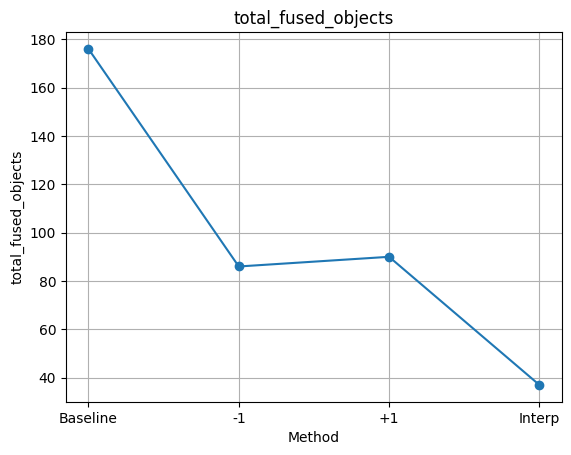

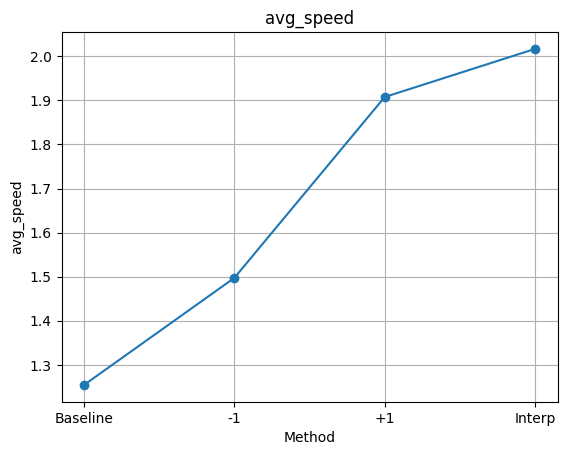

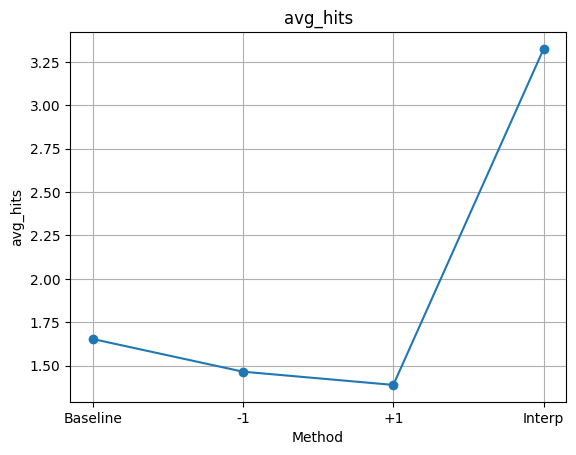

In [58]:
plot_metric(temporal_interp_results, "total_fused_objects")
plot_metric(temporal_interp_results, "avg_speed")
plot_metric(temporal_interp_results, "avg_hits")

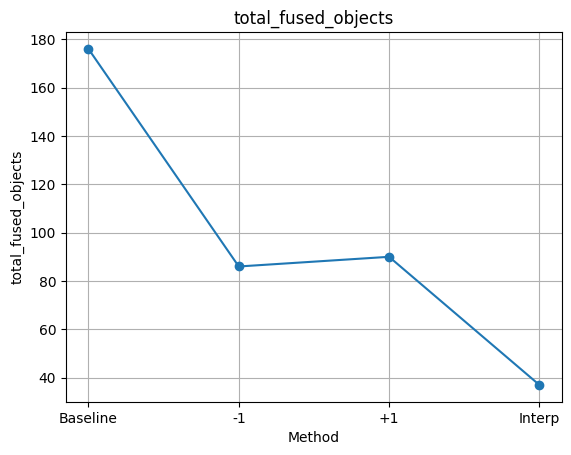

In [59]:
plot_metric(temporal_interp_results, "total_fused_objects")

# Comaprisson with Kalman (5.5)

In [60]:
# Kalman Filter New Version

import numpy as np


class SimpleKalmanFilter:
    def __init__(self, x, y, vx=0.0, vy=0.0):
        # state: [x, y, vx, vy]
        self.x = np.array([x, y, vx, vy], dtype=float)

        # covariance
        self.P = np.eye(4)

        # process noise
        self.Q = np.eye(4) * 0.1

        # measurement noise
        self.R = np.eye(4) * 0.5

        # state transition (dt = 1)
        self.F = np.array([
            [1, 0, 1, 0],
            [0, 1, 0, 1],
            [0, 0, 1, 0],
            [0, 0, 0, 1]
        ])

        # measurement model
        self.H = np.eye(4)

    def predict(self):
        self.x = self.F @ self.x
        self.P = self.F @ self.P @ self.F.T + self.Q

    def update(self, z):
        y = z - self.H @ self.x
        S = self.H @ self.P @ self.H.T + self.R
        K = self.P @ self.H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ self.H) @ self.P

In [61]:
def run_kalman_tracking(frames, dist_threshold=3.0):
    tracks = []
    next_id = 0

    for frame in frames:
        measurements = frame["objects"]

        # predict all tracks
        for track in tracks:
            track["kf"].predict()
            track["updated"] = False

        # associate measurements → nearest neighbour
        for obj in measurements:
            meas_pos = np.array(obj["position_xy"])
            meas_vel = np.array(obj["velocity_xy"])

            best_track = None
            best_dist = float("inf")

            for track in tracks:
                pred_pos = track["kf"].x[:2]
                dist = np.linalg.norm(meas_pos - pred_pos)

                if dist < best_dist and dist < dist_threshold:
                    best_dist = dist
                    best_track = track

            if best_track is not None:
                z = np.array([
                    meas_pos[0],
                    meas_pos[1],
                    meas_vel[0],
                    meas_vel[1]
                ])
                best_track["kf"].update(z)
                best_track["history"].append(best_track["kf"].x.copy())
                best_track["updated"] = True

            else:
                # create new track
                kf = SimpleKalmanFilter(
                    meas_pos[0],
                    meas_pos[1],
                    meas_vel[0],
                    meas_vel[1]
                )
                tracks.append({
                    "id": next_id,
                    "kf": kf,
                    "history": [kf.x.copy()],
                    "updated": True,
                    "missed": 0
                })
                next_id += 1

        # remove dead tracks but keep them alive for a few frames
        for track in tracks:
            if "missed" not in track:
                track["missed"] = 0

            if track["updated"]:
                track["missed"] = 0
            else:
                track["missed"] += 1

        # keep tracks for up to 3 missed frames
        tracks = [t for t in tracks if t["missed"] < 3]
        return tracks

In [62]:
def summarise_tracks(tracks):
    lengths = [len(t["history"]) for t in tracks]

    final_speeds = []
    for t in tracks:
        vx = t["history"][-1][2]
        vy = t["history"][-1][3]
        final_speeds.append(np.sqrt(vx**2 + vy**2))

    return {
        "num_tracks": len(tracks),
        "avg_track_length": float(np.mean(lengths)) if lengths else 0,
        "median_track_length": float(np.median(lengths)) if lengths else 0,
        "avg_final_speed": float(np.mean(final_speeds)) if final_speeds else 0,
        "median_final_speed": float(np.median(final_speeds)) if final_speeds else 0
    }

In [63]:
def evaluate_temporal_methods_comparison(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0
):
    # -------------------------
    # 1. BASELINE (clean)
    # -------------------------
    baseline = run_scene_weighted_measurements(
        nusc,
        scene_index,
        radar_chan,
        ref_chan,
        min_hits,
        spatial_dx,
        spatial_dy,
        0.0,
        spatial_yaw_deg,
        max_range
    )

    # -------------------------
    # 2. TEMPORAL DEGRADATION (-1)
    # -------------------------
    degraded = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index,
        radar_chan,
        ref_chan,
        min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=0.0,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # -------------------------
    # 3. INTERPOLATION
    # -------------------------
    interpolated = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index,
        radar_chan,
        ref_chan,
        min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=0.0,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # -------------------------
    # 4. KALMAN ON DEGRADED
    # -------------------------
    degraded_tracks = run_kalman_tracking(degraded)
    kalman_summary = summarise_tracks(degraded_tracks)

    # -------------------------
    # SUMMARIES
    # -------------------------
    results = {
        "baseline_measurement": summarise_results(baseline),
        "degraded_measurement": summarise_results(degraded),
        "interpolated_measurement": summarise_results(interpolated),

        "baseline_physical": compute_physical_alignment_metrics(baseline),
        "degraded_physical": compute_physical_alignment_metrics(degraded),
        "interpolated_physical": compute_physical_alignment_metrics(interpolated),

        "kalman_track_summary": kalman_summary
    }

    return results

In [64]:
comparison_results = evaluate_temporal_methods_comparison(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
)

print(comparison_results)

{'baseline_measurement': {'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}, 'degraded_measurement': {'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}, 'interpolated_measurement': {'total_frames': 37, 'total_fused_objects': 37, 'avg_hits': 3.324324324324324, 'median_hits': 3.0, 'avg_speed': 2.0168722849372, 'median_speed': 2.6253441936576745}, 'baseline_physical': {'mean_centre_distance': 1.5149704526228616, 'median_centre_distance': 1.3180430757865245, 'mean_points_per_object': 1.6534090909090908, 'median_points_per_object': 1.0}, 'degraded_physical': {'mean_centre_distance': 1.4205037363334807, 'median_centre_distance': 1.2964448159590987, 'mean_points_per_object': 1.4651162790697674, 'median_points_per_object': 1.0}, 'interpolated_physical': {'mean

In [65]:
def plot_temporal_comparison_full(results):
    import matplotlib.pyplot as plt

    labels = ["Baseline", "Degraded", "Interpolated", "Kalman"]

    obj_counts = [
        results["baseline_measurement"]["total_fused_objects"],
        results["degraded_measurement"]["total_fused_objects"],
        results["interpolated_measurement"]["total_fused_objects"],
        results["kalman_track_summary"]["num_tracks"]
    ]

    speeds = [
        results["baseline_measurement"]["avg_speed"],
        results["degraded_measurement"]["avg_speed"],
        results["interpolated_measurement"]["avg_speed"],
        results["kalman_track_summary"]["avg_final_speed"]
    ]

    plt.figure()
    plt.plot(labels, obj_counts, marker='o')
    plt.title("Objects / Tracks Comparison")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(labels, speeds, marker='o')
    plt.title("Speed Comparison")
    plt.grid()
    plt.show()

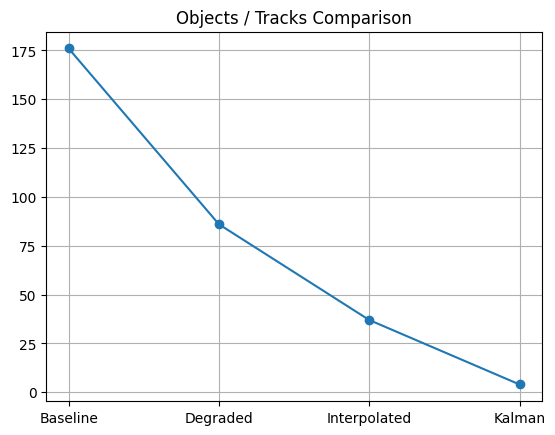

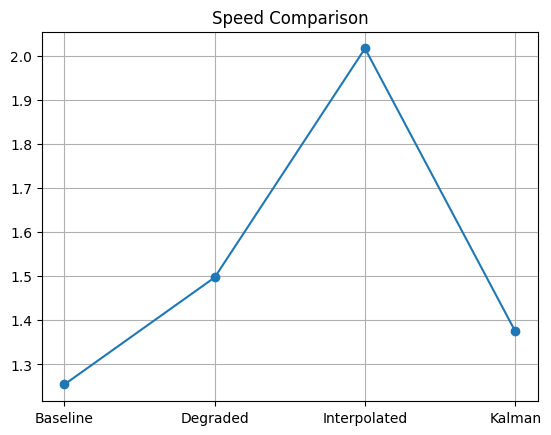

In [66]:
plot_temporal_comparison_full(comparison_results)

# Fusion (Kalman Filter) ??

In [80]:
import numpy as np
import matplotlib.pyplot as plt

from nuscenes.nuscenes import NuScenes
from nuscenes.utils.data_classes import RadarPointCloud
from nuscenes.utils.geometry_utils import points_in_box


# ==========================================
# CONFIG
# ==========================================
DATAROOT = r"data/sets/nuscenes"
VERSION = "v1.0-mini"
SCENE_INDEX = 0
RADAR_CHAN = "RADAR_FRONT"
REF_CHAN = "LIDAR_TOP"
MIN_RADAR_HITS = 1


# ==========================================
# BASIC HELPERS
# ==========================================
def get_scene_samples(nusc, scene_index=0):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    samples = []
    while token:
        sample = nusc.get("sample", token)
        samples.append(sample)
        token = sample["next"]

    return samples


def apply_spatial_transform(radar_xyz, dx=0.0, dy=0.0, dz=0.0, yaw_deg=0.0):
    """
    Apply translation + z-axis rotation to radar points already in LiDAR frame.
    radar_xyz shape: (3, N)
    """
    pts = radar_xyz.copy()

    theta = np.deg2rad(yaw_deg)
    R = np.array([
        [np.cos(theta), -np.sin(theta), 0.0],
        [np.sin(theta),  np.cos(theta), 0.0],
        [0.0,            0.0,           1.0]
    ])

    pts = R @ pts
    pts[0, :] += dx
    pts[1, :] += dy
    pts[2, :] += dz

    return pts


def compute_weighted_velocity(points_xy, radar_vel_xy, box_center_xy, eps=1e-6):
    """
    Weighted radar velocity fusion.
    Points closer to the box centre get larger weights.
    """
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)
    weights = 1.0 / (dists + eps)

    weights_sum = np.sum(weights)
    if weights_sum <= 0:
        return np.mean(radar_vel_xy, axis=0)

    v_est = np.sum(radar_vel_xy * weights[:, None], axis=0) / weights_sum
    return v_est


def summarise_results(all_frames):
    total_frames = len(all_frames)
    total_objects = sum(len(f["objects"]) for f in all_frames)

    hits = []
    speeds = []

    for frame in all_frames:
        for obj in frame["objects"]:
            hits.append(obj["radar_hits"])
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    summary = {
        "total_frames": total_frames,
        "total_fused_objects": total_objects,
        "avg_hits": float(np.mean(hits)) if hits else 0.0,
        "median_hits": float(np.median(hits)) if hits else 0.0,
        "avg_speed": float(np.mean(speeds)) if speeds else 0.0,
        "median_speed": float(np.median(speeds)) if speeds else 0.0
    }

    return summary


def compute_physical_alignment_metrics(all_frames_with_points):
    centre_dists = []
    points_per_object = []

    for frame in all_frames_with_points:
        for obj in frame["objects"]:
            box_center = np.array(obj["position_xy"])
            radar_points_xy = np.array(obj["associated_radar_points_xy"])

            if radar_points_xy.size == 0:
                continue

            dists = np.linalg.norm(radar_points_xy - box_center[None, :], axis=1)
            centre_dists.extend(dists.tolist())
            points_per_object.append(len(radar_points_xy))

    metrics = {
        "mean_centre_distance": float(np.mean(centre_dists)) if centre_dists else None,
        "median_centre_distance": float(np.median(centre_dists)) if centre_dists else None,
        "mean_points_per_object": float(np.mean(points_per_object)) if points_per_object else None,
        "median_points_per_object": float(np.median(points_per_object)) if points_per_object else None
    }

    return metrics


# ==========================================
# FRAME-LEVEL OBJECT EXTRACTION
# ==========================================
def extract_frame_measurements(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Extract object-level measurements:
      position from LiDAR GT box
      velocity from weighted radar fusion
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg
    )

    vx = rpc.points[8, :]
    vy = rpc.points[9, :]
    radar_vel = np.vstack((vx, vy))  # (2, N)

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity(
            points_xy=assoc_pts_xy,
            radar_vel_xy=assoc_vel_xy,
            box_center_xy=box_center_xy
        )

        obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        }
        objects.append(obj)

    return objects


def run_scene_weighted_measurements(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    all_frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        frame_record = {
            "sample_token": token,
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        }
        all_frames.append(frame_record)

        token = sample["next"]
        frame_idx += 1

    return all_frames


# ==========================================
# KALMAN FILTER
# ==========================================
class KalmanTrack:
    def __init__(self, track_id, x0, P0, timestamp, class_name=None):
        self.track_id = track_id
        self.x = x0.copy()   # state [x, y, vx, vy]
        self.P = P0.copy()
        self.last_timestamp = timestamp
        self.class_name = class_name
        self.age = 1
        self.missed = 0
        self.history = [x0.copy()]

    def predict(self, dt, q_pos=1.0, q_vel=1.0):
        F = np.array([
            [1.0, 0.0, dt,  0.0],
            [0.0, 1.0, 0.0, dt ],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

        Q = np.array([
            [q_pos * dt**2, 0.0,           0.0,           0.0],
            [0.0,           q_pos * dt**2, 0.0,           0.0],
            [0.0,           0.0,           q_vel * dt,    0.0],
            [0.0,           0.0,           0.0,           q_vel * dt]
        ])

        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z, R):
        # z = [x, y, vx, vy]
        H = np.eye(4)

        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        I = np.eye(4)
        self.P = (I - K @ H) @ self.P

        self.age += 1
        self.missed = 0
        self.history.append(self.x.copy())

    def mark_missed(self):
        self.missed += 1
        self.age += 1
        self.history.append(self.x.copy())


def measurement_from_object(obj):
    """
    Object measurement z = [x, y, vx, vy]
    """
    px, py = obj["position_xy"]
    vx, vy = obj["velocity_xy"]
    return np.array([px, py, vx, vy], dtype=float)


def measurement_covariance(obj, pos_var=1.0, vel_var_base=2.0):
    """
    Simple measurement covariance:
    - position variance fixed
    - velocity variance decreases slightly when more radar hits exist
    """
    hits = max(obj["radar_hits"], 1)
    vel_var = vel_var_base / hits

    R = np.diag([pos_var, pos_var, vel_var, vel_var])
    return R


def greedy_associate_tracks_to_measurements(tracks, measurements, gate_dist=3.0):
    """
    Greedy nearest-neighbour association in position space.
    Returns:
      matches: list of (track_idx, meas_idx)
      unmatched_tracks: list of track indices
      unmatched_measurements: list of measurement indices
    """
    if len(tracks) == 0 or len(measurements) == 0:
        return [], list(range(len(tracks))), list(range(len(measurements)))

    track_positions = np.array([t.x[:2] for t in tracks])
    meas_positions = np.array([m[:2] for m in measurements])

    dmat = np.linalg.norm(track_positions[:, None, :] - meas_positions[None, :, :], axis=2)

    matches = []
    used_tracks = set()
    used_meas = set()

    while True:
        best = None
        best_dist = np.inf

        for ti in range(len(tracks)):
            if ti in used_tracks:
                continue
            for mi in range(len(measurements)):
                if mi in used_meas:
                    continue
                d = dmat[ti, mi]
                if d < best_dist:
                    best_dist = d
                    best = (ti, mi)

        if best is None or best_dist > gate_dist:
            break

        ti, mi = best
        matches.append((ti, mi))
        used_tracks.add(ti)
        used_meas.add(mi)

    unmatched_tracks = [i for i in range(len(tracks)) if i not in used_tracks]
    unmatched_measurements = [i for i in range(len(measurements)) if i not in used_meas]

    return matches, unmatched_tracks, unmatched_measurements


def run_scene_kalman_tracking(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Full scene tracking:
      - object measurements from weighted LiDAR-radar fusion
      - constant-velocity Kalman filter
      - greedy nearest-neighbour data association
    """
    frames = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg,
        max_range=max_range
    )

    active_tracks = []
    finished_tracks = []
    next_track_id = 0

    tracked_frames = []

    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            # nuScenes timestamps are in microseconds
            dt = (timestamp - prev_timestamp) / 1e6

        # Predict all tracks
        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        measurements = [measurement_from_object(o) for o in objs]
        covariances = [measurement_covariance(o, pos_var=pos_var, vel_var_base=vel_var_base) for o in objs]

        matches, unmatched_tracks, unmatched_measurements = greedy_associate_tracks_to_measurements(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        # Update matched tracks
        for ti, mi in matches:
            active_tracks[ti].update(measurements[mi], covariances[mi])
            active_tracks[ti].last_timestamp = timestamp

        # Mark unmatched tracks
        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        # Create new tracks for unmatched measurements
        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = KalmanTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            next_track_id += 1
            active_tracks.append(tr)

        # Move dead tracks to finished
        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        frame_tracks = []
        for tr in active_tracks:
            frame_tracks.append({
                "track_id": tr.track_id,
                "state": tr.x.copy(),
                "class_name": tr.class_name,
                "missed": tr.missed
            })

        tracked_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "objects": objs,
            "tracks": frame_tracks
        })

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return tracked_frames, finished_tracks


# ==========================================
# TRACK SUMMARY
# ==========================================
def summarise_tracks(finished_tracks):
    track_lengths = [len(tr.history) for tr in finished_tracks]
    final_speeds = [np.linalg.norm(tr.x[2:4]) for tr in finished_tracks]

    summary = {
        "num_tracks": len(finished_tracks),
        "avg_track_length": float(np.mean(track_lengths)) if track_lengths else 0.0,
        "median_track_length": float(np.median(track_lengths)) if track_lengths else 0.0,
        "avg_final_speed": float(np.mean(final_speeds)) if final_speeds else 0.0,
        "median_final_speed": float(np.median(final_speeds)) if final_speeds else 0.0
    }

    return summary


# ==========================================
# KALMAN RECOVERY EVALUATION
# ==========================================
def evaluate_kalman_recovery_cases(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    degrade_dx=0.0,
    degrade_dy=0.0,
    degrade_yaw_deg=0.0,
    estimated_dx=0.0,
    estimated_dy=0.0,
    estimated_yaw_deg=0.0,
    true_dx=0.0,
    true_dy=0.0,
    true_yaw_deg=0.0,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    baseline_frames, baseline_tracks = run_scene_kalman_tracking(
        nusc, scene_index, radar_chan, ref_chan, min_hits,
        dx=0.0, dy=0.0, yaw_deg=0.0,
        max_range=max_range, gate_dist=gate_dist, max_missed=max_missed,
        pos_var=pos_var, vel_var_base=vel_var_base, q_pos=q_pos, q_vel=q_vel
    )

    degraded_frames, degraded_tracks = run_scene_kalman_tracking(
        nusc, scene_index, radar_chan, ref_chan, min_hits,
        dx=degrade_dx, dy=degrade_dy, yaw_deg=degrade_yaw_deg,
        max_range=max_range, gate_dist=gate_dist, max_missed=max_missed,
        pos_var=pos_var, vel_var_base=vel_var_base, q_pos=q_pos, q_vel=q_vel
    )

    estimated_frames, estimated_tracks = run_scene_kalman_tracking(
        nusc, scene_index, radar_chan, ref_chan, min_hits,
        dx=degrade_dx + estimated_dx,
        dy=degrade_dy + estimated_dy,
        yaw_deg=degrade_yaw_deg + estimated_yaw_deg,
        max_range=max_range, gate_dist=gate_dist, max_missed=max_missed,
        pos_var=pos_var, vel_var_base=vel_var_base, q_pos=q_pos, q_vel=q_vel
    )

    true_frames, true_tracks = run_scene_kalman_tracking(
        nusc, scene_index, radar_chan, ref_chan, min_hits,
        dx=degrade_dx + true_dx,
        dy=degrade_dy + true_dy,
        yaw_deg=degrade_yaw_deg + true_yaw_deg,
        max_range=max_range, gate_dist=gate_dist, max_missed=max_missed,
        pos_var=pos_var, vel_var_base=vel_var_base, q_pos=q_pos, q_vel=q_vel
    )

    return {
        "baseline_measurement_summary": summarise_results(
            [{"objects": f["objects"]} for f in baseline_frames]
        ),
        "degraded_measurement_summary": summarise_results(
            [{"objects": f["objects"]} for f in degraded_frames]
        ),
        "estimated_measurement_summary": summarise_results(
            [{"objects": f["objects"]} for f in estimated_frames]
        ),
        "true_measurement_summary": summarise_results(
            [{"objects": f["objects"]} for f in true_frames]
        ),

        "baseline_track_summary": summarise_tracks(baseline_tracks),
        "degraded_track_summary": summarise_tracks(degraded_tracks),
        "estimated_track_summary": summarise_tracks(estimated_tracks),
        "true_track_summary": summarise_tracks(true_tracks),

        "baseline_physical": compute_physical_alignment_metrics(
            [{"objects": f["objects"]} for f in baseline_frames]
        ),
        "degraded_physical": compute_physical_alignment_metrics(
            [{"objects": f["objects"]} for f in degraded_frames]
        ),
        "estimated_physical": compute_physical_alignment_metrics(
            [{"objects": f["objects"]} for f in estimated_frames]
        ),
        "true_physical": compute_physical_alignment_metrics(
            [{"objects": f["objects"]} for f in true_frames]
        )
    }


# ==========================================
# OPTIONAL VISUALISATION OF TRACKS
# ==========================================
def plot_track_histories(finished_tracks, max_tracks=10):
    plt.figure(figsize=(8, 8))

    for tr in finished_tracks[:max_tracks]:
        hist = np.array(tr.history)
        if len(hist) == 0:
            continue
        plt.plot(hist[:, 0], hist[:, 1], marker="o", label=f"Track {tr.track_id}")

    plt.xlabel("X")
    plt.ylabel("Y")
    plt.title("Kalman track histories")
    plt.axis("equal")
    plt.grid(True)
    plt.legend()
    plt.show()

In [81]:
def run_kalman_tracking_on_frames(
    frames,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Same Kalman tracking logic as run_scene_kalman_tracking,
    but operates on precomputed frame measurements.

    Each frame must contain:
      - frame_index
      - timestamp
      - objects
    """
    active_tracks = []
    finished_tracks = []
    next_track_id = 0

    tracked_frames = []
    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            dt = (timestamp - prev_timestamp) / 1e6

        # Predict all active tracks
        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        measurements = [measurement_from_object(o) for o in objs]
        covariances = [
            measurement_covariance(o, pos_var=pos_var, vel_var_base=vel_var_base)
            for o in objs
        ]

        matches, unmatched_tracks, unmatched_measurements = greedy_associate_tracks_to_measurements(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        # Update matched tracks
        for ti, mi in matches:
            active_tracks[ti].update(measurements[mi], covariances[mi])
            active_tracks[ti].last_timestamp = timestamp

        # Mark unmatched tracks
        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        # Create new tracks for unmatched measurements
        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = KalmanTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            next_track_id += 1
            active_tracks.append(tr)

        # Move dead tracks to finished
        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        frame_tracks = []
        for tr in active_tracks:
            frame_tracks.append({
                "track_id": tr.track_id,
                "state": tr.x.copy(),
                "class_name": tr.class_name,
                "missed": tr.missed
            })

        tracked_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "objects": objs,
            "tracks": frame_tracks
        })

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return tracked_frames, finished_tracks

In [82]:
def summarise_tracks(finished_tracks):
    track_lengths = [len(tr.history) for tr in finished_tracks]
    final_speeds = [np.linalg.norm(tr.x[2:4]) for tr in finished_tracks]

    summary = {
        "num_tracks": len(finished_tracks),
        "avg_track_length": float(np.mean(track_lengths)) if track_lengths else 0.0,
        "median_track_length": float(np.median(track_lengths)) if track_lengths else 0.0,
        "avg_final_speed": float(np.mean(final_speeds)) if final_speeds else 0.0,
        "median_final_speed": float(np.median(final_speeds)) if final_speeds else 0.0
    }

    return summary

In [83]:
def evaluate_temporal_methods_with_full_kalman(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_dz=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Compare baseline / degraded / interpolated measurements
    and then run the full working Kalman tracker on each.
    """
    # 1. Baseline measurements
    baseline_frames = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # 2. Temporal degraded (-1 frame)
    degraded_frames = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # 3. Interpolated frames
    interpolated_frames = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # Kalman on each
    baseline_tracked, baseline_tracks = run_kalman_tracking_on_frames(
        baseline_frames,
        gate_dist=gate_dist,
        max_missed=max_missed,
        pos_var=pos_var,
        vel_var_base=vel_var_base,
        q_pos=q_pos,
        q_vel=q_vel
    )

    degraded_tracked, degraded_tracks = run_kalman_tracking_on_frames(
        degraded_frames,
        gate_dist=gate_dist,
        max_missed=max_missed,
        pos_var=pos_var,
        vel_var_base=vel_var_base,
        q_pos=q_pos,
        q_vel=q_vel
    )

    interpolated_tracked, interpolated_tracks = run_kalman_tracking_on_frames(
        interpolated_frames,
        gate_dist=gate_dist,
        max_missed=max_missed,
        pos_var=pos_var,
        vel_var_base=vel_var_base,
        q_pos=q_pos,
        q_vel=q_vel
    )

    return {
        "baseline_measurement_summary": summarise_results(baseline_frames),
        "degraded_measurement_summary": summarise_results(degraded_frames),
        "interpolated_measurement_summary": summarise_results(interpolated_frames),

        "baseline_physical": compute_physical_alignment_metrics(baseline_frames),
        "degraded_physical": compute_physical_alignment_metrics(degraded_frames),
        "interpolated_physical": compute_physical_alignment_metrics(interpolated_frames),

        "baseline_track_summary": summarise_tracks(baseline_tracks),
        "degraded_track_summary": summarise_tracks(degraded_tracks),
        "interpolated_track_summary": summarise_tracks(interpolated_tracks),

        "baseline_tracks_obj": baseline_tracks,
        "degraded_tracks_obj": degraded_tracks,
        "interpolated_tracks_obj": interpolated_tracks,
    }

In [84]:
temporal_kalman_comparison = evaluate_temporal_methods_with_full_kalman(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
)

print(temporal_kalman_comparison["baseline_track_summary"])
print(temporal_kalman_comparison["degraded_track_summary"])
print(temporal_kalman_comparison["interpolated_track_summary"])

{'num_tracks': 73, 'avg_track_length': 5.890410958904109, 'median_track_length': 5.0, 'avg_final_speed': 1.0949542623333506, 'median_final_speed': 0.17957793939324393}
{'num_tracks': 41, 'avg_track_length': 5.585365853658536, 'median_track_length': 5.0, 'avg_final_speed': 1.0169054379805818, 'median_final_speed': 0.40024443471645554}
{'num_tracks': 18, 'avg_track_length': 5.055555555555555, 'median_track_length': 4.0, 'avg_final_speed': 1.2922287083909108, 'median_final_speed': 0.23808948775054778}


In [85]:
import pandas as pd

temporal_track_df = pd.DataFrame([
    {"Method": "Baseline", **temporal_kalman_comparison["baseline_track_summary"]},
    {"Method": "Degraded", **temporal_kalman_comparison["degraded_track_summary"]},
    {"Method": "Interpolation", **temporal_kalman_comparison["interpolated_track_summary"]},
])

display(temporal_track_df.round(3))

,Method,num_tracks,avg_track_length,median_track_length,avg_final_speed,median_final_speed
0,Baseline,73,5.890,5.0,1.095,0.180
1,Degraded,41,5.585,5.0,1.017,0.400
2,Interpolation,18,5.056,4.0,1.292,0.238


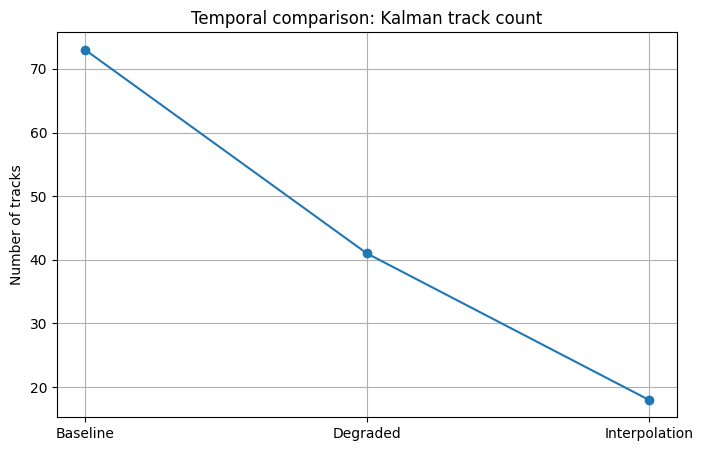

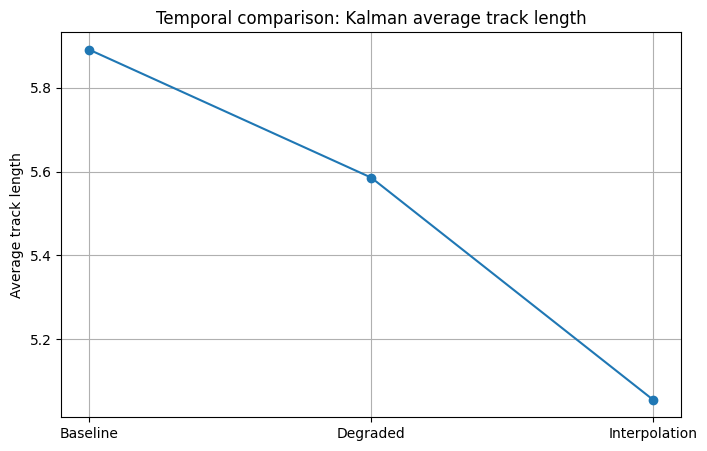

In [86]:
labels = ["Baseline", "Degraded", "Interpolation"]
num_tracks = [
    temporal_kalman_comparison["baseline_track_summary"]["num_tracks"],
    temporal_kalman_comparison["degraded_track_summary"]["num_tracks"],
    temporal_kalman_comparison["interpolated_track_summary"]["num_tracks"]
]
avg_lengths = [
    temporal_kalman_comparison["baseline_track_summary"]["avg_track_length"],
    temporal_kalman_comparison["degraded_track_summary"]["avg_track_length"],
    temporal_kalman_comparison["interpolated_track_summary"]["avg_track_length"]
]

plt.figure(figsize=(8,5))
plt.plot(labels, num_tracks, marker="o")
plt.ylabel("Number of tracks")
plt.title("Temporal comparison: Kalman track count")
plt.grid(True)
plt.show()

plt.figure(figsize=(8,5))
plt.plot(labels, avg_lengths, marker="o")
plt.ylabel("Average track length")
plt.title("Temporal comparison: Kalman average track length")
plt.grid(True)
plt.show()

# Multi Frame (5.5)

In [97]:
def motion_compensate_radar_points(radar_xyz, radar_vel, dt_sec):
    """
    Motion compensate radar points in the xy plane using radar velocity.

    radar_xyz: (3, N)
    radar_vel: (2, N)
    dt_sec: scalar time offset from radar timestamp to target LiDAR timestamp

    Returns:
        compensated radar_xyz copy
    """
    compensated = radar_xyz.copy()
    compensated[0, :] = compensated[0, :] + radar_vel[0, :] * dt_sec
    compensated[1, :] = compensated[1, :] + radar_vel[1, :] * dt_sec
    return compensated


def extract_frame_measurements_motion_compensated(
    nusc,
    lidar_sample,
    radar_sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Use LiDAR boxes from lidar_sample.
    Use radar from radar_sample.
    First motion-compensate radar points to the LiDAR timestamp using radar velocity.
    Then perform object-level fusion.
    """
    lidar_sd = nusc.get("sample_data", lidar_sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        radar_sample,
        radar_chan,
        ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_vel = np.vstack((rpc.points[8, :], rpc.points[9, :]))  # (2, N)

    # Optional spatial degradation if you still want to combine effects
    radar_xyz = apply_spatial_transform(
        radar_xyz,
        dx=dx,
        dy=dy,
        dz=dz,
        yaw_deg=yaw_deg
    )

    # Time difference: move radar points to lidar time
    t_radar = radar_sample["timestamp"]
    t_lidar = lidar_sample["timestamp"]
    dt_sec = (t_lidar - t_radar) / 1e6

    radar_xyz_mc = motion_compensate_radar_points(radar_xyz, radar_vel, dt_sec)

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz_mc)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz_mc[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity(
            points_xy=assoc_pts_xy,
            radar_vel_xy=assoc_vel_xy,
            box_center_xy=box_center_xy
        )

        obj = {
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        }
        objects.append(obj)

    return objects


def run_scene_motion_compensated_temporal(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    frame_offset=-1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Temporal degradation + motion compensation.

    LiDAR boxes come from frame i.
    Radar comes from frame i + frame_offset.
    Radar points are motion compensated to the LiDAR timestamp before fusion.
    """
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    for i, lidar_sample in enumerate(samples):
        radar_idx = i + frame_offset
        if radar_idx < 0 or radar_idx >= len(samples):
            continue

        radar_sample = samples[radar_idx]

        objects = extract_frame_measurements_motion_compensated(
            nusc,
            lidar_sample=lidar_sample,
            radar_sample=radar_sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        all_frames.append({
            "frame_index": i,
            "radar_frame_index": radar_idx,
            "sample_token": lidar_sample["token"],
            "timestamp": lidar_sample["timestamp"],
            "objects": objects
        })

    return all_frames


def evaluate_motion_compensation_recovery(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_dz=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0
):
    """
    Compare:
    1. baseline
    2. degraded temporal (-1)
    3. motion-compensated temporal (-1)
    4. naive interpolation
    """
    baseline_frames = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    degraded_frames = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    motion_comp_frames = run_scene_motion_compensated_temporal(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    naive_interp_frames = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    return {
        "baseline_summary": summarise_results(baseline_frames),
        "degraded_summary": summarise_results(degraded_frames),
        "motion_comp_summary": summarise_results(motion_comp_frames),
        "naive_interp_summary": summarise_results(naive_interp_frames),

        "baseline_physical": compute_physical_alignment_metrics(baseline_frames),
        "degraded_physical": compute_physical_alignment_metrics(degraded_frames),
        "motion_comp_physical": compute_physical_alignment_metrics(motion_comp_frames),
        "naive_interp_physical": compute_physical_alignment_metrics(naive_interp_frames),

        "baseline_frames": baseline_frames,
        "degraded_frames": degraded_frames,
        "motion_comp_frames": motion_comp_frames,
        "naive_interp_frames": naive_interp_frames
    }

In [98]:
def run_kalman_predicted_state_recovery_on_frames(
    frames,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Run Kalman tracking on precomputed frames.
    Save predicted states BEFORE update as temporally compensated states.
    """
    active_tracks = []
    finished_tracks = []
    next_track_id = 0

    predicted_frames = []
    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            dt = (timestamp - prev_timestamp) / 1e6

        # Predict active tracks to current time
        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        # Save predicted states BEFORE measurement update
        predicted_tracks_snapshot = []
        for tr in active_tracks:
            predicted_tracks_snapshot.append({
                "track_id": tr.track_id,
                "state": tr.x.copy(),   # [x, y, vx, vy]
                "class_name": tr.class_name,
                "missed": tr.missed
            })

        predicted_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "predicted_tracks": predicted_tracks_snapshot
        })

        # Build measurements from current degraded frame
        measurements = [measurement_from_object(o) for o in objs]
        covariances = [
            measurement_covariance(o, pos_var=pos_var, vel_var_base=vel_var_base)
            for o in objs
        ]

        # Associate predicted tracks to current measurements
        matches, unmatched_tracks, unmatched_measurements = greedy_associate_tracks_to_measurements(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        # Update matched tracks
        for ti, mi in matches:
            active_tracks[ti].update(measurements[mi], covariances[mi])
            active_tracks[ti].last_timestamp = timestamp

        # Mark unmatched tracks
        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        # Create new tracks for unmatched measurements
        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = KalmanTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            next_track_id += 1
            active_tracks.append(tr)

        # Remove dead tracks
        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return predicted_frames, finished_tracks


def predicted_frames_to_object_frames(predicted_frames):
    """
    Convert predicted-track frames into object-like frames
    so we can summarise them like measurement outputs.
    """
    out = []

    for frame in predicted_frames:
        objs = []
        for tr in frame["predicted_tracks"]:
            x, y, vx, vy = tr["state"]

            objs.append({
                "box_index": tr["track_id"],
                "box_name": tr["class_name"] if tr["class_name"] is not None else "track",
                "position_xy": np.array([x, y], dtype=float),
                "velocity_xy": np.array([vx, vy], dtype=float),
                "radar_hits": 0,
                "associated_radar_points_xy": []
            })

        out.append({
            "frame_index": frame["frame_index"],
            "timestamp": frame["timestamp"],
            "objects": objs
        })

    return out


def summarise_object_like_frames(object_frames):
    total_frames = len(object_frames)
    total_objects = sum(len(f["objects"]) for f in object_frames)

    speeds = []
    for frame in object_frames:
        for obj in frame["objects"]:
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    return {
        "total_frames": total_frames,
        "total_objects": total_objects,
        "objects_per_frame": (total_objects / total_frames) if total_frames > 0 else 0.0,
        "avg_speed": float(np.mean(speeds)) if speeds else 0.0,
        "median_speed": float(np.median(speeds)) if speeds else 0.0
    }


def evaluate_kalman_motion_compensation(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_dz=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Compare:
    1. Baseline
    2. Degraded temporal
    3. Raw motion compensation
    4. Naive interpolation
    5. Kalman-based motion compensation (predicted states on degraded sequence)
    """

    baseline_frames = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    degraded_frames = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    raw_motion_comp_frames = run_scene_motion_compensated_temporal(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    naive_interp_frames = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # Kalman-based motion compensation on degraded frames
    pred_frames, pred_tracks = run_kalman_predicted_state_recovery_on_frames(
        degraded_frames,
        gate_dist=gate_dist,
        max_missed=max_missed,
        pos_var=pos_var,
        vel_var_base=vel_var_base,
        q_pos=q_pos,
        q_vel=q_vel
    )
    pred_object_frames = predicted_frames_to_object_frames(pred_frames)

    return {
        "baseline_summary": summarise_results(baseline_frames),
        "degraded_summary": summarise_results(degraded_frames),
        "raw_motion_comp_summary": summarise_results(raw_motion_comp_frames),
        "naive_interp_summary": summarise_results(naive_interp_frames),
        "kalman_motion_comp_summary": summarise_object_like_frames(pred_object_frames),

        "baseline_physical": compute_physical_alignment_metrics(baseline_frames),
        "degraded_physical": compute_physical_alignment_metrics(degraded_frames),
        "raw_motion_comp_physical": compute_physical_alignment_metrics(raw_motion_comp_frames),
        "naive_interp_physical": compute_physical_alignment_metrics(naive_interp_frames),

        "kalman_motion_comp_track_summary": summarise_tracks(pred_tracks),

        "pred_frames": pred_frames,
        "pred_tracks": pred_tracks,
        "pred_object_frames": pred_object_frames
    }

In [99]:
def display_kalman_motion_comp_table(results):
    df = pd.DataFrame([
        {
            "Method": "Baseline",
            "Frames": results["baseline_summary"]["total_frames"],
            "Objects / states": results["baseline_summary"]["total_fused_objects"],
            "Per frame": results["baseline_summary"]["total_fused_objects"] / results["baseline_summary"]["total_frames"],
            "Avg speed": results["baseline_summary"]["avg_speed"],
        },
        {
            "Method": "Degraded (-1)",
            "Frames": results["degraded_summary"]["total_frames"],
            "Objects / states": results["degraded_summary"]["total_fused_objects"],
            "Per frame": results["degraded_summary"]["total_fused_objects"] / results["degraded_summary"]["total_frames"],
            "Avg speed": results["degraded_summary"]["avg_speed"],
        },
        {
            "Method": "Raw motion comp",
            "Frames": results["raw_motion_comp_summary"]["total_frames"],
            "Objects / states": results["raw_motion_comp_summary"]["total_fused_objects"],
            "Per frame": results["raw_motion_comp_summary"]["total_fused_objects"] / results["raw_motion_comp_summary"]["total_frames"],
            "Avg speed": results["raw_motion_comp_summary"]["avg_speed"],
        },
        {
            "Method": "Naive interpolation",
            "Frames": results["naive_interp_summary"]["total_frames"],
            "Objects / states": results["naive_interp_summary"]["total_fused_objects"],
            "Per frame": results["naive_interp_summary"]["total_fused_objects"] / results["naive_interp_summary"]["total_frames"],
            "Avg speed": results["naive_interp_summary"]["avg_speed"],
        },
        {
            "Method": "Kalman motion comp",
            "Frames": results["kalman_motion_comp_summary"]["total_frames"],
            "Objects / states": results["kalman_motion_comp_summary"]["total_objects"],
            "Per frame": results["kalman_motion_comp_summary"]["objects_per_frame"],
            "Avg speed": results["kalman_motion_comp_summary"]["avg_speed"],
        },
    ])

    display(df.round(3))


def plot_kalman_motion_comp_results(results):
    labels = [
        "Baseline",
        "Degraded",
        "Raw MC",
        "Naive Interp",
        "Kalman MC"
    ]

    counts = [
        results["baseline_summary"]["total_fused_objects"] / results["baseline_summary"]["total_frames"],
        results["degraded_summary"]["total_fused_objects"] / results["degraded_summary"]["total_frames"],
        results["raw_motion_comp_summary"]["total_fused_objects"] / results["raw_motion_comp_summary"]["total_frames"],
        results["naive_interp_summary"]["total_fused_objects"] / results["naive_interp_summary"]["total_frames"],
        results["kalman_motion_comp_summary"]["objects_per_frame"],
    ]

    speeds = [
        results["baseline_summary"]["avg_speed"],
        results["degraded_summary"]["avg_speed"],
        results["raw_motion_comp_summary"]["avg_speed"],
        results["naive_interp_summary"]["avg_speed"],
        results["kalman_motion_comp_summary"]["avg_speed"],
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(labels, counts, marker="o")
    plt.ylabel("Objects / states per frame")
    plt.title("Temporal recovery comparison")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(labels, speeds, marker="o")
    plt.ylabel("Average speed")
    plt.title("Temporal recovery: average speed")
    plt.grid(True)
    plt.show()

In [100]:
def run_scene_motion_compensated_temporal(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    frame_offset=-1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    """
    Temporal degradation + motion compensation.

    LiDAR boxes come from frame i.
    Radar comes from frame i + frame_offset.
    Radar points are motion compensated to the LiDAR timestamp before fusion.
    """
    samples = get_scene_samples(nusc, scene_index)
    all_frames = []

    for i, lidar_sample in enumerate(samples):
        radar_idx = i + frame_offset
        if radar_idx < 0 or radar_idx >= len(samples):
            continue

        radar_sample = samples[radar_idx]

        objects = extract_frame_measurements_motion_compensated(
            nusc,
            lidar_sample=lidar_sample,
            radar_sample=radar_sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            dx=dx,
            dy=dy,
            dz=dz,
            yaw_deg=yaw_deg,
            max_range=max_range
        )

        all_frames.append({
            "frame_index": i,
            "radar_frame_index": radar_idx,
            "sample_token": lidar_sample["token"],
            "timestamp": lidar_sample["timestamp"],
            "objects": objects
        })

    return all_frames


,Method,Frames,Objects / states,Per frame,Avg speed
0,Baseline,39,176,4.513,1.254
1,Degraded (-1),38,86,2.263,1.497
2,Raw motion comp,38,66,1.737,1.146
3,Naive interpolation,37,37,1.000,2.017
4,Kalman motion comp,38,188,4.947,1.164


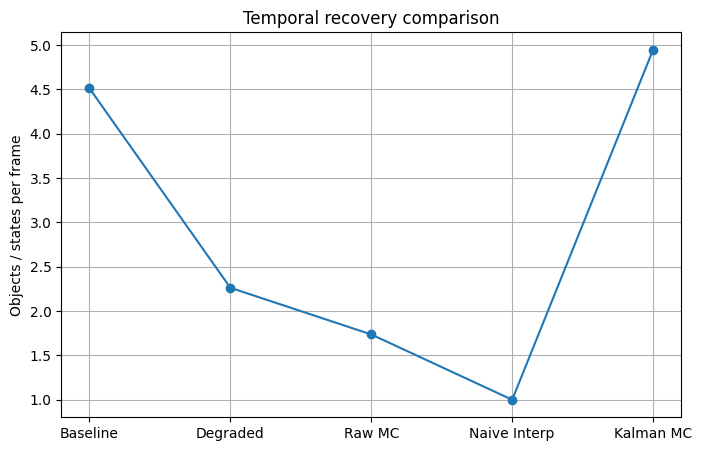

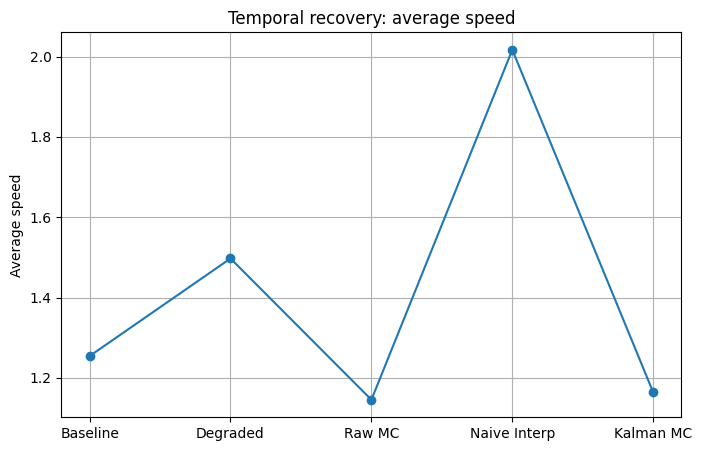

{'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}
{'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}
{'total_frames': 38, 'total_fused_objects': 66, 'avg_hits': 1.4848484848484849, 'median_hits': 1.0, 'avg_speed': 1.145501558222496, 'median_speed': 0.11158523658020437}
{'total_frames': 37, 'total_fused_objects': 37, 'avg_hits': 3.324324324324324, 'median_hits': 3.0, 'avg_speed': 2.0168722849372, 'median_speed': 2.6253441936576745}
{'total_frames': 38, 'total_objects': 188, 'objects_per_frame': 4.947368421052632, 'avg_speed': 1.1639218448488429, 'median_speed': 0.4342146480944233}
{'num_tracks': 41, 'avg_track_length': 5.585365853658536, 'median_track_length': 5.0, 'avg_final_speed': 1.0169054379805818, 'median_final_speed': 0.40024443471645554}


In [101]:
kalman_mc_results = evaluate_kalman_motion_compensation(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
)

display_kalman_motion_comp_table(kalman_mc_results)
plot_kalman_motion_comp_results(kalman_mc_results)

print(kalman_mc_results["baseline_summary"])
print(kalman_mc_results["degraded_summary"])
print(kalman_mc_results["raw_motion_comp_summary"])
print(kalman_mc_results["naive_interp_summary"])
print(kalman_mc_results["kalman_motion_comp_summary"])
print(kalman_mc_results["kalman_motion_comp_track_summary"])

| Method | Objects/frame | Total objects | Avg speed |
| --- | --- | --- | --- |
| Baseline | 4.51 | 176 | 1.25 |
| Degraded | 2.26 | 86 | 1.50 |
| Multiframe | 5.59 | 218 | 1.22 |


# upgraded: Weighted Velocity

In [121]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def run_kalman_predicted_state_recovery_on_frames(
    frames,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Run Kalman tracking on precomputed frames.
    Save predicted states BEFORE update as temporally compensated states.
    """
    active_tracks = []
    finished_tracks = []
    next_track_id = 0

    predicted_frames = []
    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            dt = (timestamp - prev_timestamp) / 1e6

        # Predict active tracks to current time
        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        # Save predicted states BEFORE measurement update
        predicted_tracks_snapshot = []
        for tr in active_tracks:
            predicted_tracks_snapshot.append({
                "track_id": tr.track_id,
                "state": tr.x.copy(),   # [x, y, vx, vy]
                "class_name": tr.class_name,
                "missed": tr.missed
            })

        predicted_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "predicted_tracks": predicted_tracks_snapshot
        })

        # Build measurements from current degraded frame
        measurements = [measurement_from_object(o) for o in objs]
        covariances = [
            measurement_covariance(o, pos_var=pos_var, vel_var_base=vel_var_base)
            for o in objs
        ]

        # Associate predicted tracks to current measurements
        matches, unmatched_tracks, unmatched_measurements = greedy_associate_tracks_to_measurements(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        # Update matched tracks
        for ti, mi in matches:
            active_tracks[ti].update(measurements[mi], covariances[mi])
            active_tracks[ti].last_timestamp = timestamp

        # Mark unmatched tracks
        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        # Create new tracks for unmatched measurements
        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = KalmanTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            next_track_id += 1
            active_tracks.append(tr)

        # Remove dead tracks
        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return predicted_frames, finished_tracks


def predicted_frames_to_object_frames(predicted_frames):
    """
    Convert predicted-track frames into object-like frames
    so we can summarise them like measurement outputs.
    """
    out = []

    for frame in predicted_frames:
        objs = []
        for tr in frame["predicted_tracks"]:
            x, y, vx, vy = tr["state"]

            objs.append({
                "box_index": tr["track_id"],
                "box_name": tr["class_name"] if tr["class_name"] is not None else "track",
                "position_xy": np.array([x, y], dtype=float),
                "velocity_xy": np.array([vx, vy], dtype=float),
                "radar_hits": 0,
                "associated_radar_points_xy": []
            })

        out.append({
            "frame_index": frame["frame_index"],
            "timestamp": frame["timestamp"],
            "objects": objs
        })

    return out


def summarise_object_like_frames(object_frames):
    total_frames = len(object_frames)
    total_objects = sum(len(f["objects"]) for f in object_frames)

    speeds = []
    for frame in object_frames:
        for obj in frame["objects"]:
            vx, vy = obj["velocity_xy"]
            speeds.append(np.sqrt(vx**2 + vy**2))

    return {
        "total_frames": total_frames,
        "total_objects": total_objects,
        "objects_per_frame": (total_objects / total_frames) if total_frames > 0 else 0.0,
        "avg_speed": float(np.mean(speeds)) if speeds else 0.0,
        "median_speed": float(np.median(speeds)) if speeds else 0.0
    }


def evaluate_kalman_motion_compensation(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    spatial_dx=0.0,
    spatial_dy=0.0,
    spatial_dz=0.0,
    spatial_yaw_deg=0.0,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Compare:
    1. Baseline
    2. Degraded temporal
    3. Raw motion compensation
    4. Naive interpolation
    5. Kalman-based motion compensation (predicted states on degraded sequence)
    """

    baseline_frames = run_scene_weighted_measurements(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    degraded_frames = run_scene_with_temporal_offset_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    raw_motion_comp_frames = run_scene_motion_compensated_temporal(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        frame_offset=-1,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    naive_interp_frames = run_scene_temporal_interpolation_weighted(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        dx=spatial_dx,
        dy=spatial_dy,
        dz=spatial_dz,
        yaw_deg=spatial_yaw_deg,
        max_range=max_range
    )

    # Kalman-based motion compensation on degraded frames
    pred_frames, pred_tracks = run_kalman_predicted_state_recovery_on_frames(
        degraded_frames,
        gate_dist=gate_dist,
        max_missed=max_missed,
        pos_var=pos_var,
        vel_var_base=vel_var_base,
        q_pos=q_pos,
        q_vel=q_vel
    )
    pred_object_frames = predicted_frames_to_object_frames(pred_frames)

    return {
        "baseline_summary": summarise_results(baseline_frames),
        "degraded_summary": summarise_results(degraded_frames),
        "raw_motion_comp_summary": summarise_results(raw_motion_comp_frames),
        "naive_interp_summary": summarise_results(naive_interp_frames),
        "kalman_motion_comp_summary": summarise_object_like_frames(pred_object_frames),

        "baseline_physical": compute_physical_alignment_metrics(baseline_frames),
        "degraded_physical": compute_physical_alignment_metrics(degraded_frames),
        "raw_motion_comp_physical": compute_physical_alignment_metrics(raw_motion_comp_frames),
        "naive_interp_physical": compute_physical_alignment_metrics(naive_interp_frames),

        "kalman_motion_comp_track_summary": summarise_tracks(pred_tracks),

        "pred_frames": pred_frames,
        "pred_tracks": pred_tracks,
        "pred_object_frames": pred_object_frames
    }

In [122]:
def display_kalman_motion_comp_table(results):
    df = pd.DataFrame([
        {
            "Method": "Baseline",
            "Frames": results["baseline_summary"]["total_frames"],
            "Objects / states": results["baseline_summary"]["total_fused_objects"],
            "Per frame": results["baseline_summary"]["total_fused_objects"] / results["baseline_summary"]["total_frames"],
            "Avg speed": results["baseline_summary"]["avg_speed"],
        },
        {
            "Method": "Degraded (-1)",
            "Frames": results["degraded_summary"]["total_frames"],
            "Objects / states": results["degraded_summary"]["total_fused_objects"],
            "Per frame": results["degraded_summary"]["total_fused_objects"] / results["degraded_summary"]["total_frames"],
            "Avg speed": results["degraded_summary"]["avg_speed"],
        },
        {
            "Method": "Raw motion comp",
            "Frames": results["raw_motion_comp_summary"]["total_frames"],
            "Objects / states": results["raw_motion_comp_summary"]["total_fused_objects"],
            "Per frame": results["raw_motion_comp_summary"]["total_fused_objects"] / results["raw_motion_comp_summary"]["total_frames"],
            "Avg speed": results["raw_motion_comp_summary"]["avg_speed"],
        },
        {
            "Method": "Naive interpolation",
            "Frames": results["naive_interp_summary"]["total_frames"],
            "Objects / states": results["naive_interp_summary"]["total_fused_objects"],
            "Per frame": results["naive_interp_summary"]["total_fused_objects"] / results["naive_interp_summary"]["total_frames"],
            "Avg speed": results["naive_interp_summary"]["avg_speed"],
        },
        {
            "Method": "Kalman motion comp",
            "Frames": results["kalman_motion_comp_summary"]["total_frames"],
            "Objects / states": results["kalman_motion_comp_summary"]["total_objects"],
            "Per frame": results["kalman_motion_comp_summary"]["objects_per_frame"],
            "Avg speed": results["kalman_motion_comp_summary"]["avg_speed"],
        },
    ])

    display(df.round(3))


def plot_kalman_motion_comp_results(results):
    labels = [
        "Baseline",
        "Degraded",
        "Raw MC",
        "Naive Interp",
        "Kalman MC"
    ]

    counts = [
        results["baseline_summary"]["total_fused_objects"] / results["baseline_summary"]["total_frames"],
        results["degraded_summary"]["total_fused_objects"] / results["degraded_summary"]["total_frames"],
        results["raw_motion_comp_summary"]["total_fused_objects"] / results["raw_motion_comp_summary"]["total_frames"],
        results["naive_interp_summary"]["total_fused_objects"] / results["naive_interp_summary"]["total_frames"],
        results["kalman_motion_comp_summary"]["objects_per_frame"],
    ]

    speeds = [
        results["baseline_summary"]["avg_speed"],
        results["degraded_summary"]["avg_speed"],
        results["raw_motion_comp_summary"]["avg_speed"],
        results["naive_interp_summary"]["avg_speed"],
        results["kalman_motion_comp_summary"]["avg_speed"],
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(labels, counts, marker="o")
    plt.ylabel("Objects / states per frame")
    plt.title("Temporal recovery comparison")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(labels, speeds, marker="o")
    plt.ylabel("Average speed")
    plt.title("Temporal recovery: average speed")
    plt.grid(True)
    plt.show()

,Method,Frames,Objects / states,Per frame,Avg speed
0,Baseline,39,176,4.513,1.254
1,Degraded (-1),38,86,2.263,1.497
2,Raw motion comp,38,66,1.737,1.146
3,Naive interpolation,37,37,1.000,2.017
4,Kalman motion comp,38,188,4.947,1.164


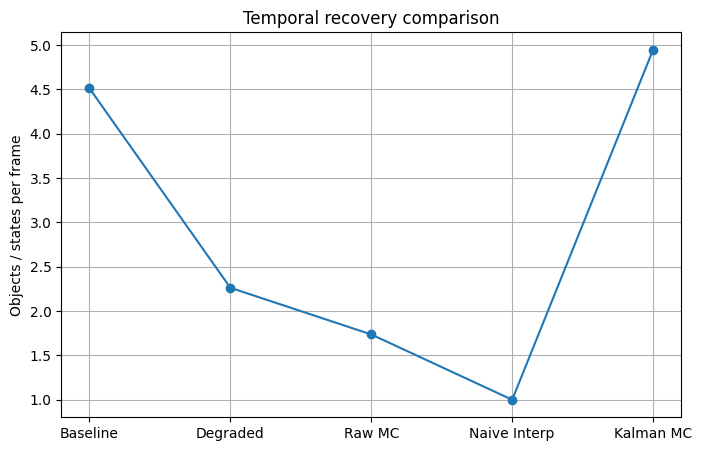

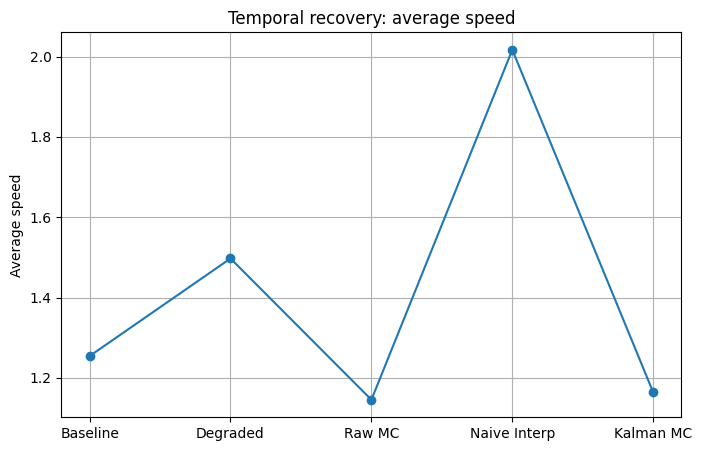

{'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}
{'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}
{'total_frames': 38, 'total_fused_objects': 66, 'avg_hits': 1.4848484848484849, 'median_hits': 1.0, 'avg_speed': 1.145501558222496, 'median_speed': 0.11158523658020437}
{'total_frames': 37, 'total_fused_objects': 37, 'avg_hits': 3.324324324324324, 'median_hits': 3.0, 'avg_speed': 2.0168722849372, 'median_speed': 2.6253441936576745}
{'total_frames': 38, 'total_objects': 188, 'objects_per_frame': 4.947368421052632, 'avg_speed': 1.1639218448488429, 'median_speed': 0.4342146480944233}
{'num_tracks': 41, 'avg_track_length': 5.585365853658536, 'median_track_length': 5.0, 'avg_final_speed': 1.0169054379805818, 'median_final_speed': 0.40024443471645554}


In [123]:
kalman_mc_results = evaluate_kalman_motion_compensation(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
)

display_kalman_motion_comp_table(kalman_mc_results)
plot_kalman_motion_comp_results(kalman_mc_results)

print(kalman_mc_results["baseline_summary"])
print(kalman_mc_results["degraded_summary"])
print(kalman_mc_results["raw_motion_comp_summary"])
print(kalman_mc_results["naive_interp_summary"])
print(kalman_mc_results["kalman_motion_comp_summary"])
print(kalman_mc_results["kalman_motion_comp_track_summary"])

In [124]:
def get_adjacent_samples(nusc, sample):
    prev_sample = None
    next_sample = None

    if sample["prev"] != "":
        prev_sample = nusc.get("sample", sample["prev"])

    if sample["next"] != "":
        next_sample = nusc.get("sample", sample["next"])

    return prev_sample, next_sample

In [125]:
def extract_frame_measurements_multiframe(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    # get neighbours
    prev_sample, next_sample = get_adjacent_samples(nusc, sample)

    samples_to_use = [s for s in [prev_sample, sample, next_sample] if s is not None]

    all_points = []
    all_vels = []

    for s in samples_to_use:
        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            s,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        pts = rpc.points[:3, :].copy()
        pts = apply_spatial_transform(pts, dx, dy, dz, yaw_deg)

        vx = rpc.points[8, :]
        vy = rpc.points[9, :]
        vel = np.vstack((vx, vy))

        all_points.append(pts)
        all_vels.append(vel)

    # concatenate all frames
    radar_xyz = np.hstack(all_points)
    radar_vel = np.hstack(all_vels)

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity(
            assoc_pts_xy,
            assoc_vel_xy,
            box_center_xy
        )

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        })

    return objects

In [127]:
def evaluate_multiframe_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
):
    baseline = run_scene_weighted_measurements(
        nusc, scene_index, radar_chan, ref_chan, min_hits
    )

    degraded = run_scene_with_temporal_offset_weighted(
        nusc, scene_index, radar_chan, ref_chan, min_hits,
        frame_offset=-1
    )

    multiframe = run_scene_multiframe_fusion(
        nusc, scene_index, radar_chan, ref_chan, min_hits
    )

    return {
        "baseline": summarise_results(baseline),
        "degraded": summarise_results(degraded),
        "multiframe": summarise_results(multiframe),

        "baseline_phys": compute_physical_alignment_metrics(baseline),
        "degraded_phys": compute_physical_alignment_metrics(degraded),
        "multiframe_phys": compute_physical_alignment_metrics(multiframe)
    }

In [128]:
def plot_multiframe_results(res):
    labels = ["Baseline", "Degraded", "Multiframe"]

    counts = [
        res["baseline"]["total_fused_objects"] / res["baseline"]["total_frames"],
        res["degraded"]["total_fused_objects"] / res["degraded"]["total_frames"],
        res["multiframe"]["total_fused_objects"] / res["multiframe"]["total_frames"],
    ]

    speeds = [
        res["baseline"]["avg_speed"],
        res["degraded"]["avg_speed"],
        res["multiframe"]["avg_speed"],
    ]

    plt.figure()
    plt.plot(labels, counts, marker="o")
    plt.title("Objects per frame")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(labels, speeds, marker="o")
    plt.title("Average speed")
    plt.grid()
    plt.show()

{'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}
{'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}
{'total_frames': 39, 'total_fused_objects': 218, 'avg_hits': 2.4862385321100917, 'median_hits': 2.0, 'avg_speed': 1.2195650313425714, 'median_speed': 0.11971581398981791}


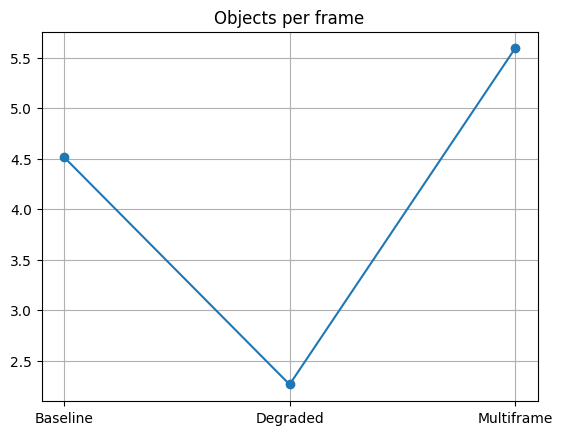

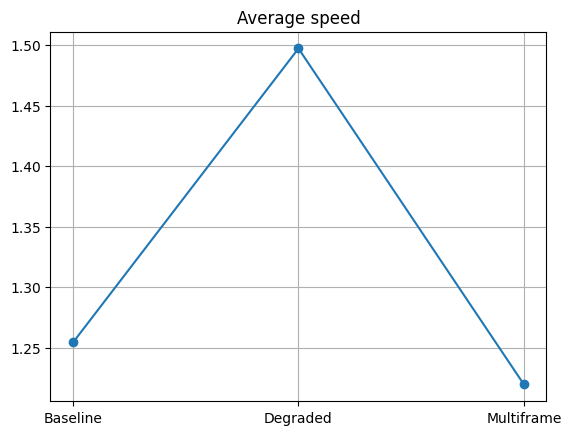

In [129]:
multi_res = evaluate_multiframe_fusion(nusc)

print(multi_res["baseline"])
print(multi_res["degraded"])
print(multi_res["multiframe"])

plot_multiframe_results(multi_res)

In [131]:
def compute_weighted_velocity_temporal(points_xy, radar_vel_xy, box_center_xy, temporal_weights, eps=1e-6):
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)

    spatial_weights = 1.0 / (dists + eps)

    # combine spatial + temporal
    weights = spatial_weights * temporal_weights

    w_sum = np.sum(weights)
    if w_sum <= 0:
        return np.mean(radar_vel_xy, axis=0)

    v_est = np.sum(radar_vel_xy * weights[:, None], axis=0) / w_sum
    return v_est

In [132]:
def extract_frame_measurements_multiframe_weighted(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    prev_sample, next_sample = get_adjacent_samples(nusc, sample)

    samples = []
    weights = []

    # assign temporal weights
    if prev_sample is not None:
        samples.append(prev_sample)
        weights.append(0.5)

    samples.append(sample)
    weights.append(1.0)

    if next_sample is not None:
        samples.append(next_sample)
        weights.append(0.5)

    all_points = []
    all_vels = []
    all_temporal_weights = []

    for s, w in zip(samples, weights):
        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            s,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        pts = rpc.points[:3, :].copy()
        pts = apply_spatial_transform(pts, dx, dy, dz, yaw_deg)

        vx = rpc.points[8, :]
        vy = rpc.points[9, :]
        vel = np.vstack((vx, vy))

        n = pts.shape[1]

        all_points.append(pts)
        all_vels.append(vel)
        all_temporal_weights.append(np.full(n, w))

    radar_xyz = np.hstack(all_points)
    radar_vel = np.hstack(all_vels)
    temporal_weights = np.concatenate(all_temporal_weights)

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        assoc_weights = temporal_weights[mask]

        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity_temporal(
            assoc_pts_xy,
            assoc_vel_xy,
            box_center_xy,
            assoc_weights
        )

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        })

    return objects

In [133]:
def run_scene_multiframe_weighted(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_multiframe_weighted(
            nusc,
            sample,
            radar_chan,
            ref_chan,
            min_hits,
            dx,
            dy,
            dz,
            yaw_deg,
            max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames

In [134]:
def evaluate_multiframe_weighted(nusc):
    baseline = run_scene_weighted_measurements(nusc)
    degraded = run_scene_with_temporal_offset_weighted(nusc, frame_offset=-1)

    multiframe = run_scene_multiframe_fusion(nusc)
    weighted_multiframe = run_scene_multiframe_weighted(nusc)

    return {
        "baseline": summarise_results(baseline),
        "degraded": summarise_results(degraded),
        "multiframe": summarise_results(multiframe),
        "weighted_multiframe": summarise_results(weighted_multiframe)
    }

In [135]:
def plot_weighted_multiframe(res):
    labels = ["Baseline", "Degraded", "Multiframe", "Weighted MF"]

    counts = [
        res["baseline"]["total_fused_objects"] / res["baseline"]["total_frames"],
        res["degraded"]["total_fused_objects"] / res["degraded"]["total_frames"],
        res["multiframe"]["total_fused_objects"] / res["multiframe"]["total_frames"],
        res["weighted_multiframe"]["total_fused_objects"] / res["weighted_multiframe"]["total_frames"],
    ]

    speeds = [
        res["baseline"]["avg_speed"],
        res["degraded"]["avg_speed"],
        res["multiframe"]["avg_speed"],
        res["weighted_multiframe"]["avg_speed"],
    ]

    plt.figure()
    plt.plot(labels, counts, marker="o")
    plt.title("Objects per frame (weighted multiframe)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(labels, speeds, marker="o")
    plt.title("Average speed (weighted multiframe)")
    plt.grid()
    plt.show()

{'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}
{'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}
{'total_frames': 39, 'total_fused_objects': 218, 'avg_hits': 2.4862385321100917, 'median_hits': 2.0, 'avg_speed': 1.2195650313425714, 'median_speed': 0.11971581398981791}
{'total_frames': 39, 'total_fused_objects': 218, 'avg_hits': 2.4862385321100917, 'median_hits': 2.0, 'avg_speed': 1.2174617422757725, 'median_speed': 0.11824499101396646}


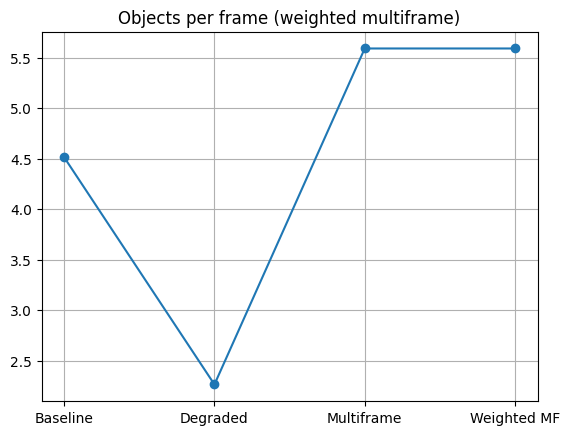

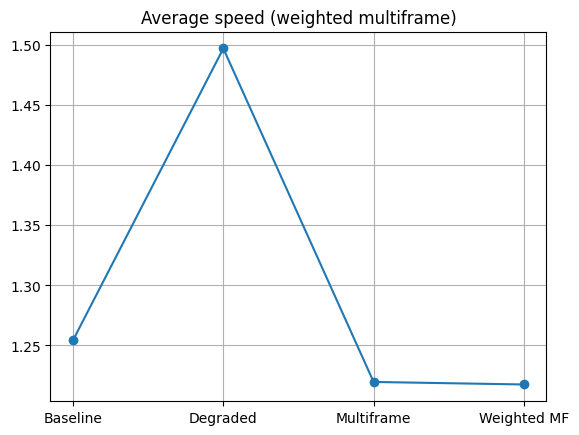

In [136]:
weighted_res = evaluate_multiframe_weighted(nusc)

print(weighted_res["baseline"])
print(weighted_res["degraded"])
print(weighted_res["multiframe"])
print(weighted_res["weighted_multiframe"])

plot_weighted_multiframe(weighted_res)

In [138]:
def temporal_weight(delta_frames, alpha=0.7):
    """
    Exponential decay based on frame distance
    delta_frames: 0 (current), 1 (prev/next), etc.
    """
    return np.exp(-alpha * abs(delta_frames))


def compute_weighted_velocity_temporal(
    points_xy,
    radar_vel_xy,
    box_center_xy,
    frame_offsets,   # NEW: array of same length as points
    eps=1e-6,
    alpha=0.7
):
    # Spatial weight (same as before)
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)
    w_spatial = 1.0 / (dists + eps)

    # Temporal weight (NEW)
    w_temporal = np.array([temporal_weight(df, alpha) for df in frame_offsets])

    # Combined weight
    weights = w_spatial * w_temporal

    if np.sum(weights) <= 0:
        return np.mean(radar_vel_xy, axis=0)

    v_est = np.sum(radar_vel_xy * weights[:, None], axis=0) / np.sum(weights)
    return v_est

In [139]:
def compute_weighted_velocity_temporal(points_xy, radar_vel_xy, box_center_xy, frame_offsets, alpha=0.7):
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)
    w_spatial = 1.0 / (dists + 1e-6)

    w_temporal = np.exp(-alpha * np.abs(frame_offsets))

    weights = w_spatial * w_temporal

    if np.sum(weights) <= 0:
        return np.mean(radar_vel_xy, axis=0)

    return np.sum(radar_vel_xy * weights[:, None], axis=0) / np.sum(weights)


def extract_multiframe_measurements(
    nusc,
    samples,
    idx,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1
):
    from nuscenes.utils.data_classes import RadarPointCloud
    from nuscenes.utils.geometry_utils import points_in_box

    sample = samples[idx]

    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])
    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    all_pts = []
    all_vel = []
    all_offsets = []

    def get_radar(sample, offset):
        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc, sample, chan=radar_chan, ref_chan=ref_chan, nsweeps=1
        )
        pts = rpc.points[:3, :]
        vel = np.vstack((rpc.points[8, :], rpc.points[9, :]))
        return pts, vel, offset

    # t-1
    if idx > 0:
        pts, vel, off = get_radar(samples[idx - 1], -1)
        all_pts.append(pts)
        all_vel.append(vel)
        all_offsets.extend([-1] * pts.shape[1])

    # t
    pts, vel, off = get_radar(samples[idx], 0)
    all_pts.append(pts)
    all_vel.append(vel)
    all_offsets.extend([0] * pts.shape[1])

    # t+1
    if idx < len(samples) - 1:
        pts, vel, off = get_radar(samples[idx + 1], +1)
        all_pts.append(pts)
        all_vel.append(vel)
        all_offsets.extend([1] * pts.shape[1])

    radar_xyz = np.concatenate(all_pts, axis=1)
    radar_vel = np.concatenate(all_vel, axis=1)
    frame_offsets = np.array(all_offsets)

    objects = []

    for box in boxes:
        mask = points_in_box(box, radar_xyz)
        if np.sum(mask) < min_hits:
            continue

        pts_xy = radar_xyz[:2, mask].T
        vel_xy = radar_vel[:, mask].T
        offsets = frame_offsets[mask]

        v_est = compute_weighted_velocity_temporal(
            pts_xy, vel_xy, box.center[:2], offsets
        )

        objects.append({
            "position_xy": box.center[:2],
            "velocity_xy": v_est,
            "radar_hits": int(np.sum(mask))
        })

    return objects


def run_temporal_weighted_multiframe(nusc, scene_index=0):
    samples = []
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    while token:
        sample = nusc.get("sample", token)
        samples.append(sample)
        token = sample["next"]

    all_frames = []

    for i in range(len(samples)):
        objs = extract_multiframe_measurements(nusc, samples, i)

        all_frames.append({
            "objects": objs
        })

    return all_frames

In [ ]:
def run_scene_multiframe_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_multiframe(
            nusc,
            sample,
            radar_chan,
            ref_chan,
            min_hits,
            dx,
            dy,
            dz,
            yaw_deg,
            max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames

In [140]:
weighted_frames = run_temporal_weighted_multiframe(nusc)

print(summarise_results(weighted_frames))

{'total_frames': 39, 'total_fused_objects': 229, 'avg_hits': 2.475982532751092, 'median_hits': 2.0, 'avg_speed': 1.2341063525823885, 'median_speed': 0.1108372727812869}


In [141]:
# Baseline
baseline_frames = run_scene_weighted_measurements(nusc)

# Degraded (temporal misalignment)
degraded_frames = run_scene_with_temporal_offset_weighted(
    nusc,
    frame_offset=-1
)

# Naive multiframe
multiframe_frames = run_scene_multiframe_fusion(nusc)

# Temporal-weighted multiframe (your new one)
weighted_frames = run_temporal_weighted_multiframe(nusc)


# Summaries
baseline = summarise_results(baseline_frames)
degraded = summarise_results(degraded_frames)
multiframe = summarise_results(multiframe_frames)
weighted = summarise_results(weighted_frames)

print("Baseline:", baseline)
print("Degraded:", degraded)
print("Naive MF:", multiframe)
print("Weighted MF:", weighted)

Baseline: {'total_frames': 39, 'total_fused_objects': 176, 'avg_hits': 1.6534090909090908, 'median_hits': 1.0, 'avg_speed': 1.2543076904362964, 'median_speed': 0.13436755521332977}
Degraded: {'total_frames': 38, 'total_fused_objects': 86, 'avg_hits': 1.4651162790697674, 'median_hits': 1.0, 'avg_speed': 1.4972944278722453, 'median_speed': 0.1786108107204777}
Naive MF: {'total_frames': 39, 'total_fused_objects': 218, 'avg_hits': 2.4862385321100917, 'median_hits': 2.0, 'avg_speed': 1.2195650313425714, 'median_speed': 0.11971581398981791}
Weighted MF: {'total_frames': 39, 'total_fused_objects': 229, 'avg_hits': 2.475982532751092, 'median_hits': 2.0, 'avg_speed': 1.2341063525823885, 'median_speed': 0.1108372727812869}


In [143]:
# ==========================================
# 1. FRAME-LEVEL MEASUREMENT EXTRACTION
# ==========================================
def extract_frame_measurements_track_fusion(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0
):
    """
    Same basic object-level fusion as before:
    - position from LiDAR GT box centre
    - velocity from weighted radar points inside box
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_vel = np.vstack((rpc.points[8, :], rpc.points[9, :]))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        pts_xy = radar_xyz[:2, mask].T
        vel_xy = radar_vel[:, mask].T
        centre_xy = box.center[:2].copy()

        dists = np.linalg.norm(pts_xy - centre_xy[None, :], axis=1)
        weights = 1.0 / (dists + 1e-6)
        v_est = np.sum(vel_xy * weights[:, None], axis=0) / np.sum(weights)

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": centre_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": pts_xy.tolist()
        })

    return objects


def run_scene_measurements_track_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_track_fusion(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            max_range=max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames


# ==========================================
# 2. TRACK MODEL
# ==========================================
class FusionTrack:
    def __init__(self, track_id, x0, P0, timestamp, class_name=None):
        self.track_id = track_id
        self.x = x0.copy()      # [x, y, vx, vy]
        self.P = P0.copy()
        self.last_timestamp = timestamp
        self.class_name = class_name
        self.age = 1
        self.missed = 0
        self.history = [x0.copy()]
        self.hit_history = []

    def predict(self, dt, q_pos=1.0, q_vel=1.0):
        F = np.array([
            [1.0, 0.0, dt,  0.0],
            [0.0, 1.0, 0.0, dt ],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

        Q = np.array([
            [q_pos * dt**2, 0.0,           0.0,           0.0],
            [0.0,           q_pos * dt**2, 0.0,           0.0],
            [0.0,           0.0,           q_vel * dt,    0.0],
            [0.0,           0.0,           0.0,           q_vel * dt]
        ])

        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z, R, radar_hits=0):
        H = np.eye(4)

        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ H) @ self.P

        self.age += 1
        self.missed = 0
        self.history.append(self.x.copy())
        self.hit_history.append(radar_hits)

    def mark_missed(self):
        self.missed += 1
        self.age += 1
        self.history.append(self.x.copy())
        self.hit_history.append(0)


def measurement_from_object_track_fusion(obj):
    px, py = obj["position_xy"]
    vx, vy = obj["velocity_xy"]
    return np.array([px, py, vx, vy], dtype=float)


def measurement_covariance_track_fusion(obj, pos_var=1.0, vel_var_base=2.0):
    hits = max(obj["radar_hits"], 1)
    vel_var = vel_var_base / hits
    return np.diag([pos_var, pos_var, vel_var, vel_var])


def associate_tracks_to_measurements_tracks(tracks, measurements, gate_dist=3.0):
    if len(tracks) == 0 or len(measurements) == 0:
        return [], list(range(len(tracks))), list(range(len(measurements)))

    track_pos = np.array([t.x[:2] for t in tracks])
    meas_pos = np.array([m[:2] for m in measurements])

    dmat = np.linalg.norm(track_pos[:, None, :] - meas_pos[None, :, :], axis=2)

    matches = []
    used_tracks = set()
    used_meas = set()

    while True:
        best = None
        best_dist = np.inf

        for ti in range(len(tracks)):
            if ti in used_tracks:
                continue
            for mi in range(len(measurements)):
                if mi in used_meas:
                    continue
                d = dmat[ti, mi]
                if d < best_dist:
                    best_dist = d
                    best = (ti, mi)

        if best is None or best_dist > gate_dist:
            break

        ti, mi = best
        matches.append((ti, mi))
        used_tracks.add(ti)
        used_meas.add(mi)

    unmatched_tracks = [i for i in range(len(tracks)) if i not in used_tracks]
    unmatched_measurements = [i for i in range(len(measurements)) if i not in used_meas]

    return matches, unmatched_tracks, unmatched_measurements


# ==========================================
# 3. TRACK-BASED FUSION PIPELINE
# ==========================================
def run_track_based_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Main track-based fusion method.

    Output is no longer 'frame detections' as the final result.
    Output is fused object tracks over time.
    """
    frames = run_scene_measurements_track_fusion(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        max_range=max_range
    )

    active_tracks = []
    finished_tracks = []
    next_track_id = 0
    tracked_frames = []

    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            dt = (timestamp - prev_timestamp) / 1e6

        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        measurements = [measurement_from_object_track_fusion(o) for o in objs]
        covariances = [
            measurement_covariance_track_fusion(o, pos_var=pos_var, vel_var_base=vel_var_base)
            for o in objs
        ]

        matches, unmatched_tracks, unmatched_measurements = associate_tracks_to_measurements_tracks(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        for ti, mi in matches:
            active_tracks[ti].update(
                measurements[mi],
                covariances[mi],
                radar_hits=objs[mi]["radar_hits"]
            )
            active_tracks[ti].last_timestamp = timestamp

        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = FusionTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            tr.hit_history.append(objs[mi]["radar_hits"])
            next_track_id += 1
            active_tracks.append(tr)

        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        tracked_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "tracks": [
                {
                    "track_id": tr.track_id,
                    "state": tr.x.copy(),
                    "class_name": tr.class_name,
                    "missed": tr.missed
                }
                for tr in active_tracks
            ]
        })

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return tracked_frames, finished_tracks, frames


# ==========================================
# 4. SUMMARIES
# ==========================================
def summarise_track_based_fusion(finished_tracks):
    track_lengths = [len(tr.history) for tr in finished_tracks]
    final_speeds = [np.linalg.norm(tr.x[2:4]) for tr in finished_tracks]
    avg_hits_per_track = [np.mean(tr.hit_history) if len(tr.hit_history) > 0 else 0.0 for tr in finished_tracks]

    return {
        "num_tracks": len(finished_tracks),
        "avg_track_length": float(np.mean(track_lengths)) if track_lengths else 0.0,
        "median_track_length": float(np.median(track_lengths)) if track_lengths else 0.0,
        "avg_final_speed": float(np.mean(final_speeds)) if final_speeds else 0.0,
        "median_final_speed": float(np.median(final_speeds)) if final_speeds else 0.0,
        "avg_hits_per_track": float(np.mean(avg_hits_per_track)) if avg_hits_per_track else 0.0,
    }


def tracked_frames_to_object_like(tracked_frames):
    out = []
    for frame in tracked_frames:
        objs = []
        for tr in frame["tracks"]:
            x, y, vx, vy = tr["state"]
            objs.append({
                "position_xy": np.array([x, y], dtype=float),
                "velocity_xy": np.array([vx, vy], dtype=float),
                "radar_hits": 0,
                "associated_radar_points_xy": []
            })
        out.append({
            "objects": objs
        })
    return out


# ==========================================
# 5. COMPARISON AGAINST YOUR CURRENT METHODS
# ==========================================
def evaluate_track_based_fusion_against_multiframe(nusc):
    baseline_frames = run_scene_weighted_measurements(nusc)
    degraded_frames = run_scene_with_temporal_offset_weighted(nusc, frame_offset=-1)
    multiframe_frames = run_scene_multiframe_fusion(nusc)
    weighted_frames = run_temporal_weighted_multiframe(nusc)

    tracked_frames, finished_tracks, track_input_frames = run_track_based_fusion(nusc)

    return {
        "baseline": summarise_results(baseline_frames),
        "degraded": summarise_results(degraded_frames),
        "multiframe": summarise_results(multiframe_frames),
        "weighted_multiframe": summarise_results(weighted_frames),
        "track_based_input_measurements": summarise_results(track_input_frames),
        "track_based_fusion": summarise_track_based_fusion(finished_tracks),
        "track_based_states": summarise_results(tracked_frames_to_object_like(tracked_frames)),
        "finished_tracks": finished_tracks,
        "tracked_frames": tracked_frames
    }


# ==========================================
# 6. DISPLAY
# ==========================================
def display_track_based_fusion_table(results):
    df = pd.DataFrame([
        {
            "Method": "Baseline",
            "Count": results["baseline"]["total_fused_objects"],
            "Per frame": results["baseline"]["total_fused_objects"] / results["baseline"]["total_frames"],
            "Avg speed": results["baseline"]["avg_speed"]
        },
        {
            "Method": "Degraded",
            "Count": results["degraded"]["total_fused_objects"],
            "Per frame": results["degraded"]["total_fused_objects"] / results["degraded"]["total_frames"],
            "Avg speed": results["degraded"]["avg_speed"]
        },
        {
            "Method": "Naive MF",
            "Count": results["multiframe"]["total_fused_objects"],
            "Per frame": results["multiframe"]["total_fused_objects"] / results["multiframe"]["total_frames"],
            "Avg speed": results["multiframe"]["avg_speed"]
        },
        {
            "Method": "Weighted MF",
            "Count": results["weighted_multiframe"]["total_fused_objects"],
            "Per frame": results["weighted_multiframe"]["total_fused_objects"] / results["weighted_multiframe"]["total_frames"],
            "Avg speed": results["weighted_multiframe"]["avg_speed"]
        },
        {
            "Method": "Track-based input meas",
            "Count": results["track_based_input_measurements"]["total_fused_objects"],
            "Per frame": results["track_based_input_measurements"]["total_fused_objects"] / results["track_based_input_measurements"]["total_frames"],
            "Avg speed": results["track_based_input_measurements"]["avg_speed"]
        },
        {
            "Method": "Track-based fusion (tracks)",
            "Count": results["track_based_fusion"]["num_tracks"],
            "Per frame": results["track_based_fusion"]["num_tracks"] / results["track_based_states"]["total_frames"],
            "Avg speed": results["track_based_fusion"]["avg_final_speed"]
        },
        {
            "Method": "Track-based states",
            "Count": results["track_based_states"]["total_fused_objects"],
            "Per frame": results["track_based_states"]["total_fused_objects"] / results["track_based_states"]["total_frames"],
            "Avg speed": results["track_based_states"]["avg_speed"]
        },
    ])

    display(df.round(3))


def plot_track_based_fusion_results(results):
    labels = [
        "Baseline",
        "Degraded",
        "Naive MF",
        "Weighted MF",
        "Track states"
    ]

    counts = [
        results["baseline"]["total_fused_objects"] / results["baseline"]["total_frames"],
        results["degraded"]["total_fused_objects"] / results["degraded"]["total_frames"],
        results["multiframe"]["total_fused_objects"] / results["multiframe"]["total_frames"],
        results["weighted_multiframe"]["total_fused_objects"] / results["weighted_multiframe"]["total_frames"],
        results["track_based_states"]["total_fused_objects"] / results["track_based_states"]["total_frames"],
    ]

    speeds = [
        results["baseline"]["avg_speed"],
        results["degraded"]["avg_speed"],
        results["multiframe"]["avg_speed"],
        results["weighted_multiframe"]["avg_speed"],
        results["track_based_states"]["avg_speed"],
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(labels, counts, marker="o")
    plt.ylabel("Objects / states per frame")
    plt.title("Track-based fusion vs frame-based fusion")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(labels, speeds, marker="o")
    plt.ylabel("Average speed")
    plt.title("Average speed comparison")
    plt.grid(True)
    plt.show()

,Method,Count,Per frame,Avg speed
0,Baseline,176,4.513,1.254
1,Degraded,86,2.263,1.497
2,Naive MF,218,5.590,1.220
3,Weighted MF,229,5.872,1.234
4,Track-based input meas,176,4.513,1.254
5,Track-based fusion (tracks),73,1.872,1.095
6,Track-based states,359,9.205,1.148


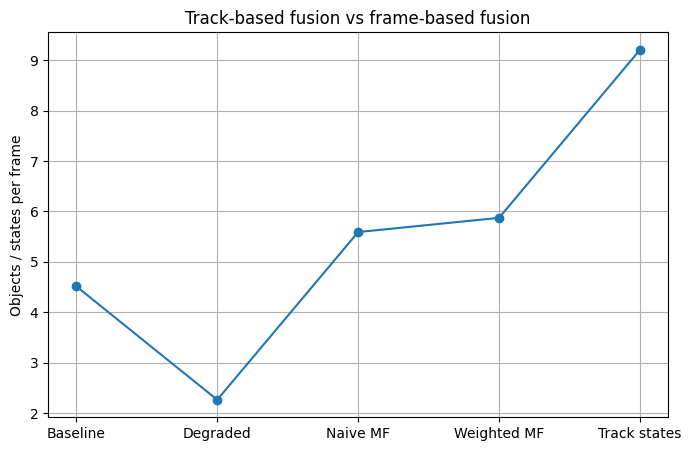

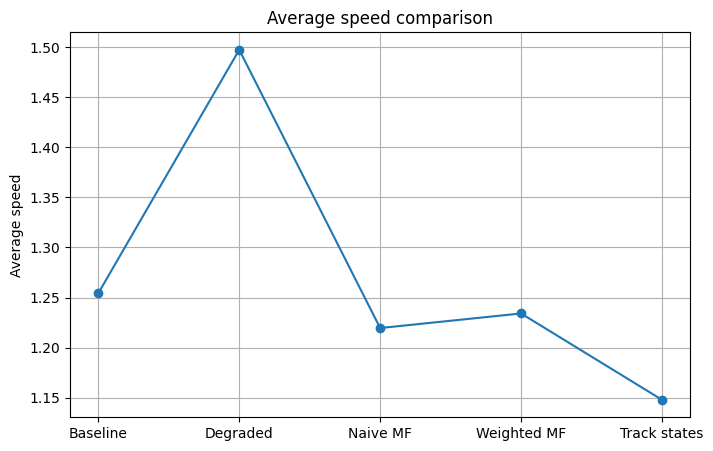

{'num_tracks': 73, 'avg_track_length': 5.890410958904109, 'median_track_length': 5.0, 'avg_final_speed': 1.0949542623333506, 'median_final_speed': 0.17957793939324393, 'avg_hits_per_track': 0.6077265120523953}
{'total_frames': 39, 'total_fused_objects': 359, 'avg_hits': 0.0, 'median_hits': 0.0, 'avg_speed': 1.1479576938245943, 'median_speed': 0.20993305985952374}


In [144]:
track_results = evaluate_track_based_fusion_against_multiframe(nusc)

display_track_based_fusion_table(track_results)
plot_track_based_fusion_results(track_results)

print(track_results["track_based_fusion"])
print(track_results["track_based_states"])

In [145]:
def compute_weighted_velocity_temporal(points_xy, radar_vel_xy, box_center_xy, frame_offsets, alpha=0.7):
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)
    w_spatial = 1.0 / (dists + 1e-6)
    w_temporal = np.exp(-alpha * np.abs(frame_offsets))
    weights = w_spatial * w_temporal

    if np.sum(weights) <= 0:
        return np.mean(radar_vel_xy, axis=0)

    return np.sum(radar_vel_xy * weights[:, None], axis=0) / np.sum(weights)


def extract_temporal_weighted_multiframe_measurements(
    nusc,
    samples,
    idx,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0,
    alpha=0.7
):
    sample = samples[idx]
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])
    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    all_pts = []
    all_vel = []
    all_offsets = []

    def get_radar(sample_obj, offset):
        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            sample_obj,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )
        pts = rpc.points[:3, :]
        vel = np.vstack((rpc.points[8, :], rpc.points[9, :]))
        return pts, vel, offset

    # t-1
    if idx > 0:
        pts, vel, off = get_radar(samples[idx - 1], -1)
        all_pts.append(pts)
        all_vel.append(vel)
        all_offsets.extend([-1] * pts.shape[1])

    # t
    pts, vel, off = get_radar(samples[idx], 0)
    all_pts.append(pts)
    all_vel.append(vel)
    all_offsets.extend([0] * pts.shape[1])

    # t+1
    if idx < len(samples) - 1:
        pts, vel, off = get_radar(samples[idx + 1], +1)
        all_pts.append(pts)
        all_vel.append(vel)
        all_offsets.extend([1] * pts.shape[1])

    radar_xyz = np.concatenate(all_pts, axis=1)
    radar_vel = np.concatenate(all_vel, axis=1)
    frame_offsets = np.array(all_offsets)

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        pts_xy = radar_xyz[:2, mask].T
        vel_xy = radar_vel[:, mask].T
        offsets = frame_offsets[mask]

        v_est = compute_weighted_velocity_temporal(
            pts_xy,
            vel_xy,
            box.center[:2],
            offsets,
            alpha=alpha
        )

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": box.center[:2].copy(),
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": pts_xy.tolist()
        })

    return objects


def run_temporal_weighted_multiframe(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0,
    alpha=0.7
):
    samples = []
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    while token:
        sample = nusc.get("sample", token)
        samples.append(sample)
        token = sample["next"]

    all_frames = []

    for i in range(len(samples)):
        objs = extract_temporal_weighted_multiframe_measurements(
            nusc,
            samples,
            i,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            max_range=max_range,
            alpha=alpha
        )

        all_frames.append({
            "frame_index": i,
            "timestamp": samples[i]["timestamp"],
            "objects": objs
        })

    return all_frames

In [146]:
weighted_multiframe_frames = run_temporal_weighted_multiframe(nusc)

print(summarise_results(weighted_multiframe_frames))

{'total_frames': 39, 'total_fused_objects': 218, 'avg_hits': 2.4862385321100917, 'median_hits': 2.0, 'avg_speed': 1.2174414783831056, 'median_speed': 0.11824499101396646}


In [147]:
track_level_results = evaluate_track_level_comparison(nusc)

display_track_level_comparison_table(track_level_results)
plot_track_level_comparison(track_level_results)

print("Baseline track:", track_level_results["baseline_track"])
print("Degraded track:", track_level_results["degraded_track"])
print("Naive MF track:", track_level_results["multiframe_track"])
print("Weighted MF track:", track_level_results["weighted_multiframe_track"])

NameError: name 'evaluate_track_level_comparison' is not defined

In [113]:
def compute_weighted_velocity_temporal(points_xy, radar_vel_xy, box_center_xy, temporal_weights, eps=1e-6):
    dists = np.linalg.norm(points_xy - box_center_xy[None, :], axis=1)

    spatial_weights = 1.0 / (dists + eps)

    # combine spatial + temporal
    weights = spatial_weights * temporal_weights

    w_sum = np.sum(weights)
    if w_sum <= 0:
        return np.mean(radar_vel_xy, axis=0)

    v_est = np.sum(radar_vel_xy * weights[:, None], axis=0) / w_sum
    return v_est

In [114]:
def extract_frame_measurements_multiframe_weighted(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    prev_sample, next_sample = get_adjacent_samples(nusc, sample)

    samples = []
    weights = []

    # assign temporal weights
    if prev_sample is not None:
        samples.append(prev_sample)
        weights.append(0.5)

    samples.append(sample)
    weights.append(1.0)

    if next_sample is not None:
        samples.append(next_sample)
        weights.append(0.5)

    all_points = []
    all_vels = []
    all_temporal_weights = []

    for s, w in zip(samples, weights):
        rpc, _ = RadarPointCloud.from_file_multisweep(
            nusc,
            s,
            chan=radar_chan,
            ref_chan=ref_chan,
            nsweeps=1
        )

        pts = rpc.points[:3, :].copy()
        pts = apply_spatial_transform(pts, dx, dy, dz, yaw_deg)

        vx = rpc.points[8, :]
        vy = rpc.points[9, :]
        vel = np.vstack((vx, vy))

        n = pts.shape[1]

        all_points.append(pts)
        all_vels.append(vel)
        all_temporal_weights.append(np.full(n, w))

    radar_xyz = np.hstack(all_points)
    radar_vel = np.hstack(all_vels)
    temporal_weights = np.concatenate(all_temporal_weights)

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        assoc_pts_xy = radar_xyz[:2, mask].T
        assoc_vel_xy = radar_vel[:, mask].T
        assoc_weights = temporal_weights[mask]

        box_center_xy = box.center[:2].copy()

        v_est = compute_weighted_velocity_temporal(
            assoc_pts_xy,
            assoc_vel_xy,
            box_center_xy,
            assoc_weights
        )

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": box_center_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": assoc_pts_xy.tolist()
        })

    return objects

In [115]:
def run_scene_multiframe_weighted(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_multiframe_weighted(
            nusc,
            sample,
            radar_chan,
            ref_chan,
            min_hits,
            dx,
            dy,
            dz,
            yaw_deg,
            max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames

In [116]:
def evaluate_multiframe_weighted(nusc):
    baseline = run_scene_weighted_measurements(nusc)
    degraded = run_scene_with_temporal_offset_weighted(nusc, frame_offset=-1)

    multiframe = run_scene_multiframe_fusion(nusc)
    weighted_multiframe = run_scene_multiframe_weighted(nusc)

    return {
        "baseline": summarise_results(baseline),
        "degraded": summarise_results(degraded),
        "multiframe": summarise_results(multiframe),
        "weighted_multiframe": summarise_results(weighted_multiframe)
    }

In [117]:
def plot_weighted_multiframe(res):
    labels = ["Baseline", "Degraded", "Multiframe", "Weighted MF"]

    counts = [
        res["baseline"]["total_fused_objects"] / res["baseline"]["total_frames"],
        res["degraded"]["total_fused_objects"] / res["degraded"]["total_frames"],
        res["multiframe"]["total_fused_objects"] / res["multiframe"]["total_frames"],
        res["weighted_multiframe"]["total_fused_objects"] / res["weighted_multiframe"]["total_frames"],
    ]

    speeds = [
        res["baseline"]["avg_speed"],
        res["degraded"]["avg_speed"],
        res["multiframe"]["avg_speed"],
        res["weighted_multiframe"]["avg_speed"],
    ]

    plt.figure()
    plt.plot(labels, counts, marker="o")
    plt.title("Objects per frame (weighted multiframe)")
    plt.grid()
    plt.show()

    plt.figure()
    plt.plot(labels, speeds, marker="o")
    plt.title("Average speed (weighted multiframe)")
    plt.grid()
    plt.show()

In [120]:
weighted_res = evaluate_multiframe_weighted(nusc)

print(weighted_res["baseline"])
print(weighted_res["degraded"])
print(weighted_res["multiframe"])
print(weighted_res["weighted_multiframe"])

plot_weighted_multiframe(weighted_res)

NameError: name 'get_adjacent_samples' is not defined

# Track Level (5.5?)

In [102]:
# ==========================================
# 1. FRAME-LEVEL MEASUREMENT EXTRACTION
# ==========================================
def extract_frame_measurements_track_fusion(
    nusc,
    sample,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0
):
    """
    Same basic object-level fusion as before:
    - position from LiDAR GT box centre
    - velocity from weighted radar points inside box
    """
    lidar_sd = nusc.get("sample_data", sample["data"][ref_chan])

    rpc, _ = RadarPointCloud.from_file_multisweep(
        nusc,
        sample,
        chan=radar_chan,
        ref_chan=ref_chan,
        nsweeps=1
    )

    radar_xyz = rpc.points[:3, :].copy()
    radar_vel = np.vstack((rpc.points[8, :], rpc.points[9, :]))

    _, boxes, _ = nusc.get_sample_data(lidar_sd["token"])

    objects = []

    for i, box in enumerate(boxes):
        if np.linalg.norm(box.center[:2]) > max_range:
            continue

        mask = points_in_box(box, radar_xyz)
        hit_count = int(np.sum(mask))

        if hit_count < min_hits:
            continue

        pts_xy = radar_xyz[:2, mask].T
        vel_xy = radar_vel[:, mask].T
        centre_xy = box.center[:2].copy()

        dists = np.linalg.norm(pts_xy - centre_xy[None, :], axis=1)
        weights = 1.0 / (dists + 1e-6)
        v_est = np.sum(vel_xy * weights[:, None], axis=0) / np.sum(weights)

        objects.append({
            "box_index": i,
            "box_name": box.name,
            "position_xy": centre_xy,
            "velocity_xy": v_est,
            "radar_hits": hit_count,
            "associated_radar_points_xy": pts_xy.tolist()
        })

    return objects


def run_scene_measurements_track_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_track_fusion(
            nusc,
            sample,
            radar_chan=radar_chan,
            ref_chan=ref_chan,
            min_hits=min_hits,
            max_range=max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames


# ==========================================
# 2. TRACK MODEL
# ==========================================
class FusionTrack:
    def __init__(self, track_id, x0, P0, timestamp, class_name=None):
        self.track_id = track_id
        self.x = x0.copy()      # [x, y, vx, vy]
        self.P = P0.copy()
        self.last_timestamp = timestamp
        self.class_name = class_name
        self.age = 1
        self.missed = 0
        self.history = [x0.copy()]
        self.hit_history = []

    def predict(self, dt, q_pos=1.0, q_vel=1.0):
        F = np.array([
            [1.0, 0.0, dt,  0.0],
            [0.0, 1.0, 0.0, dt ],
            [0.0, 0.0, 1.0, 0.0],
            [0.0, 0.0, 0.0, 1.0]
        ])

        Q = np.array([
            [q_pos * dt**2, 0.0,           0.0,           0.0],
            [0.0,           q_pos * dt**2, 0.0,           0.0],
            [0.0,           0.0,           q_vel * dt,    0.0],
            [0.0,           0.0,           0.0,           q_vel * dt]
        ])

        self.x = F @ self.x
        self.P = F @ self.P @ F.T + Q

    def update(self, z, R, radar_hits=0):
        H = np.eye(4)

        y = z - H @ self.x
        S = H @ self.P @ H.T + R
        K = self.P @ H.T @ np.linalg.inv(S)

        self.x = self.x + K @ y
        self.P = (np.eye(4) - K @ H) @ self.P

        self.age += 1
        self.missed = 0
        self.history.append(self.x.copy())
        self.hit_history.append(radar_hits)

    def mark_missed(self):
        self.missed += 1
        self.age += 1
        self.history.append(self.x.copy())
        self.hit_history.append(0)


def measurement_from_object_track_fusion(obj):
    px, py = obj["position_xy"]
    vx, vy = obj["velocity_xy"]
    return np.array([px, py, vx, vy], dtype=float)


def measurement_covariance_track_fusion(obj, pos_var=1.0, vel_var_base=2.0):
    hits = max(obj["radar_hits"], 1)
    vel_var = vel_var_base / hits
    return np.diag([pos_var, pos_var, vel_var, vel_var])


def associate_tracks_to_measurements_tracks(tracks, measurements, gate_dist=3.0):
    if len(tracks) == 0 or len(measurements) == 0:
        return [], list(range(len(tracks))), list(range(len(measurements)))

    track_pos = np.array([t.x[:2] for t in tracks])
    meas_pos = np.array([m[:2] for m in measurements])

    dmat = np.linalg.norm(track_pos[:, None, :] - meas_pos[None, :, :], axis=2)

    matches = []
    used_tracks = set()
    used_meas = set()

    while True:
        best = None
        best_dist = np.inf

        for ti in range(len(tracks)):
            if ti in used_tracks:
                continue
            for mi in range(len(measurements)):
                if mi in used_meas:
                    continue
                d = dmat[ti, mi]
                if d < best_dist:
                    best_dist = d
                    best = (ti, mi)

        if best is None or best_dist > gate_dist:
            break

        ti, mi = best
        matches.append((ti, mi))
        used_tracks.add(ti)
        used_meas.add(mi)

    unmatched_tracks = [i for i in range(len(tracks)) if i not in used_tracks]
    unmatched_measurements = [i for i in range(len(measurements)) if i not in used_meas]

    return matches, unmatched_tracks, unmatched_measurements


# ==========================================
# 3. TRACK-BASED FUSION PIPELINE
# ==========================================
def run_track_based_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    max_range=60.0,
    gate_dist=3.0,
    max_missed=2,
    pos_var=1.0,
    vel_var_base=2.0,
    q_pos=1.0,
    q_vel=1.0
):
    """
    Main track-based fusion method.

    Output is no longer 'frame detections' as the final result.
    Output is fused object tracks over time.
    """
    frames = run_scene_measurements_track_fusion(
        nusc,
        scene_index=scene_index,
        radar_chan=radar_chan,
        ref_chan=ref_chan,
        min_hits=min_hits,
        max_range=max_range
    )

    active_tracks = []
    finished_tracks = []
    next_track_id = 0
    tracked_frames = []

    prev_timestamp = None

    for frame in frames:
        timestamp = frame["timestamp"]
        objs = frame["objects"]

        if prev_timestamp is None:
            dt = 0.1
        else:
            dt = (timestamp - prev_timestamp) / 1e6

        for tr in active_tracks:
            tr.predict(dt, q_pos=q_pos, q_vel=q_vel)

        measurements = [measurement_from_object_track_fusion(o) for o in objs]
        covariances = [
            measurement_covariance_track_fusion(o, pos_var=pos_var, vel_var_base=vel_var_base)
            for o in objs
        ]

        matches, unmatched_tracks, unmatched_measurements = associate_tracks_to_measurements_tracks(
            active_tracks,
            measurements,
            gate_dist=gate_dist
        )

        for ti, mi in matches:
            active_tracks[ti].update(
                measurements[mi],
                covariances[mi],
                radar_hits=objs[mi]["radar_hits"]
            )
            active_tracks[ti].last_timestamp = timestamp

        for ti in unmatched_tracks:
            active_tracks[ti].mark_missed()
            active_tracks[ti].last_timestamp = timestamp

        for mi in unmatched_measurements:
            z = measurements[mi]
            P0 = np.diag([1.0, 1.0, 2.0, 2.0])

            tr = FusionTrack(
                track_id=next_track_id,
                x0=z,
                P0=P0,
                timestamp=timestamp,
                class_name=objs[mi]["box_name"]
            )
            tr.hit_history.append(objs[mi]["radar_hits"])
            next_track_id += 1
            active_tracks.append(tr)

        still_active = []
        for tr in active_tracks:
            if tr.missed > max_missed:
                finished_tracks.append(tr)
            else:
                still_active.append(tr)
        active_tracks = still_active

        tracked_frames.append({
            "frame_index": frame["frame_index"],
            "timestamp": timestamp,
            "tracks": [
                {
                    "track_id": tr.track_id,
                    "state": tr.x.copy(),
                    "class_name": tr.class_name,
                    "missed": tr.missed
                }
                for tr in active_tracks
            ]
        })

        prev_timestamp = timestamp

    finished_tracks.extend(active_tracks)

    return tracked_frames, finished_tracks, frames


# ==========================================
# 4. SUMMARIES
# ==========================================
def summarise_track_based_fusion(finished_tracks):
    track_lengths = [len(tr.history) for tr in finished_tracks]
    final_speeds = [np.linalg.norm(tr.x[2:4]) for tr in finished_tracks]
    avg_hits_per_track = [np.mean(tr.hit_history) if len(tr.hit_history) > 0 else 0.0 for tr in finished_tracks]

    return {
        "num_tracks": len(finished_tracks),
        "avg_track_length": float(np.mean(track_lengths)) if track_lengths else 0.0,
        "median_track_length": float(np.median(track_lengths)) if track_lengths else 0.0,
        "avg_final_speed": float(np.mean(final_speeds)) if final_speeds else 0.0,
        "median_final_speed": float(np.median(final_speeds)) if final_speeds else 0.0,
        "avg_hits_per_track": float(np.mean(avg_hits_per_track)) if avg_hits_per_track else 0.0,
    }


def tracked_frames_to_object_like(tracked_frames):
    out = []
    for frame in tracked_frames:
        objs = []
        for tr in frame["tracks"]:
            x, y, vx, vy = tr["state"]
            objs.append({
                "position_xy": np.array([x, y], dtype=float),
                "velocity_xy": np.array([vx, vy], dtype=float),
                "radar_hits": 0,
                "associated_radar_points_xy": []
            })
        out.append({
            "objects": objs
        })
    return out


# ==========================================
# 5. COMPARISON AGAINST YOUR CURRENT METHODS
# ==========================================
def evaluate_track_based_fusion_against_multiframe(nusc):
    baseline_frames = run_scene_weighted_measurements(nusc)
    degraded_frames = run_scene_with_temporal_offset_weighted(nusc, frame_offset=-1)
    multiframe_frames = run_scene_multiframe_fusion(nusc)
    weighted_frames = run_temporal_weighted_multiframe(nusc)

    tracked_frames, finished_tracks, track_input_frames = run_track_based_fusion(nusc)

    return {
        "baseline": summarise_results(baseline_frames),
        "degraded": summarise_results(degraded_frames),
        "multiframe": summarise_results(multiframe_frames),
        "weighted_multiframe": summarise_results(weighted_frames),
        "track_based_input_measurements": summarise_results(track_input_frames),
        "track_based_fusion": summarise_track_based_fusion(finished_tracks),
        "track_based_states": summarise_results(tracked_frames_to_object_like(tracked_frames)),
        "finished_tracks": finished_tracks,
        "tracked_frames": tracked_frames
    }


# ==========================================
# 6. DISPLAY
# ==========================================
def display_track_based_fusion_table(results):
    df = pd.DataFrame([
        {
            "Method": "Baseline",
            "Count": results["baseline"]["total_fused_objects"],
            "Per frame": results["baseline"]["total_fused_objects"] / results["baseline"]["total_frames"],
            "Avg speed": results["baseline"]["avg_speed"]
        },
        {
            "Method": "Degraded",
            "Count": results["degraded"]["total_fused_objects"],
            "Per frame": results["degraded"]["total_fused_objects"] / results["degraded"]["total_frames"],
            "Avg speed": results["degraded"]["avg_speed"]
        },
        {
            "Method": "Naive MF",
            "Count": results["multiframe"]["total_fused_objects"],
            "Per frame": results["multiframe"]["total_fused_objects"] / results["multiframe"]["total_frames"],
            "Avg speed": results["multiframe"]["avg_speed"]
        },
        {
            "Method": "Weighted MF",
            "Count": results["weighted_multiframe"]["total_fused_objects"],
            "Per frame": results["weighted_multiframe"]["total_fused_objects"] / results["weighted_multiframe"]["total_frames"],
            "Avg speed": results["weighted_multiframe"]["avg_speed"]
        },
        {
            "Method": "Track-based input meas",
            "Count": results["track_based_input_measurements"]["total_fused_objects"],
            "Per frame": results["track_based_input_measurements"]["total_fused_objects"] / results["track_based_input_measurements"]["total_frames"],
            "Avg speed": results["track_based_input_measurements"]["avg_speed"]
        },
        {
            "Method": "Track-based fusion (tracks)",
            "Count": results["track_based_fusion"]["num_tracks"],
            "Per frame": results["track_based_fusion"]["num_tracks"] / results["track_based_states"]["total_frames"],
            "Avg speed": results["track_based_fusion"]["avg_final_speed"]
        },
        {
            "Method": "Track-based states",
            "Count": results["track_based_states"]["total_fused_objects"],
            "Per frame": results["track_based_states"]["total_fused_objects"] / results["track_based_states"]["total_frames"],
            "Avg speed": results["track_based_states"]["avg_speed"]
        },
    ])

    display(df.round(3))


def plot_track_based_fusion_results(results):
    labels = [
        "Baseline",
        "Degraded",
        "Naive MF",
        "Weighted MF",
        "Track states"
    ]

    counts = [
        results["baseline"]["total_fused_objects"] / results["baseline"]["total_frames"],
        results["degraded"]["total_fused_objects"] / results["degraded"]["total_frames"],
        results["multiframe"]["total_fused_objects"] / results["multiframe"]["total_frames"],
        results["weighted_multiframe"]["total_fused_objects"] / results["weighted_multiframe"]["total_frames"],
        results["track_based_states"]["total_fused_objects"] / results["track_based_states"]["total_frames"],
    ]

    speeds = [
        results["baseline"]["avg_speed"],
        results["degraded"]["avg_speed"],
        results["multiframe"]["avg_speed"],
        results["weighted_multiframe"]["avg_speed"],
        results["track_based_states"]["avg_speed"],
    ]

    plt.figure(figsize=(8, 5))
    plt.plot(labels, counts, marker="o")
    plt.ylabel("Objects / states per frame")
    plt.title("Track-based fusion vs frame-based fusion")
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(labels, speeds, marker="o")
    plt.ylabel("Average speed")
    plt.title("Average speed comparison")
    plt.grid(True)
    plt.show()

In [104]:
def run_scene_multiframe_fusion(
    nusc,
    scene_index=0,
    radar_chan="RADAR_FRONT",
    ref_chan="LIDAR_TOP",
    min_hits=1,
    dx=0.0,
    dy=0.0,
    dz=0.0,
    yaw_deg=0.0,
    max_range=60.0
):
    scene = nusc.scene[scene_index]
    token = scene["first_sample_token"]

    frames = []
    frame_idx = 0

    while token:
        sample = nusc.get("sample", token)

        objects = extract_frame_measurements_multiframe(
            nusc,
            sample,
            radar_chan,
            ref_chan,
            min_hits,
            dx,
            dy,
            dz,
            yaw_deg,
            max_range
        )

        frames.append({
            "frame_index": frame_idx,
            "timestamp": sample["timestamp"],
            "objects": objects
        })

        token = sample["next"]
        frame_idx += 1

    return frames

,Method,Count,Per frame,Avg speed
0,Baseline,176,4.513,1.254
1,Degraded,86,2.263,1.497
2,Naive MF,218,5.590,1.220
3,Weighted MF,218,5.590,1.217
4,Track-based input meas,176,4.513,1.254
5,Track-based fusion (tracks),73,1.872,1.095
6,Track-based states,359,9.205,1.148


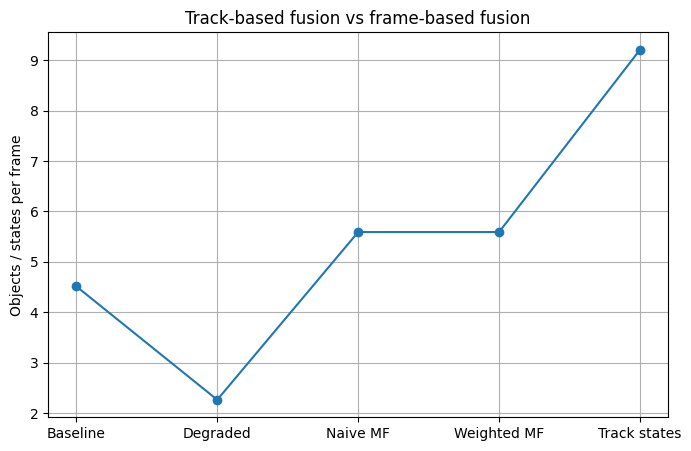

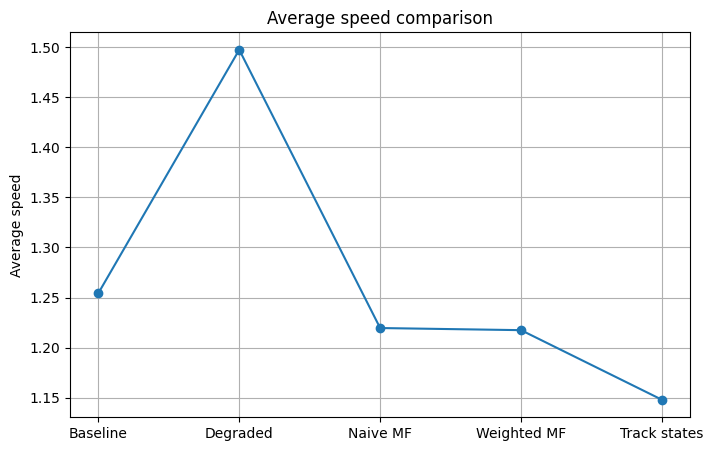

{'num_tracks': 73, 'avg_track_length': 5.890410958904109, 'median_track_length': 5.0, 'avg_final_speed': 1.0949542623333506, 'median_final_speed': 0.17957793939324393, 'avg_hits_per_track': 0.6077265120523953}
{'total_frames': 39, 'total_fused_objects': 359, 'avg_hits': 0.0, 'median_hits': 0.0, 'avg_speed': 1.1479576938245943, 'median_speed': 0.20993305985952374}


In [148]:
track_results = evaluate_track_based_fusion_against_multiframe(nusc)

display_track_based_fusion_table(track_results)
plot_track_based_fusion_results(track_results)

print(track_results["track_based_fusion"])
print(track_results["track_based_states"])